# Rasch 1PL (Known Item Difficulties): Simulation, MLE, MCMC, and PPC

This notebook simulates a Rasch 1PL dataset with known item difficulties and estimates student abilities.

- 20 item difficulties: $b_i \sim \mathcal{N}(0,1)$
- 150 student abilities: $\theta_j \sim \mathcal{N}(0,2)$
- Response model: $Y_{ji} \sim \mathrm{Bernoulli}(\mathrm{logit}^{-1}(\theta_j-b_i))$
- One all-0 response pattern and one all-1 response pattern are inserted intentionally to stress-test the analysis.

Inference treats item difficulties as known. The MLE step is run only for students with non-extreme response patterns, while MCMC is run for all students with a weak prior.

### What is included:

1. Cell 2 contains the setup commands (package install + cmdstan installation check), as requested.
2. Simulation of 20 item difficulties from Normal(0,1) and 150 student abilities from Normal(0,2).
3. Selection of two items with a large difficulty gap (easiest vs hardest), with characteristic curves along theta and student-level small-circle overlays of ability-probability points.
4. Response data generation from the Rasch model with exactly one all-0 response vector and one all-1 response vector inserted intentionally.
5. Histograms for item p-correct and total score, plus a scatterplot of item difficulty versus item p-correct.
6. Stan file generation inside the notebook as rasch_known_item_ability.stan for ability estimation with known item difficulties.
7. `optimize()` run for MLE-style estimation on the non-extreme response patterns only.
8. Plot of estimated abilities vs true abilities for the non-extreme students.
9. Wright map using MLE ability estimates and item-difficulty arrows under the theta axis.
10. MCMC sampling via cmdstanpy with a weak prior for all students.
11. Violin plots of posterior samples for each ability parameter against true abilities.
12. Wright map using posterior means with item-difficulty arrows.
13. PPC plots (item-level proportion-correct check and total-score statistic) plus posterior predictive p-value.
14. Student-level posterior ability density with correct and incorrect item markers shown below the theta axis.
15. Item-wise vertical posterior densities of correct-response probabilities for the selected student.

In [1]:
# Install and verify the core Python and CmdStan dependencies used throughout the notebook.
%pip install -q numpy pandas matplotlib seaborn scipy cmdstanpy arviz

import cmdstanpy

try:
    cmdstan_path = cmdstanpy.cmdstan_path()
    print(f'CmdStan is already installed at: {cmdstan_path}')
except Exception:
    cmdstanpy.install_cmdstan(cores=2, progress=True)

Note: you may need to restart the kernel to use updated packages.
CmdStan is already installed at: C:\Users\yongduek\.cmdstan\cmdstan-2.38.0


In [2]:
# Import analysis libraries, set plotting defaults, and define the simulation size.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from cmdstanpy import CmdStanModel

sns.set_theme(style='whitegrid')
np.random.seed(5101)

N = 150   # students
K = 20   # items

print(f'N={N}, K={K}')

N=150, K=20


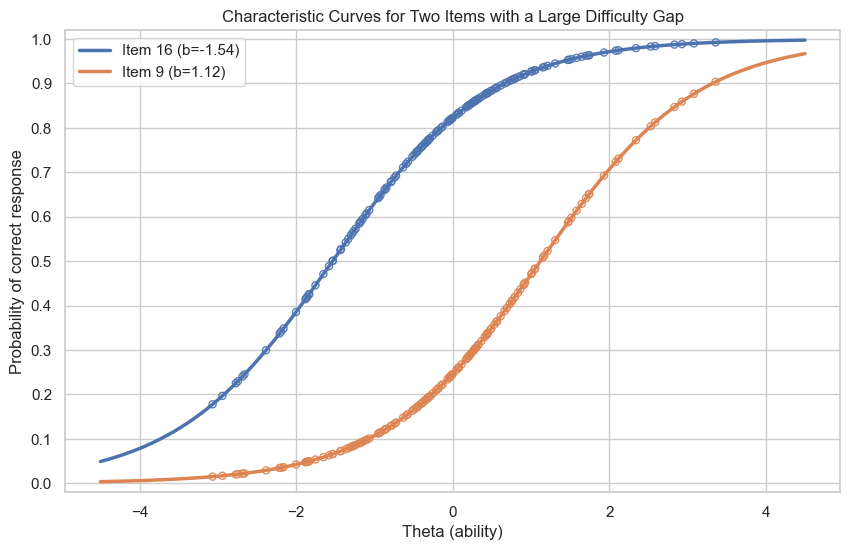

Easy item index: 16, b=-1.535
Hard item index: 9, b=1.120


In [3]:
# Simulate item difficulties and student abilities, then visualize two items with a large difficulty gap.
np.random.seed(5101) # For reproducibility

b_true = np.random.normal(loc=0.0, scale=1.0, size=K)
theta_true = np.random.normal(loc=0.0, scale=np.sqrt(2.0), size=N)

# Pick two items with a large gap: easiest and hardest
j_easy = int(np.argmin(b_true))
j_hard = int(np.argmax(b_true))

theta_grid = np.linspace(-4.5, 4.5, 300)
p_easy_grid = expit(theta_grid - b_true[j_easy])
p_hard_grid = expit(theta_grid - b_true[j_hard])

p_easy_students = expit(theta_true - b_true[j_easy])
p_hard_students = expit(theta_true - b_true[j_hard])

plt.figure(figsize=(10, 6))
plt.plot(theta_grid, p_easy_grid, lw=2.5, label=f'Item {j_easy+1} (b={b_true[j_easy]:.2f})')
plt.plot(theta_grid, p_hard_grid, lw=2.5, label=f'Item {j_hard+1} (b={b_true[j_hard]:.2f})')
plt.scatter(theta_true, p_easy_students, s=26, facecolors='none', edgecolors='C0', alpha=0.9)
plt.scatter(theta_true, p_hard_students, s=26, facecolors='none', edgecolors='C1', alpha=0.9)
plt.xlabel('Theta (ability)')
plt.ylabel('Probability of correct response')
plt.title('Characteristic Curves for Two Items with a Large Difficulty Gap')
plt.legend()
plt.ylim(-0.02, 1.02)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.show()

print(f'Easy item index: {j_easy+1}, b={b_true[j_easy]:.3f}')
print(f'Hard item index: {j_hard+1}, b={b_true[j_hard]:.3f}')

In [4]:
# Generate the response matrix and enforce exactly one all-0 and one all-1 response pattern.
max_tries = 200
for attempt in range(max_tries):
    p = expit(theta_true[:, None] - b_true[None, :])
    y = np.random.binomial(1, p, size=(N, K))
    row_sums = y.sum(axis=1)
    if np.all((row_sums > 0) & (row_sums < K)):
        break
else:
    raise RuntimeError('Could not generate a baseline dataset without extreme scores; increase K or max_tries.')

student_all_zero = int(np.argmin(theta_true))
student_all_one = int(np.argmax(theta_true))

y[student_all_zero, :] = 0
y[student_all_one, :] = 1

row_sums = y.sum(axis=1)
item_prop_correct = y.mean(axis=0)
total_score = row_sums
non_extreme_mask = (row_sums > 0) & (row_sums < K)

print(f'Response matrix shape: {y.shape}')
print(f'Mean item p-correct: {item_prop_correct.mean():.3f}')
print(f'Mean total score: {total_score.mean():.3f}')
print(f'Max score: {total_score.max()}, Min score: {total_score.min()}')
print(f'Inserted all-0 response pattern for student {student_all_zero + 1}.')
print(f'Inserted all-1 response pattern for student {student_all_one + 1}.')
print(f'Number of perfect scores: {(total_score == K).sum()}')
print(f'Number of zero scores: {(total_score == 0).sum()}')
print(f'Number of non-extreme students used in MLE: {non_extreme_mask.sum()}')

Response matrix shape: (150, 20)
Mean item p-correct: 0.539
Mean total score: 10.773
Max score: 20, Min score: 0
Inserted all-0 response pattern for student 64.
Inserted all-1 response pattern for student 17.
Number of perfect scores: 1
Number of zero scores: 1
Number of non-extreme students used in MLE: 148


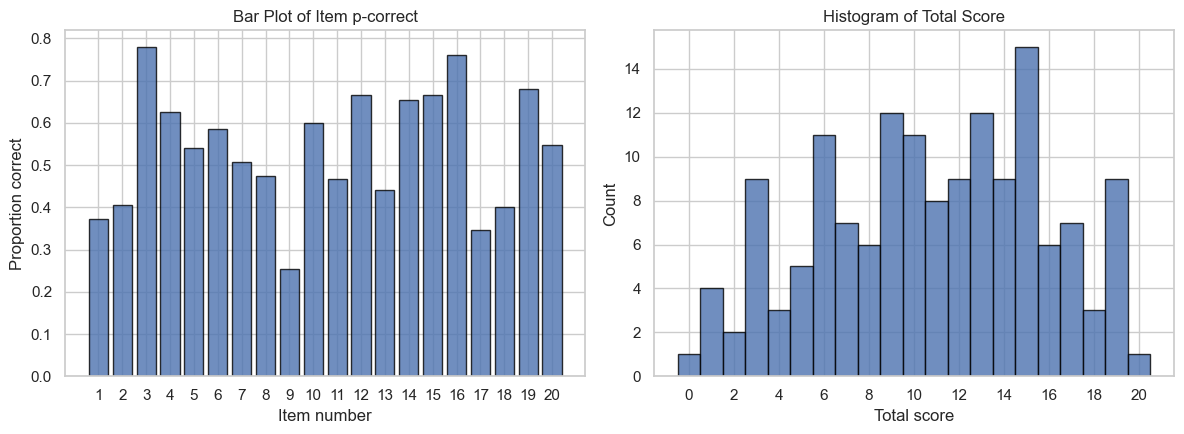

In [5]:
# Summarize the simulated data with a histogram of item p-correct and a histogram of total score.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(np.arange(1, K + 1), item_prop_correct, color='C0', edgecolor='black', alpha=0.8)
axes[0].set_title('Bar Plot of Item p-correct')
axes[0].set_xticks(np.arange(1, K + 1))
axes[0].set_xlabel('Item number')
axes[0].set_ylabel('Proportion correct')

axes[1].hist(total_score, bins=np.arange(-0.5, K + 1.5, 1), edgecolor='black', alpha=0.8)
axes[1].set_title('Histogram of Total Score')
axes[1].set_xlabel('Total score')
axes[1].set_xticks(np.arange(0, K + 1, 2))
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

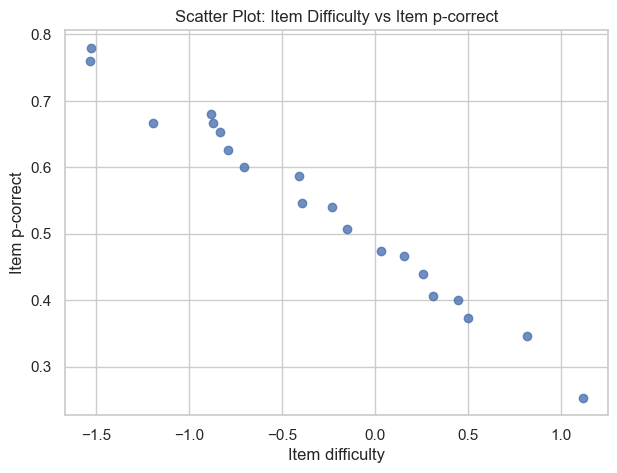

In [6]:
# Show how item difficulty relates to each item's observed p-correct.
plt.figure(figsize=(7, 5))
plt.scatter(b_true, item_prop_correct, alpha=0.8)
plt.xlabel('Item difficulty')
plt.ylabel('Item p-correct')
plt.title('Scatter Plot: Item Difficulty vs Item p-correct')
plt.show()

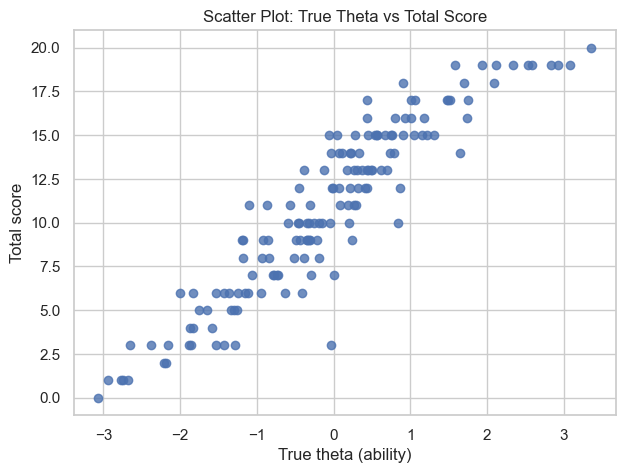

In [7]:
# show total score vs true theta
plt.figure(figsize=(7, 5))
plt.scatter(theta_true, total_score, alpha=0.8)
plt.xlabel('True theta (ability)')
plt.ylabel('Total score')
plt.title('Scatter Plot: True Theta vs Total Score')
plt.show()

### Probabilistic Modeling with Stan

In [8]:
# Write the Stan model file for Rasch ability estimation with known item difficulties.
stan_code = r'''
data {
  int<lower=1> N; // number of students
  int<lower=1> K; // number of items
  array[N, K] int<lower=0, upper=1> y; // response matrix
  vector[K] b; // known item difficulties
  int<lower=0, upper=1> use_prior; // flag to use prior
  real<lower=0> prior_sd; // standard deviation of prior
}
parameters {
  vector[N] theta; // student abilities
}
model {
  if (use_prior == 1)
    theta ~ normal(0, prior_sd);
  for (n in 1:N)
    y[n] ~ bernoulli_logit(theta[n] - b);
}
generated quantities {
  vector[N] log_lik;
  array[N, K] int y_rep;
  for (n in 1:N) {
    real lp = 0;
    for (j in 1:K) {
      lp += bernoulli_logit_lpmf(y[n, j] | theta[n] - b[j]);
      y_rep[n, j] = bernoulli_logit_rng(theta[n] - b[j]);
    }
    log_lik[n] = lp;
  }
}
'''

stan_path = 'rasch_known_item_ability.stan'
with open(stan_path, 'w', encoding='utf-8') as f:
    f.write(stan_code)

print(f'Wrote Stan file: {stan_path}')

Wrote Stan file: rasch_known_item_ability.stan


In [9]:
# Placeholder for optional CmdStan compiler installation if the environment needs it.
# cmdstanpy.install_cmdstan(compiler=True)

### MLE/MAP Point Estimation

In [10]:
# Compile the Stan model, obtain MLE ability estimates, and compute Wald confidence intervals.
model = CmdStanModel(stan_file=stan_path)

data_mle = {
    'N': int(non_extreme_mask.sum()),
    'K': K,
    'y': y[non_extreme_mask].tolist(),
    'b': b_true.tolist(),
    'use_prior': 0,
    'prior_sd': 5.0
}

# Run optimization to get MLE estimates of theta for non-extreme students.
fit_opt = model.optimize(data=data_mle, seed=5101, algorithm='lbfgs', iter=2000)

# Extract MLE estimates of theta for non-extreme students, leaving NaN for extreme patterns.
theta_mle = np.full(N, np.nan)
theta_mle[non_extreme_mask] = fit_opt.stan_variable('theta')

# Compute standard errors and Wald confidence intervals for the MLE estimates, excluding extreme patterns.
p_mle = expit(theta_mle[non_extreme_mask][:, None] - b_true[None, :])
mle_info = np.sum(p_mle * (1 - p_mle), axis=1)
theta_mle_se = np.full(N, np.nan)
theta_mle_se[non_extreme_mask] = 1 / np.sqrt(mle_info)
theta_mle_ci_low = np.full(N, np.nan)
theta_mle_ci_high = np.full(N, np.nan)
theta_mle_ci_low[non_extreme_mask] = theta_mle[non_extreme_mask] - 1.96 * theta_mle_se[non_extreme_mask]
theta_mle_ci_high[non_extreme_mask] = theta_mle[non_extreme_mask] + 1.96 * theta_mle_se[non_extreme_mask]

print('Optimization complete.')
print(f'MLE estimated {non_extreme_mask.sum()} of {N} students.')
print(f'Excluded extreme response patterns: {(~non_extreme_mask).sum()}')
print(f'Mean of MLE standard errors: {np.nanmean(theta_mle_se[non_extreme_mask]):.3f}')
print(f'Mean of CI widths: {np.nanmean(theta_mle_ci_high - theta_mle_ci_low):.3f}')
print(f'CI[1]: [{theta_mle_ci_low[non_extreme_mask][0]:.3f}, {theta_mle_ci_high[non_extreme_mask][0]:.3f}]')
print(f'Correlation(true, MLE | non-extreme only) = {np.corrcoef(theta_true[non_extreme_mask], theta_mle[non_extreme_mask])[0,1]:.3f}')
print(f'Mean approximate 95% CI width: {np.nanmean(theta_mle_ci_high - theta_mle_ci_low):.3f}')

14:59:19 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\KOS-5101\irt\rasch_known_item_ability.stan to exe file C:\Users\yongduek\Downloads\KOS-5101\irt\rasch_known_item_ability.exe
14:59:35 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\KOS-5101\irt\rasch_known_item_ability.exe
14:59:35 - cmdstanpy - INFO - Chain [1] start processing
14:59:35 - cmdstanpy - INFO - Chain [1] done processing


Optimization complete.
MLE estimated 148 of 150 students.
Excluded extreme response patterns: 2
Mean of MLE standard errors: 0.577
Mean of CI widths: 2.262
CI[1]: [-0.572, 1.370]
Correlation(true, MLE | non-extreme only) = 0.936
Mean approximate 95% CI width: 2.262


### Wald-Type 95% Confidence Intervals for the MLE Ability Estimates

After `optimize()` returns the MLE estimates $\hat\theta_j$, the notebook computes an approximate confidence interval for each non-extreme student by using the observed Fisher information of the Rasch likelihood.

For a student $j$ with known item difficulties $b_i$, the Rasch model implies
$$
P(Y_{ji}=1 \mid \theta_j, b_i) = \operatorname{logit}^{-1}(\theta_j - b_i).
$$
Evaluating this probability at the MLE gives
$$
\hat p_{ji} = \operatorname{logit}^{-1}(\hat\theta_j - b_i).
$$

In the Rasch model, the observed Fisher information for $\theta_j$ is approximated by
$$
I(\hat\theta_j) = \sum_{i=1}^{K} \hat p_{ji}(1-\hat p_{ji}).
$$
This quantity measures the local curvature of the log-likelihood around the MLE. Larger information means a sharper likelihood and therefore a more precise estimate.

Using the usual large-sample normal approximation for maximum likelihood estimators, the standard error is estimated by
$$
\operatorname{SE}(\hat\theta_j) \approx \frac{1}{\sqrt{I(\hat\theta_j)}}.
$$
The resulting Wald-type 95% confidence interval is
$$
\hat\theta_j \pm 1.96\,\operatorname{SE}(\hat\theta_j).
$$

These intervals are approximate rather than exact. They rely on asymptotic normality of the MLE and work best when the likelihood is reasonably regular. That is why the notebook excludes the all-0 and all-1 response patterns from the MLE step: for those extreme patterns, the no-prior likelihood does not provide a stable finite MLE or a reliable Wald interval.

See Appendix for further explanation.

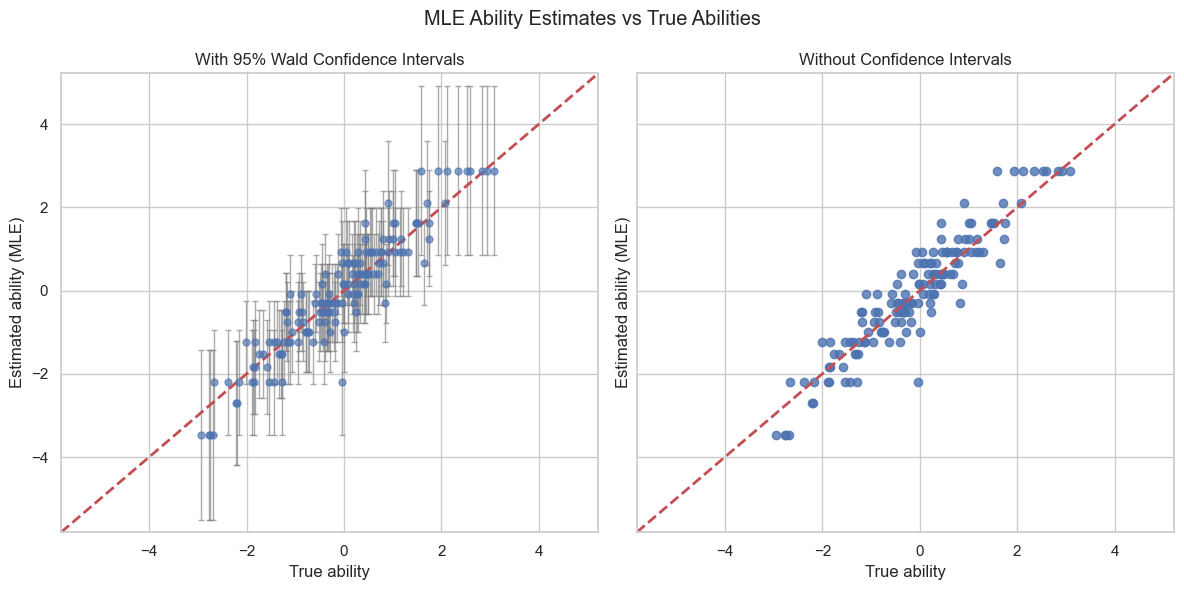

In [11]:
# Compare the non-extreme students' MLE ability estimates against their true abilities in two parallel panels.
finite_mle_mask = np.isfinite(theta_mle)

x_vals = theta_true[finite_mle_mask]
y_vals = theta_mle[finite_mle_mask]
yerr_low = y_vals - theta_mle_ci_low[finite_mle_mask]
yerr_high = theta_mle_ci_high[finite_mle_mask] - y_vals
xy_min = min(x_vals.min(), theta_mle_ci_low[finite_mle_mask].min()) - 0.3
xy_max = max(x_vals.max(), theta_mle_ci_high[finite_mle_mask].max()) + 0.3

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

axes[0].errorbar(
    x_vals,
    y_vals,
    yerr=[yerr_low, yerr_high],
    fmt='o',
    alpha=0.65,
    ecolor='gray',
    elinewidth=1,
    capsize=2,
    markersize=5
)
axes[0].plot([xy_min, xy_max], [xy_min, xy_max], 'r--', lw=2)
axes[0].set_xlim(xy_min, xy_max)
axes[0].set_ylim(xy_min, xy_max)
axes[0].set_xlabel('True ability')
axes[0].set_ylabel('Estimated ability (MLE)')
axes[0].set_title('With 95% Wald Confidence Intervals')

axes[1].scatter(x_vals, y_vals, alpha=0.8)
axes[1].plot([xy_min, xy_max], [xy_min, xy_max], 'r--', lw=2)
axes[1].set_xlim(xy_min, xy_max)
axes[1].set_ylim(xy_min, xy_max)
axes[1].set_xlabel('True ability')
axes[1].set_ylabel('Estimated ability (MLE)')
axes[1].set_title('Without Confidence Intervals')

fig.suptitle('MLE Ability Estimates vs True Abilities', y=0.98)
plt.tight_layout()
plt.show()

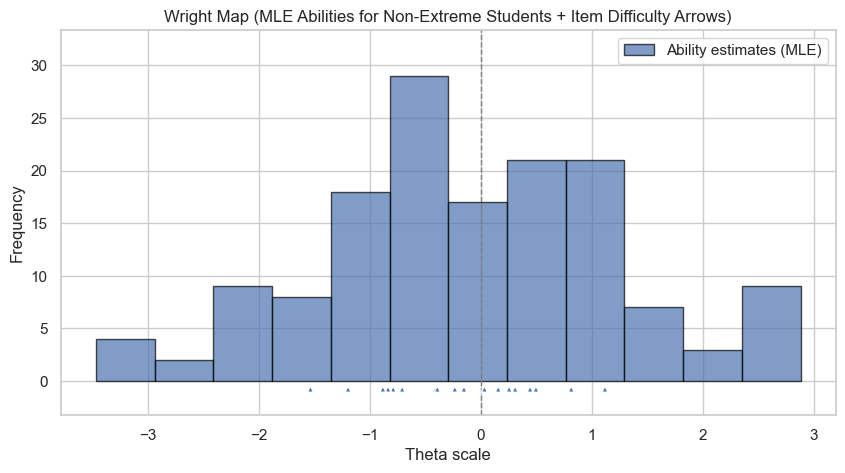

In [12]:
# Build a Wright map from the non-extreme students' MLE estimates and the known item difficulties.
plt.figure(figsize=(10, 5))
counts, bins, _ = plt.hist(theta_mle[finite_mle_mask], bins=12, alpha=0.7, edgecolor='black', label='Ability estimates (MLE)')

y_arrow = -max(counts) * 0.08 if len(counts) else -1
for j, bj in enumerate(b_true):
    plt.annotate('', xy=(bj, 0), xytext=(bj, y_arrow), arrowprops=dict(arrowstyle='-|>', lw=1.2))

plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.ylim(y_arrow * 1.4, max(counts) * 1.15 if len(counts) else 1)
plt.xlabel('Theta scale')
plt.ylabel('Frequency')
plt.title('Wright Map (MLE Abilities for Non-Extreme Students + Item Difficulty Arrows)')
plt.legend()
plt.show()

### Posterior Density Estimation (MCMC Posterior Sampling)

In [13]:
# Run Bayesian MCMC estimation with a weak prior for all students, including the extreme patterns.
data_mcmc = {
    'N': N,
    'K': K,
    'y': y.tolist(),
    'b': b_true.tolist(),
    'use_prior': 1,          # Use the weak prior for all students, including those with extreme response patterns.
    'prior_sd': 5.0          # Check the Stan code for this prior option.
}

fit_mcmc = model.sample(
    data=data_mcmc,
    seed=5101,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    show_progress=True
)

theta_draws = fit_mcmc.stan_variable('theta')  # shape: (draws, N)
theta_post_mean = theta_draws.mean(axis=0)

print(f'Draws shape: {theta_draws.shape}')
print(f'Correlation(true, posterior mean) = {np.corrcoef(theta_true, theta_post_mean)[0,1]:.3f}')

14:59:36 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

14:59:43 - cmdstanpy - INFO - CmdStan done processing.



Draws shape: (4000, 150)
Correlation(true, posterior mean) = 0.931


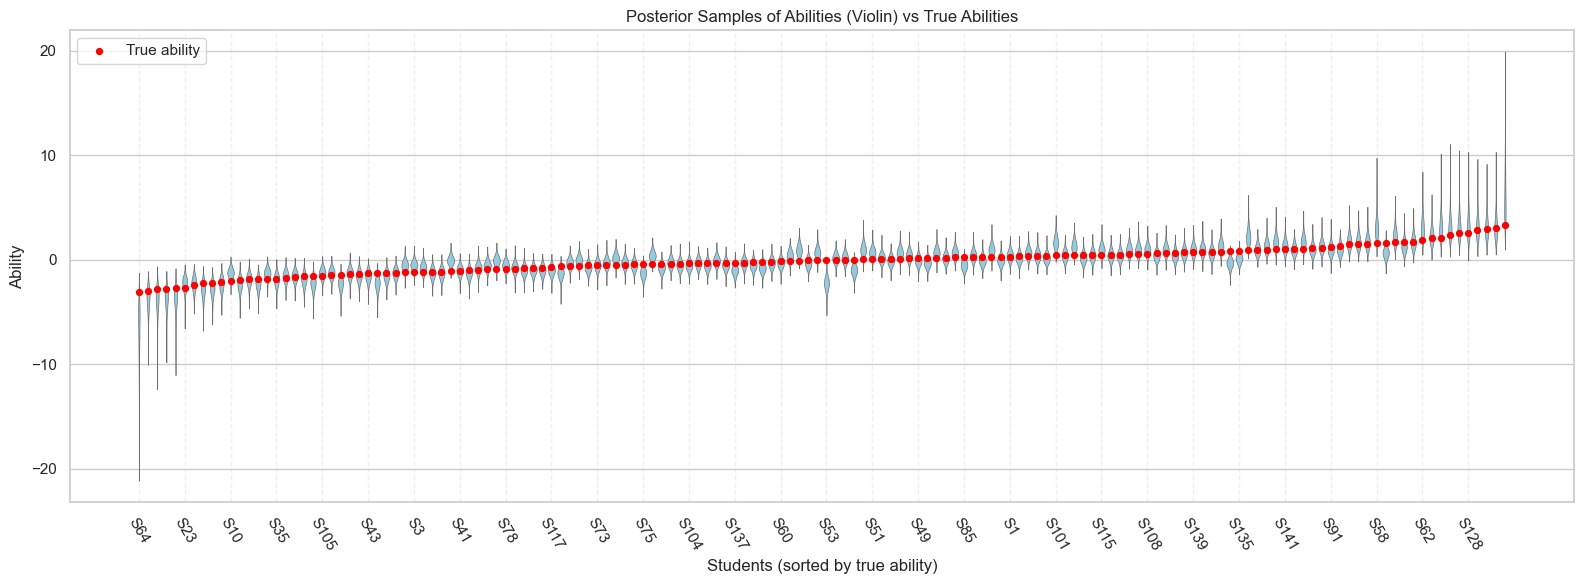

In [14]:
# Visualize posterior ability uncertainty for all students against the true ordered abilities.
order = np.argsort(theta_true)
theta_true_sorted = theta_true[order]
theta_draws_sorted = theta_draws[:, order]

df_long = pd.DataFrame(theta_draws_sorted, columns=[f'S{j+1}' for j in range(N)])
df_long = df_long.melt(var_name='student', value_name='theta_sample')

student_positions = np.arange(N)
pos_map = {f'S{j+1}': j for j in range(N)}
df_long['x'] = df_long['student'].map(pos_map)

plt.figure(figsize=(16, 6))
sns.violinplot(data=df_long, x='x', y='theta_sample', inner=None, cut=0, color='skyblue', linewidth=0.5)
plt.scatter(student_positions, theta_true_sorted, color='red', s=18, label='True ability', zorder=3)
plt.xlabel('Students (sorted by true ability)')
plt.xticks(student_positions[::5], [f'S{order[i]+1}' for i in student_positions[::5]], rotation=-60)
plt.grid(True, which='both', axis='x', linestyle='--', alpha=0.3)
plt.ylabel('Ability')
plt.title('Posterior Samples of Abilities (Violin) vs True Abilities')
plt.legend()
plt.tight_layout()
plt.show()

##### Compare with True Parameters
- To check the performance of the MCMC sampling method
- A true parameter does not have to be inside the density range
- The density depends on **data** as well as **prior** model

In [15]:
# Identify students whose true ability falls outside the central 96% posterior interval.
ci_low = np.quantile(theta_draws, 0.02, axis=0)
ci_high = np.quantile(theta_draws, 0.98, axis=0)

outside_mask = (theta_true < ci_low) | (theta_true > ci_high)
outside_idx = np.where(outside_mask)[0]

print(f'Number outside 96% posterior interval: {outside_idx.size}')

if outside_idx.size > 0:
    outside_df = pd.DataFrame({
        'student_index_1based': outside_idx + 1,
        'theta_true': theta_true[outside_idx],
        'ci_low_2%': ci_low[outside_idx],
        'ci_high_98%': ci_high[outside_idx],
    }).sort_values('student_index_1based')
    print(outside_df.to_string(index=False))
else:
    print('All true abilities are inside their 96% posterior intervals.')

Number outside 96% posterior interval: 4
 student_index_1based  theta_true  ci_low_2%  ci_high_98%
                   27    0.832984  -1.302934     0.741924
                   31   -1.098212  -1.066792     0.933780
                   53   -0.031866  -3.808317    -1.000700
                  101    0.429761   0.500382     3.293102


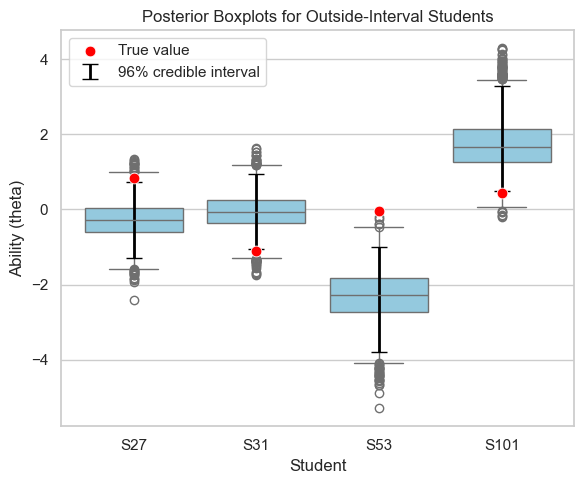

In [16]:
# Plot posterior boxplots for the students whose true abilities fall outside their 96% intervals.
if 'outside_df' in globals() and isinstance(outside_df, pd.DataFrame) and not outside_df.empty:
    if 'student_index_1based' in outside_df.columns:
        idx0 = outside_df['student_index_1based'].to_numpy(dtype=int) - 1
    else:
        raise ValueError("outside_df exists but does not contain 'student_index_1based'.")
elif 'range_outside_idx' in globals() and len(range_outside_idx) > 0:
    idx0 = np.asarray(range_outside_idx, dtype=int)
elif 'outside_idx' in globals() and len(outside_idx) > 0:
    idx0 = np.asarray(outside_idx, dtype=int)
else:
    raise ValueError("No outside student indices found (outside_df/range_outside_idx/outside_idx).")

labels = [f"S{i+1}" for i in idx0]
draws_subset = theta_draws[:, idx0]

plot_df = pd.DataFrame(draws_subset, columns=labels).melt(
    var_name='student', value_name='theta_sample'
)
true_subset = pd.DataFrame({
    'student': labels,
    'theta_true': theta_true[idx0]
})

plt.figure(figsize=(max(6, 1.2 * len(labels)), 5))
sns.boxplot(data=plot_df, x='student', y='theta_sample', color='skyblue')
sns.scatterplot(data=true_subset, x='student', y='theta_true', color='red', s=60, zorder=3, label='True value')
ci_low = np.quantile(draws_subset, 0.02, axis=0)
ci_high = np.quantile(draws_subset, 0.98, axis=0)
ci_mid = 0.5 * (ci_low + ci_high)
x_pos = np.arange(len(labels))

plt.errorbar(
    x_pos,
    ci_mid,
    yerr=[ci_mid - ci_low, ci_high - ci_mid],
    fmt='none',
    ecolor='black',
    elinewidth=2,
    capsize=6,
    label='96% credible interval',
    zorder=2
)

plt.title('Posterior Boxplots for Outside-Interval Students')
plt.xlabel('Student')
plt.ylabel('Ability (theta)')
plt.legend()
plt.tight_layout()
plt.show()

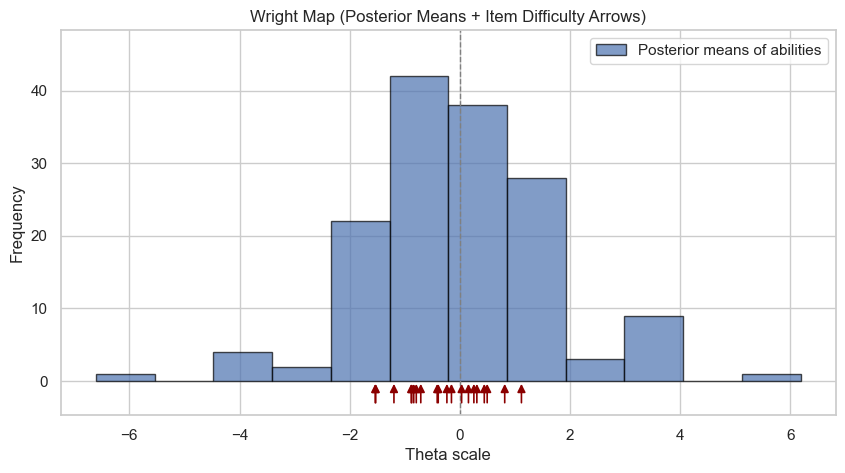

In [17]:
# Build a Wright map from the posterior mean abilities and the known item difficulties.
plt.figure(figsize=(10, 5))
counts, bins, _ = plt.hist(theta_post_mean, bins=12, alpha=0.7, edgecolor='black', label='Posterior means of abilities')

y_arrow = -max(counts) * 0.08 if len(counts) else -1
for bj in b_true:
    plt.annotate('', xy=(bj, 0), xytext=(bj, y_arrow), arrowprops=dict(arrowstyle='-|>', lw=1.2, color='darkred'))

plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.ylim(y_arrow * 1.4, max(counts) * 1.15 if len(counts) else 1)
plt.xlabel('Theta scale')
plt.ylabel('Frequency')
plt.title('Wright Map (Posterior Means + Item Difficulty Arrows)')
plt.legend()
plt.show()

### PPC: Posterior Predictive Check
- Generate data samples using posterior parameter samples to check if the input data is included in the range of samples.
- Item-level P-Correct (정답류) will be used here.

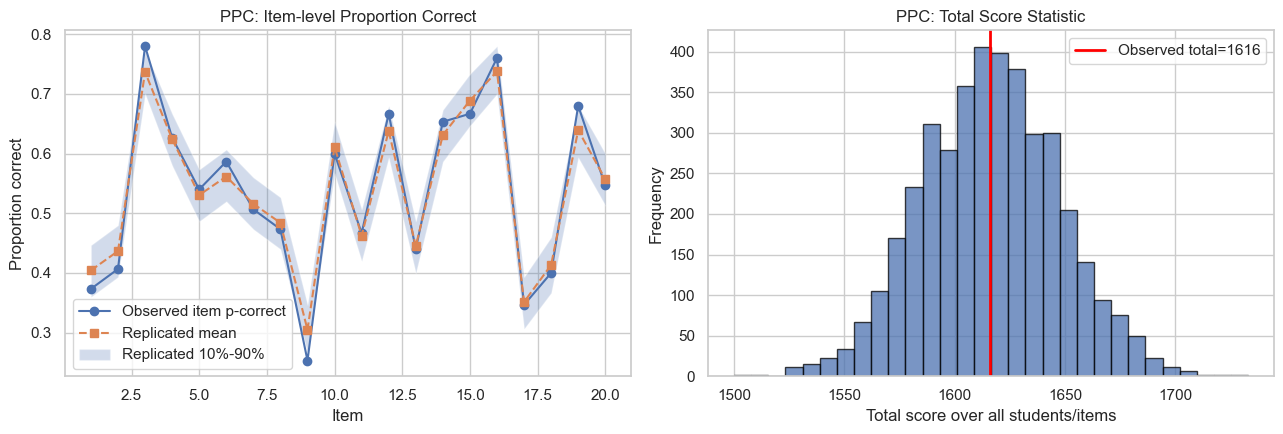

Posterior predictive p-correct for the total-score statistic: 0.508


In [18]:
# Run posterior predictive checks for item-level fit and the overall total-score statistic.
y_rep_draws = fit_mcmc.stan_variable('y_rep')  # shape: (draws, N, K)

obs_item_mean = y.mean(axis=0)
rep_item_mean = y_rep_draws.mean(axis=1)  # (draws, K)

obs_total = y.sum()
rep_total = y_rep_draws.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(np.arange(1, K + 1), obs_item_mean, 'o-', label='Observed item p-correct')
axes[0].plot(np.arange(1, K + 1), rep_item_mean.mean(axis=0), 's--', label='Replicated mean')
axes[0].fill_between(
    np.arange(1, K + 1),
    np.quantile(rep_item_mean, 0.1, axis=0),
    np.quantile(rep_item_mean, 0.9, axis=0),
    alpha=0.25,
    label='Replicated 10%-90%'
)
axes[0].set_xlabel('Item')
axes[0].set_ylabel('Proportion correct')
axes[0].set_title('PPC: Item-level Proportion Correct')
axes[0].legend()

axes[1].hist(rep_total, bins=30, alpha=0.75, edgecolor='black')
axes[1].axvline(obs_total, color='red', lw=2, label=f'Observed total={obs_total}')
axes[1].set_xlabel('Total score over all students/items')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PPC: Total Score Statistic')
axes[1].legend()

plt.tight_layout()
plt.show()

p_val = np.mean(rep_total >= obs_total)
print(f'Posterior predictive p-correct for the total-score statistic: {p_val:.3f}')

### Posterior Predictive Check: P-Correct

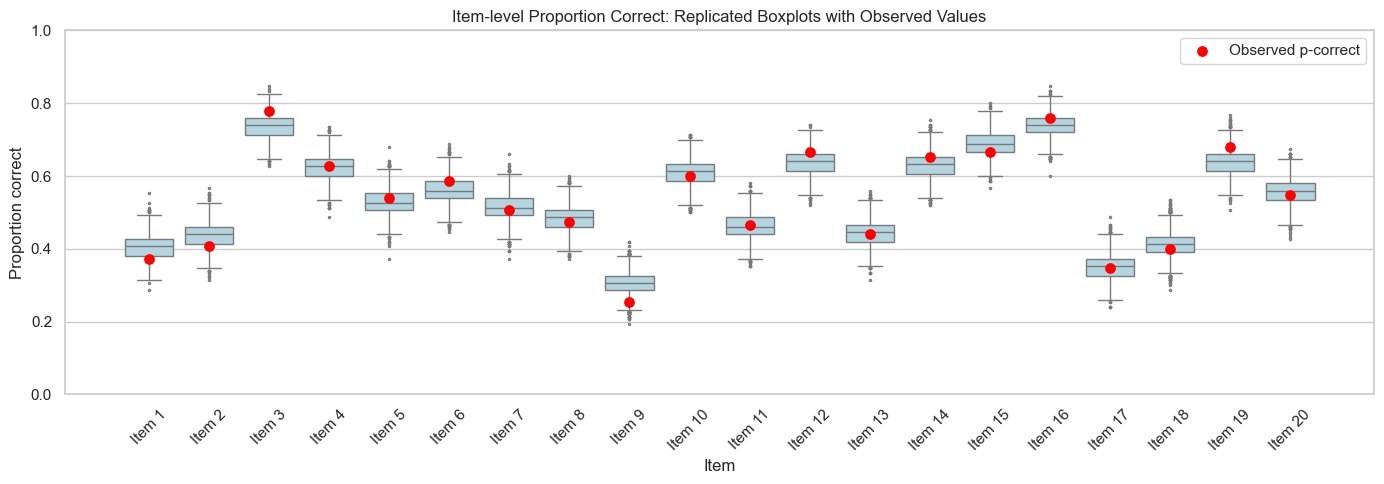

In [19]:
# Compare observed item p-correct values with posterior predictive item-level distributions.
obs_item_mean = y.mean(axis=0)

rep_item_df = pd.DataFrame(
    rep_item_mean,
    columns=[f'Item {i+1}' for i in range(rep_item_mean.shape[1])]
).melt(var_name='item', value_name='rep_p_correct')

plt.figure(figsize=(14, 5))
sns.boxplot(data=rep_item_df, x='item', y='rep_p_correct', color='lightblue', fliersize=1.5)
plt.scatter(
    np.arange(rep_item_mean.shape[1]),
    obs_item_mean,
    color='red',
    s=45,
    zorder=3,
    label='Observed p-correct'
)

plt.xlabel('Item')
plt.ylabel('Proportion correct')
plt.title('Item-level Proportion Correct: Replicated Boxplots with Observed Values')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

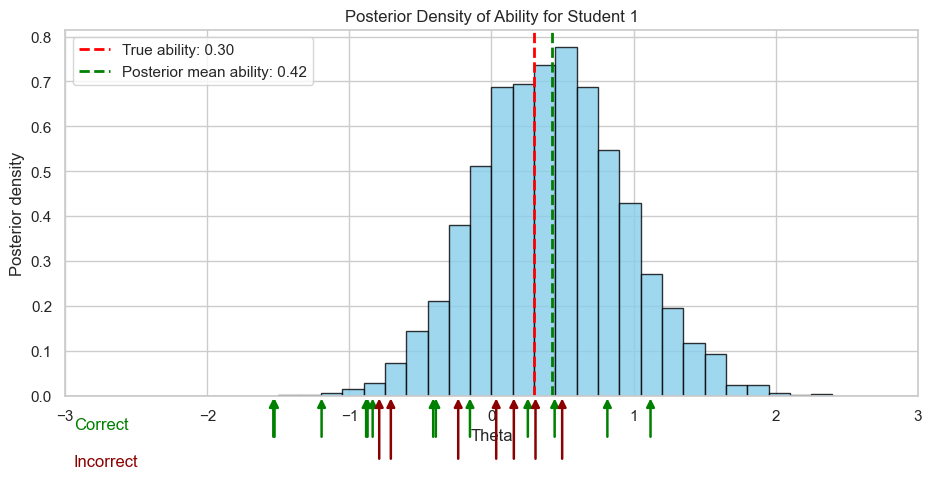

In [20]:
# Show Student 1's posterior ability density with response arrows whose tips meet the theta axis.
student_idx = 0
theta_samples_student = theta_draws[:, student_idx]
student_responses = y[student_idx, :]

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    theta_samples_student,
    bins=40,
    range=(-3, 3),
    density=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.8
)
ax.set_xlim(-3, 3)
ax.set_xlabel('Theta')
ax.set_ylabel('Posterior density')
ax.set_title(f'Posterior Density of Ability for Student {student_idx + 1}')
ax.axvline(theta_true[student_idx], color='red', linestyle='--', lw=2, 
           label=f'True ability: {theta_true[student_idx]:.2f}')
ax.axvline(theta_post_mean[student_idx], color='green', linestyle='--', lw=2, 
           label=f'Posterior mean ability: {theta_post_mean[student_idx]:.2f}')

correct_mask = student_responses == 1
incorrect_mask = student_responses == 0

for bj in b_true[correct_mask]:
    ax.annotate(
        '',
        xy=(bj, 0.0),
        xytext=(bj, -0.12),
        xycoords=('data', 'axes fraction'),
        textcoords=('data', 'axes fraction'),
        arrowprops=dict(arrowstyle='-|>', color='green', lw=1.8),
        annotation_clip=False
    )

for bj in b_true[incorrect_mask]:
    ax.annotate(
        '',
        xy=(bj, 0.0),
        xytext=(bj, -0.18),
        xycoords=('data', 'axes fraction'),
        textcoords=('data', 'axes fraction'),
        arrowprops=dict(arrowstyle='-|>', color='darkred', lw=1.8),
        annotation_clip=False
    )

ax.text(
    0.01, -0.08, 'Correct',
    transform=ax.transAxes, color='green',
    va='center', ha='left'
)
ax.text(
    0.01, -0.18, 'Incorrect',
    transform=ax.transAxes, color='darkred',
    va='center', ha='left'
)

ax.margins(x=0.02)
plt.subplots_adjust(bottom=0.27)
ax.legend(loc='upper left')
plt.show()

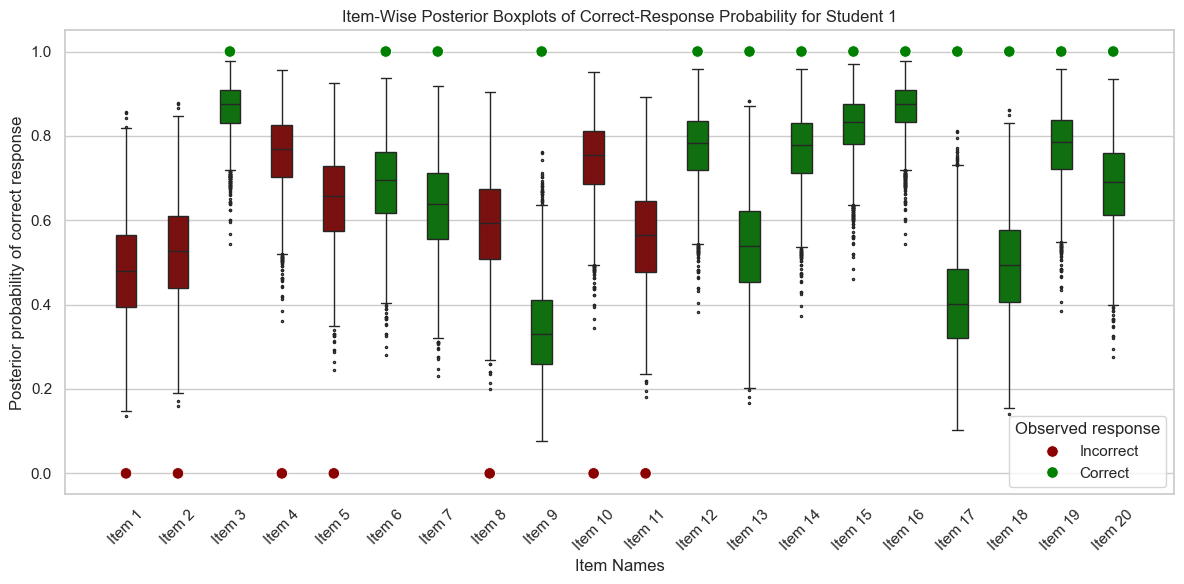

Student 1 total score: 13/20


In [21]:
# Show Student 1's item-wise posterior probability distributions with response-colored box plots.
item_labels = [f'Item {i+1}' for i in range(K)]
p_correct_draws_student = expit(theta_samples_student[:, None] - b_true[None, :])

observed_prob_df = pd.DataFrame({
    'item': item_labels,
    'observed_response': student_responses.astype(float),
    'response_label': np.where(student_responses == 1, 'Correct', 'Incorrect')
})

item_prob_df = pd.DataFrame(
    p_correct_draws_student,
    columns=item_labels
).melt(var_name='item', value_name='p_correct')
item_prob_df['item_color_group'] = item_prob_df['item']

box_palette = {
    item: ('green' if response == 1 else 'darkred')
    for item, response in zip(item_labels, student_responses)
}

plt.figure(figsize=(max(12, 0.55 * K), 6))
sns.boxplot(
    data=item_prob_df,
    x='item',
    y='p_correct',
    hue='item_color_group',
    palette=box_palette,
    dodge=False,
    width=0.4,
    fliersize=1.5,
    legend=False
)
sns.scatterplot(
    data=observed_prob_df,
    x='item',
    y='observed_response',
    hue='response_label',
    palette={'Correct': 'green', 'Incorrect': 'darkred'},
    s=70,
    zorder=3
)
plt.xlabel('Item Names')
plt.ylabel('Posterior probability of correct response')
plt.title(f'Item-Wise Posterior Boxplots of Correct-Response Probability for Student {student_idx + 1}')
plt.ylim(-0.05, 1.05)
plt.xticks(rotation=45)
plt.legend(title='Observed response', loc='lower right')
plt.tight_layout()
plt.show()

print(f"Student {student_idx + 1} total score: {student_responses.sum()}/{K}")

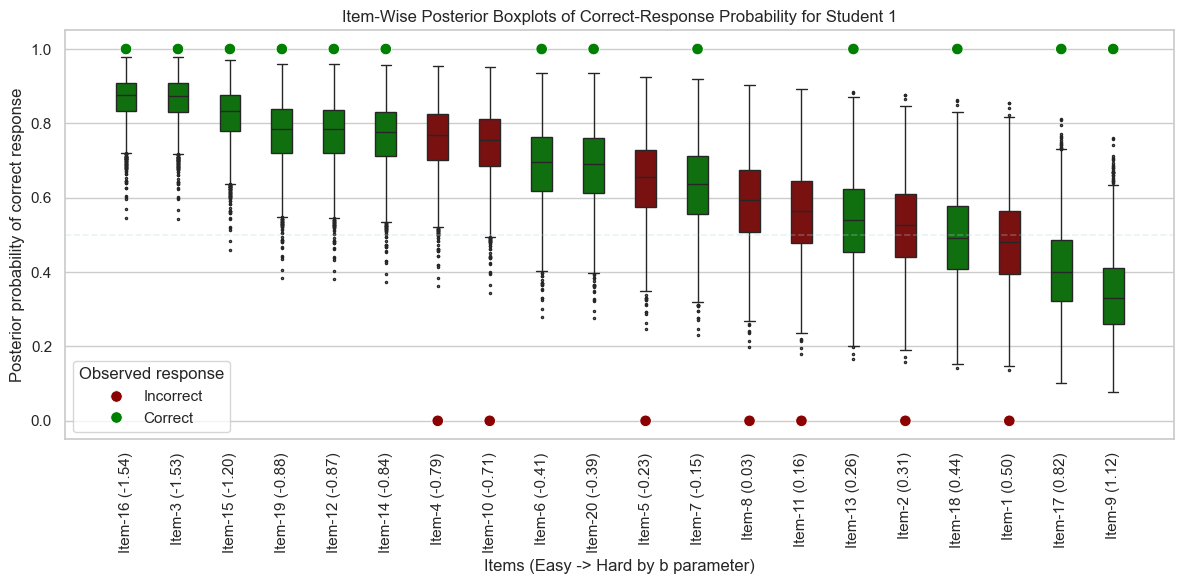

Student 1 total score: 13/20


In [22]:
# Show Student 1's item-wise posterior probability distributions with response-colored box plots, ordered from easy to hard.
item_labels = [f'Item-{i+1} ({b_true[i]:.2f})' for i in range(K)]
item_order = np.argsort(b_true)  # lower b = easier item
ordered_item_labels = [item_labels[j] for j in item_order]

p_correct_draws_student = expit(theta_samples_student[:, None] - b_true[None, :])

observed_prob_df = pd.DataFrame({
    'item': item_labels,
    'observed_response': student_responses.astype(float),
    'response_label': np.where(student_responses == 1, 'Correct', 'Incorrect')
})
observed_prob_df['item'] = pd.Categorical(
    observed_prob_df['item'],
    categories=ordered_item_labels,
    ordered=True
)

item_prob_df = pd.DataFrame(
    p_correct_draws_student,
    columns=item_labels
).melt(var_name='item', value_name='p_correct')

item_prob_df['item'] = pd.Categorical(
    item_prob_df['item'],
    categories=ordered_item_labels,
    ordered=True
)
item_prob_df['item_color_group'] = item_prob_df['item'].astype(str)

box_palette = {
    item_labels[j]: ('green' if student_responses[j] == 1 else 'darkred')
    for j in item_order
}

plt.figure(figsize=(max(12, 0.55 * K), 6))
sns.boxplot(
    data=item_prob_df,
    x='item',
    y='p_correct',
    hue='item_color_group',
    palette=box_palette,
    dodge=False,
    width=0.4,
    fliersize=1.5,
    legend=False,
    order=ordered_item_labels
)
sns.scatterplot(
    data=observed_prob_df,
    x='item',
    y='observed_response',
    hue='response_label',
    palette={'Correct': 'green', 'Incorrect': 'darkred'},
    s=70,
    zorder=3
)
plt.xlabel('Items (Easy -> Hard by b parameter)')
plt.ylabel('Posterior probability of correct response')
plt.title(f'Item-Wise Posterior Boxplots of Correct-Response Probability for Student {student_idx + 1}')
plt.ylim(-0.05, 1.05)
plt.axhline(y=0.5, color='lightblue', linestyle='--', linewidth=1.2, alpha=0.3)
plt.xticks(rotation=90)
plt.legend(title='Observed response', loc='lower left')
plt.tight_layout()
plt.show()

print(f"Student {student_idx + 1} total score: {student_responses.sum()}/{K}")

---
### 학생 1의  정보 곡선 (Information Curve) 

Index Notation: **i = 문항 index, j = 학생 index**

Rasch 모형(Rasch model)에서 문항 난이도(item difficulty) $b_i$가 알려져 있을 때, 학생 $j$의 정답확률(correct-response probability)은

$$
p(\theta_j,b_i)=\operatorname{logit}^{-1}(\theta_j-b_i)
$$

로 주어진다. 이때 베르누이 문항(Bernoulli item)의 피셔 정보(Fisher information)는

$$
I(\theta_j,b_i)=p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr)
$$

이다. 해당 함수는 다음 성질을 갖는다.

- 정보는 분산의 역수이다. $ I = 1/V $ : Information is the inverse of variance.
- $p(\theta_j,b_i)=0.5$일 때 최대가 된다.
- $p(\theta_j,b_i)$가 $0$ 또는 $1$에 가까워질수록 정보량은 감소한다.
- 따라서 $b_i$가 $\theta_j$에 근접할수록(문항-능력 정합, item-targeting) 측정정보가 커진다.

Rasch 모형에서 $p(\theta_j,b_i)=0.5$의 조건은 $\theta_j=b_i$이므로, 학생 1의 능력 수직선(vertical reference line) 근방에 위치한 문항들이 능력 추정에 핵심적으로 기여한다. 반대로 지나치게 쉬운 문항(too easy) 또는 지나치게 어려운 문항(too hard)은 응답이 거의 결정적이어서(near-deterministic) 능력 위치 식별(ability localization)에 덜 기여한다.

학생 1의 총정보(test information for one student)는 문항정보의 합으로 다음과 같이 정의된다.

$$
I(\theta_j)=\sum_{i=1}^{K} I(\theta_j,b_i)=\sum_{i=1}^{K} p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr)
$$

추정 정밀도(precision)와 표준오차(standard error) 사이에는

$$
\operatorname{SE}(\hat\theta_j)\approx\frac{1}{\sqrt{I(\theta_j)}}
$$

의 근사적 역관계가 성립한다. 따라서 총정보가 클수록 사후분포(posterior distribution)는 더 집중되고, 구간추정(credible interval)은 좁아진다.

실무적 해석(practical interpretation)으로는 다음이 중요하다.

1. 어떤 문항이 학생 1 측정의 중심을 이루는가
   능력 수직선 부근의 문항이 주된 기여 문항(core informative items)이다.
2. 검사 타기팅(targeting)의 적절성
   정보가 높은 문항이 능력 근처에 밀집할수록 해당 학생에 대한 측정 효율이 높다.
3. 왜 신용구간(credible interval) 폭이 달라지는가
   총정보가 크면 폭이 줄고, 총정보가 작으면 폭이 증가한다.
4. 적합도 해석에서 무엇이 중요한가
   Infit은 정보가중(information-weighted)이므로 능력 근처 문항의 영향이 상대적으로 크다.

---

### 검사정보곡선(TIC)의 이론적 측면과 실무 활용

검사정보곡선(Test Information Curve, TIC)은 능력수준 $\theta$에서 검사가 제공하는 총 정보량을 나타내며,

$$
I_{test}(\theta)=\sum_{i=1}^{K} I(\theta,b_i)
$$

로 정의된다.

이론적 측면(theoretical aspect)

- **국소 식별성(local identifiability)**: TIC가 큰 구간에서는 능력의 미세한 차이를 더 안정적으로 구분할 수 있다.
- **정밀도-정보 대응(precision-information duality)**: 일반적으로 $\mathrm{SE}(\theta)\approx1/\sqrt{I_{test}(\theta)}$ 관계가 성립한다.
- **검사-집단 정합(population targeting alignment)**: 피험자 능력분포와 TIC 고정보 구간이 일치할수록 검사 효율이 향상된다.

실무 활용(practical usage)

1. 검사 설계(test design) 및 문항선정(item selection)
   목표 능력대역에서 TIC가 충분히 높도록 난이도 분포를 설계한다.
2. 컴퓨터 적응검사(CAT, Computerized Adaptive Testing)
   현재 능력 추정치에서 정보가 큰 문항을 순차 제시하여 문항 수를 줄이고 정밀도를 확보한다.
3. 검사형 동등화(test equating)와 폼 구성(form assembly)
   복수 검사형의 TIC 형태를 유사하게 맞추어 측정 동질성을 유지한다.
4. 준거점 판정(cut-score decision)
   합격선 인근에서 TIC가 충분한지 검토하여 분류오차(classification error)를 줄인다.
5. 문항은행 관리(item bank management)
   저정보 구간(low-information region)을 진단해 신규 문항 개발 우선순위를 설정한다.

요약하면, TIC는 단순 시각화가 아니라 **측정 정밀도(precision), 타기팅(targeting), 판정 신뢰성(decision reliability)** 을 동시에 관리하는 핵심 지표이다.

---
아래 그래프에서는 학생 1번의 능력값에 대하여 정보량(Information)이 문항특성값 b에 따라 어떻게 바뀌는지 보여준다.
$$
    I(b) = I(\theta_0, b) = p(\theta_0, b)\bigl(1-p(\theta_0,b)\bigr)
$$
where
$$
p(\theta_j,b_i)=\operatorname{logit}^{-1}(\theta_j-b_i)
$$

베르누이 문항(Bernoulli item)의 피셔 정보(Fisher information)는

$$
I(\theta_j,b_i)=p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr)
$$

Student 1
Total score: 13/20
Posterior mean theta: 0.424
96% interval: [-0.581, 1.518]
Interval width: 2.099
Total test information at posterior mean: 4.050
Maximum test information on the plotted grid: 4.437 at theta = -0.305


,item,item_name,b,response,p_correct_at_post_mean,item_information
0,16,item-16,-1.535241,1,0.876427,0.108303
1,3,item-3,-1.526764,1,0.875506,0.108995
2,15,item-15,-1.195521,1,0.834699,0.137977
3,19,item-19,-0.882123,1,0.786827,0.167731
4,12,item-12,-0.871894,1,0.785106,0.168715
5,14,item-14,-0.836109,1,0.779007,0.172155
6,4,item-4,-0.789930,0,0.770955,0.176584
7,10,item-10,-0.708175,0,0.756199,0.184362
8,6,item-6,-0.410029,1,0.697160,0.211128
9,20,item-20,-0.391510,1,0.693235,0.212660


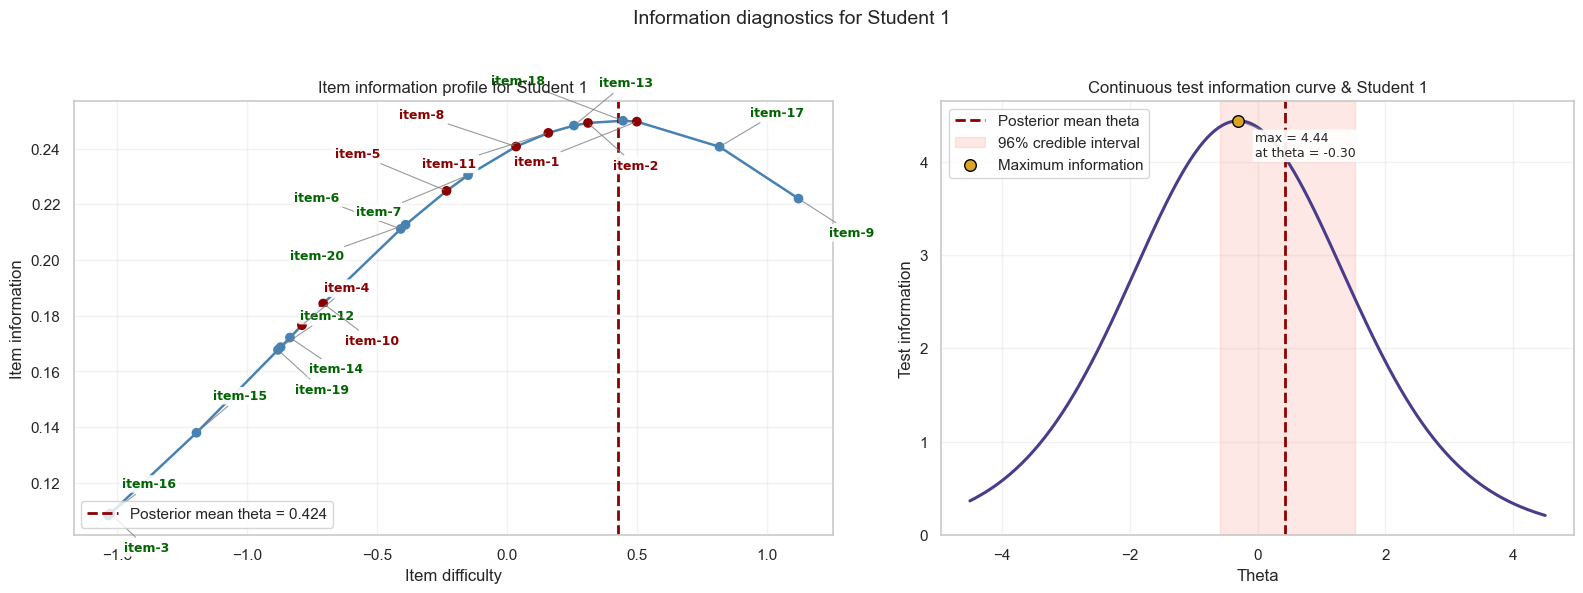

In [23]:
# Summarize Student 1 numerically and show how item information varies across difficulties.
i = 0   # student index for summary
K = len(b_true)

theta_ci_low = np.quantile(theta_draws[:, i], 0.02)
theta_ci_high = np.quantile(theta_draws[:, i], 0.98)
theta_ci_width = theta_ci_high - theta_ci_low

p_at_post_mean = expit(theta_post_mean[i] - b_true)
item_info = p_at_post_mean * (1 - p_at_post_mean)
item_names = [f'item-{i + 1}' for i in range(K)]

theta_grid_info = np.linspace(-4.5, 4.5, 400)
theta_grid_prob = expit(theta_grid_info[:, None] - b_true[None, :])
test_information_curve = np.sum(theta_grid_prob * (1 - theta_grid_prob), axis=1)
max_info_idx = int(np.argmax(test_information_curve))
theta_at_max_info = float(theta_grid_info[max_info_idx])
max_test_information = float(test_information_curve[max_info_idx])

student_summary = pd.DataFrame({
    'item': np.arange(1, K + 1),
    'item_name': item_names,
    'b': b_true,
    'response': y[i],
    'p_correct_at_post_mean': p_at_post_mean,
    'item_information': item_info
}).sort_values('b').reset_index(drop=True)

print(f"Student {i+1}")
print(f"Total score: {y[i].sum()}/{K}")
print(f"Posterior mean theta: {theta_post_mean[i]:.3f}")
print(f"96% interval: [{theta_ci_low:.3f}, {theta_ci_high:.3f}]")
print(f"Interval width: {theta_ci_width:.3f}")
print(f"Total test information at posterior mean: {item_info.sum():.3f}")
print(f"Maximum test information on the plotted grid: {max_test_information:.3f} at theta = {theta_at_max_info:.3f}")

display(student_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), gridspec_kw={'width_ratios': [1.2, 1.0]})
ax_items, ax_curve = axes

# Draw curve and color markers by observed response (0 -> dark red, 1 -> steel blue).
ax_items.plot(
    student_summary['b'],
    student_summary['item_information'],
    color='steelblue',
    linewidth=1.8
 )
marker_colors = np.where(student_summary['response'].to_numpy(dtype=int) == 0, 'darkred', 'steelblue')
ax_items.scatter(
    student_summary['b'],
    student_summary['item_information'],
    c=marker_colors,
    s=36,
    zorder=3
 )
ax_items.axvline(
    theta_post_mean[i],
    color='darkred',
    linestyle='--',
    linewidth=2,
    label=f"Posterior mean theta = {theta_post_mean[i]:.3f}"
 )

annotation_offsets = [
    (10, 18), (10, -20), (12, 22), (12, -24), (14, 18),
    (14, -18), (16, 22), (16, -22), (-44, 18), (-44, -18),
    (-48, 22), (-48, -22), (-52, 18), (-52, -18), (18, 26),
    (18, -26), (-56, 24), (-56, -24), (22, 20), (22, -20),
]

for idx, row in student_summary.iterrows():
    offset = annotation_offsets[idx % len(annotation_offsets)]
    label_color = 'darkgreen' if int(row['response']) == 1 else 'darkred'
    ax_items.annotate(
        row['item_name'],
        (row['b'], row['item_information']),
        textcoords='offset points',
        xytext=offset,
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        fontsize=9,
        fontfamily='DejaVu Sans',
        fontweight='semibold',
        color=label_color,
        bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.92),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.8),
        annotation_clip=False,
    )

ax_items.set_xlabel('Item difficulty')
ax_items.set_ylabel('Item information')
ax_items.set_title(f'Item information profile for Student {i+1}')
ax_items.legend(loc='lower left')
ax_items.grid(alpha=0.25)

ax_curve.plot(theta_grid_info, test_information_curve, color='darkslateblue', linewidth=2.2)
ax_curve.axvline(theta_post_mean[i], color='darkred', linestyle='--', linewidth=2, label='Posterior mean theta')
ax_curve.axvspan(theta_ci_low, theta_ci_high, color='salmon', alpha=0.18, label='96% credible interval')
ax_curve.scatter(theta_at_max_info, max_test_information, color='goldenrod', edgecolor='black', s=70, zorder=4, label='Maximum information')
ax_curve.annotate(
    f"max = {max_test_information:.2f}\nat theta = {theta_at_max_info:.2f}",
    (theta_at_max_info, max_test_information),
    textcoords='offset points',
    xytext=(12, -8),
    ha='left',
    va='top',
    fontsize=9,
    fontfamily='DejaVu Sans',
    bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.92),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.8),
)
ax_curve.set_xlabel('Theta')
ax_curve.set_ylabel('Test information')
ax_curve.set_title(f'Continuous test information curve & Student {i+1}')
ax_curve.grid(alpha=0.25)
ax_curve.legend(loc='upper left')

fig.suptitle(f'Information diagnostics for Student {i+1}', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

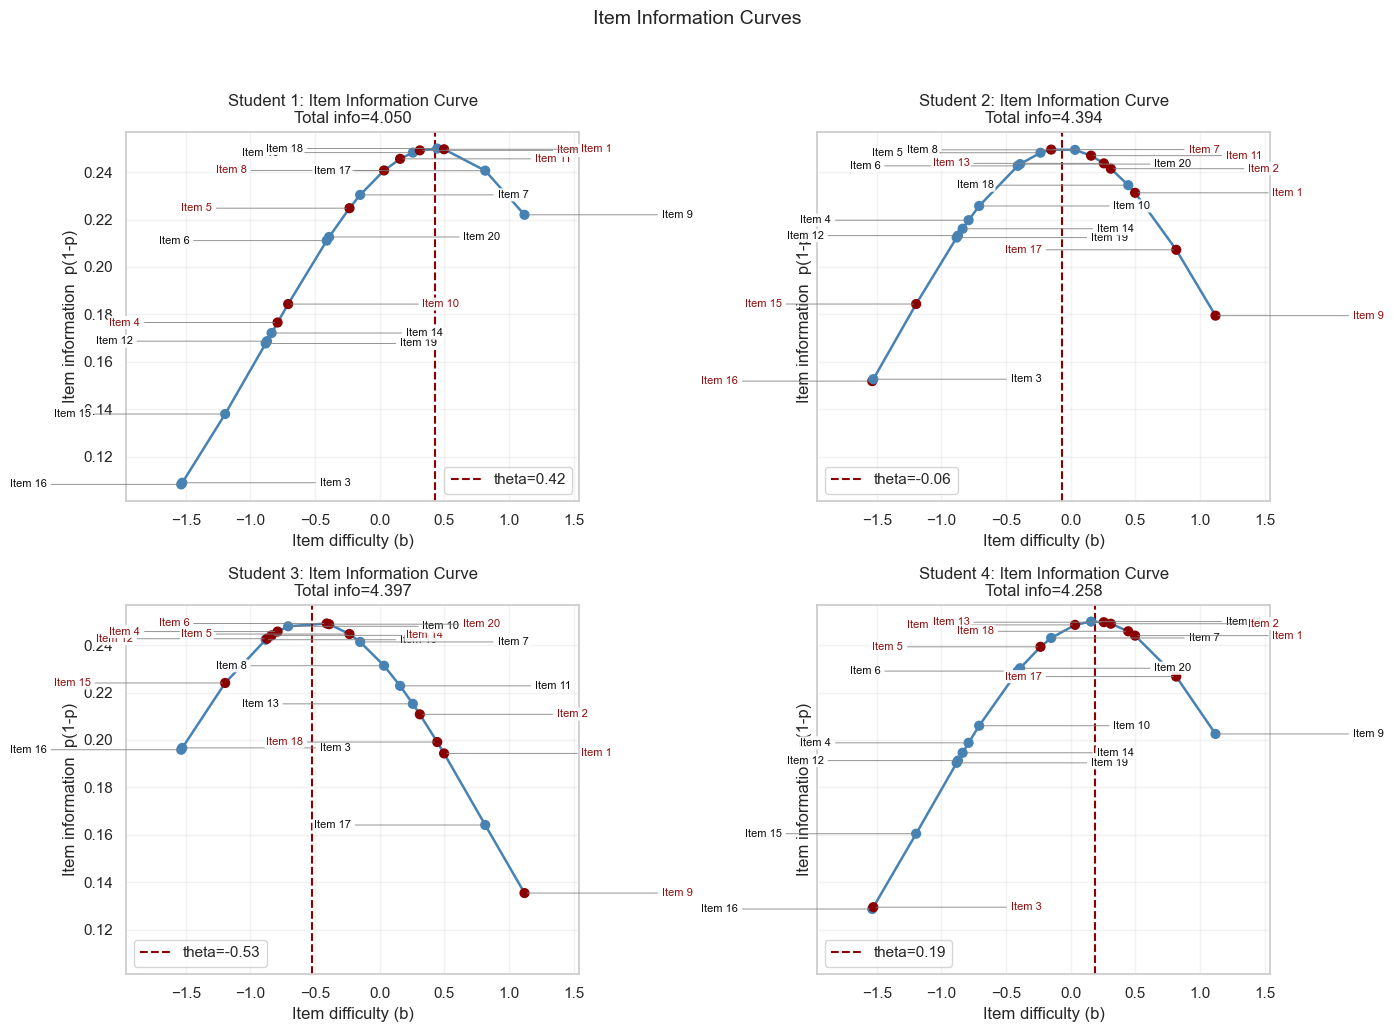

In [24]:
# Item-information profiles for Student 1-4 (evaluated at posterior mean theta)

student_indices = [0, 1, 2, 3]  # 0-based
student_labels = [f'Student {i+1}' for i in range(4)]
item_order = np.argsort(b_true)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

def _bbox_hits_points(bbox, points_disp):
    return np.any(
        (points_disp[:, 0] >= bbox.x0) & (points_disp[:, 0] <= bbox.x1) &
        (points_disp[:, 1] >= bbox.y0) & (points_disp[:, 1] <= bbox.y1)
    )

for ax, s_idx, s_label in zip(axes.flatten(), student_indices, student_labels):
    theta_s = theta_post_mean[s_idx]
    p_s = expit(theta_s - b_true)
    info_s = p_s * (1 - p_s)

    curve_x = b_true[item_order]
    curve_y = info_s[item_order]
    curve_xy = np.column_stack((curve_x, curve_y))
    response_ordered = y[s_idx, item_order]

    ax.plot(
        curve_x,
        curve_y,
        linewidth=1.8,
        color='steelblue',
        zorder=2
    )
    # Marker colors indicate observed responses: 1 -> blue, 0 -> dark red.
    marker_colors = np.where(response_ordered == 1, 'steelblue', 'darkred')
    ax.scatter(
        curve_x,
        curve_y,
        c=marker_colors,
        s=40,
        zorder=3
    )

    ax.axvline(theta_s, color='darkred', linestyle='--', linewidth=1.5, label=f'theta={theta_s:.2f}')
    ax.set_xlabel('Item difficulty (b)')
    ax.set_title(f'{s_label}: Item Information Curve\nTotal info={info_s.sum():.3f}')

    dense_segments = []
    for a, b in zip(curve_xy[:-1], curve_xy[1:]):
        t = np.linspace(0.0, 1.0, 25)[:, None]
        dense_segments.append(a[None, :] + (b - a)[None, :] * t)
    curve_dense_xy = np.vstack(dense_segments) if dense_segments else curve_xy

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    marker_points_disp = ax.transData.transform(np.column_stack((b_true, info_s)))
    curve_dense_disp = ax.transData.transform(curve_dense_xy)

    occupied_bboxes = []
    candidate_offsets = [
        (-56, 8), (56, 8), (-56, -8), (56, -8),
        (-76, 14), (76, 14), (-76, -14), (76, -14),
        (-96, 20), (96, 20), (-96, -20), (96, -20),
        (0, 24), (0, -24),
    ]

    for r, j in enumerate(item_order):
        label_color = 'black' if y[s_idx, j] == 1 else 'darkred'
        placed = False

        offsets = candidate_offsets if (r % 2 == 0) else [(dx, -dy) for (dx, dy) in candidate_offsets]

        for dx, dy in offsets:
            ann = ax.annotate(
                f'Item {j+1}',
                (b_true[j], info_s[j]),
                textcoords='offset points',
                xytext=(dx, dy),
                ha='center',
                va='center',
                fontsize=8,
                color=label_color,
                alpha=0.95,
                bbox=dict(boxstyle='round,pad=0.14', fc='white', ec='none', alpha=0.9),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.7, alpha=0.85),
            )

            bbox = ann.get_window_extent(renderer=renderer).expanded(1.10, 1.15)

            hit_marker = _bbox_hits_points(bbox, marker_points_disp)
            hit_curve = _bbox_hits_points(bbox, curve_dense_disp)
            hit_label = any(bbox.overlaps(prev) for prev in occupied_bboxes)

            if hit_marker or hit_curve or hit_label:
                ann.remove()
            else:
                occupied_bboxes.append(bbox)
                placed = True
                break

        if not placed:
            fallback = ax.annotate(
                f'Item {j+1}',
                (b_true[j], info_s[j]),
                textcoords='offset points',
                xytext=(-110 if (r % 2 == 0) else 110, 0),
                ha='center',
                va='center',
                fontsize=8,
                color=label_color,
                alpha=0.95,
                bbox=dict(boxstyle='round,pad=0.14', fc='white', ec='none', alpha=0.9),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.7, alpha=0.85),
            )
            occupied_bboxes.append(fallback.get_window_extent(renderer=renderer).expanded(1.10, 1.15))

    ax.margins(x=0.16)
    ax.grid(alpha=0.25)
    ax.legend()
    ax.set_ylabel('Item information  p(1-p)')

fig.suptitle('Item Information Curves', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

### Algorithm to Detect Students Who Miss Many Easy Items
A student who misses many easy items can be detected by combining item-level residual evidence and person-fit summaries.

1. Compute expected probabilities from the Rasch model: $p_{ji}=\operatorname{logit}^{-1}(\theta_j-b_i)$.
2. For each response, compute residual evidence:
   - Raw residual: $r_{ji}=y_{ji}-p_{ji}$
   - Standardized residual: $z_{ji}=\frac{y_{ji}-p_{ji}}{\sqrt{p_{ji}(1-p_{ji})}}$
3. Aggregate to person-fit statistics:
   - Outfit: $\text{Outfit}_j=\frac{1}{K}\sum_i z_{ji}^2$ (outlier-sensitive)
   - Infit: $\text{Infit}_j=\frac{\sum_i w_{ji}z_{ji}^2}{\sum_i w_{ji}},\; w_{ji}=p_{ji}(1-p_{ji})$
4. Using posterior draws of $\theta_j$, compute draw-wise outfit/infit and posterior misfit probabilities:
   - $P(\text{Outfit}_j > c_o\mid\text{data})$
   - $P(\text{Infit}_j > c_i\mid\text{data})$
5. Flag students showing the target pattern (wrong on easy items) when both hold:
   - enough wrong responses among predicted-easy items ($p_{ji}\geq$ threshold), and
   - posterior misfit evidence exceeds threshold.

The next cell applies this workflow to all students and visualizes outfit values with flagged students highlighted.

Total students: 150
Flagged as easy-item misfit: 1
Rule: easy_miss_count >= 2 among items with predicted p >= 0.80, and posterior misfit probability >= 0.80.


,student_id,theta_post_mean,easy_item_count,easy_miss_count,outfit_point,infit_point,prob_outfit_gt_cut,prob_infit_gt_cut,easy_miss_flag,posterior_misfit_flag,flag_easy_item_misfit
141,97,0.178316,2,2,1.529678,1.342982,0.66625,1.0,True,True,True


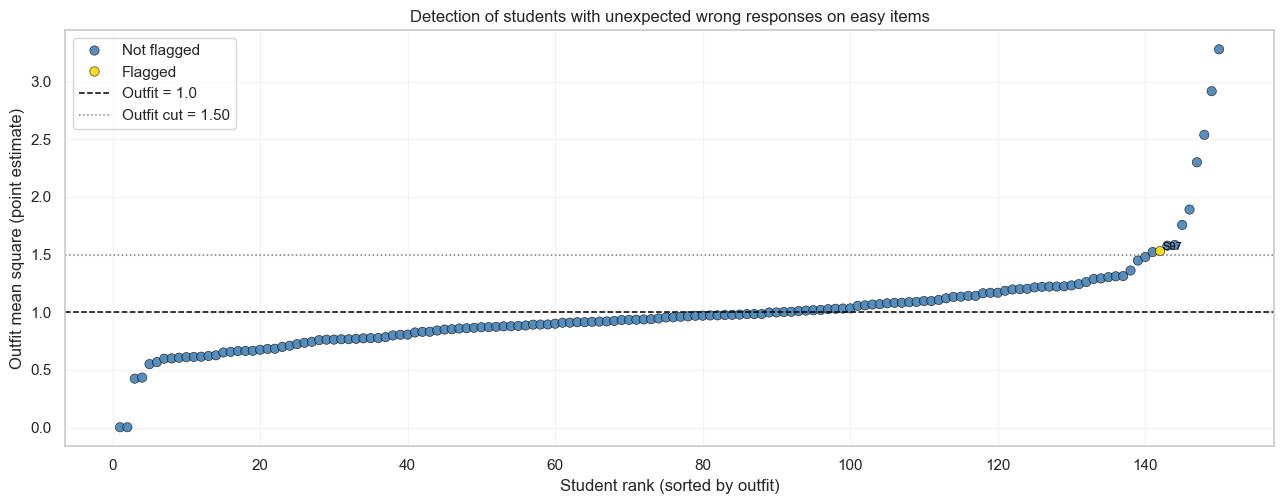

In [25]:
# Detect students with many wrong responses on easy items using residual fit and posterior probabilities.
# This cell applies the workflow to all students and visualizes outfit with flagged cases highlighted.

import pandas as pd
import seaborn as sns

# --- 0) Required arrays and posterior draws ---
if 'theta_draws' not in globals():
    theta_draws = fit_mcmc.stan_variable('theta')

K = len(b_true)
N = y.shape[0]

# --- 1) Point-estimate probabilities and item-level residual evidence ---
p_point = expit(theta_post_mean[:, None] - b_true[None, :])
w_point = np.clip(p_point * (1.0 - p_point), 1e-9, None)
z2_point = ((y - p_point) ** 2) / w_point

outfit_point = z2_point.mean(axis=1)
infit_point = (w_point * z2_point).sum(axis=1) / w_point.sum(axis=1)

# Easy-item miss counts: predicted-easy items answered incorrectly.
easy_prob_threshold = 0.80
easy_mask = p_point >= easy_prob_threshold
easy_miss_count = ((y == 0) & easy_mask).sum(axis=1)
easy_item_count = easy_mask.sum(axis=1)

# --- 2) Posterior draw-wise fit statistics ---
# Shapes: theta_draws[D, N], y[N, K], b_true[K]
p_draw = expit(theta_draws[:, :, None] - b_true[None, None, :])
w_draw = np.clip(p_draw * (1.0 - p_draw), 1e-9, None)
z2_draw = ((y[None, :, :] - p_draw) ** 2) / w_draw

outfit_draw = z2_draw.mean(axis=2)
infit_draw = (w_draw * z2_draw).sum(axis=2) / w_draw.sum(axis=2)

# --- 3) Posterior probabilities and flagging ---
outfit_cut = 1.50
infit_cut = 1.30
posterior_prob_threshold = 0.80
easy_miss_min_count = 2

prob_outfit_high = (outfit_draw > outfit_cut).mean(axis=0)
prob_infit_high = (infit_draw > infit_cut).mean(axis=0)

misfit_posterior_flag = (prob_outfit_high >= posterior_prob_threshold) | (prob_infit_high >= posterior_prob_threshold)
easy_miss_flag = easy_miss_count >= easy_miss_min_count
flag_easy_misfit = easy_miss_flag & misfit_posterior_flag

# --- 4) Summary table for all students ---
diagnostic_df = pd.DataFrame({
    'student_id': np.arange(1, N + 1),
    'theta_post_mean': theta_post_mean,
    'easy_item_count': easy_item_count,
    'easy_miss_count': easy_miss_count,
    'outfit_point': outfit_point,
    'infit_point': infit_point,
    'prob_outfit_gt_cut': prob_outfit_high,
    'prob_infit_gt_cut': prob_infit_high,
    'easy_miss_flag': easy_miss_flag,
    'posterior_misfit_flag': misfit_posterior_flag,
    'flag_easy_item_misfit': flag_easy_misfit,
}).sort_values('outfit_point').reset_index(drop=True)

print(f"Total students: {N}")
print(f"Flagged as easy-item misfit: {int(flag_easy_misfit.sum())}")
print(
    f"Rule: easy_miss_count >= {easy_miss_min_count} among items with predicted p >= {easy_prob_threshold:.2f}, "
    f"and posterior misfit probability >= {posterior_prob_threshold:.2f}."
)

display(
    diagnostic_df.loc[diagnostic_df['flag_easy_item_misfit']].sort_values(
        ['prob_outfit_gt_cut', 'outfit_point', 'easy_miss_count'], ascending=False
    ).head(20)
 )

# --- 5) Visualization: all-student outfit values with flags highlighted ---
plot_df = diagnostic_df.copy()
plot_df['rank'] = np.arange(1, len(plot_df) + 1)
plot_df['group'] = np.where(plot_df['flag_easy_item_misfit'], 'Flagged', 'Not flagged')

plt.figure(figsize=(13, 5.2))
sns.scatterplot(
    data=plot_df,
    x='rank',
    y='outfit_point',
    hue='group',
    palette={'Not flagged': 'steelblue', 'Flagged': 'gold'},
    edgecolor='black',
    linewidth=0.4,
    s=45,
    alpha=0.9,
 )
plt.axhline(1.0, color='black', linestyle='--', linewidth=1.1, label='Outfit = 1.0')
plt.axhline(outfit_cut, color='gray', linestyle=':', linewidth=1.1, label=f'Outfit cut = {outfit_cut:.2f}')

# Label strongest flagged cases.
top_flagged = plot_df[plot_df['flag_easy_item_misfit']].sort_values(
    ['prob_outfit_gt_cut', 'outfit_point', 'easy_miss_count'], ascending=False
).head(8)
for _, row in top_flagged.iterrows():
    plt.text(
        row['rank'] + 0.4,
        row['outfit_point'] + 0.01,
        f"S{int(row['student_id'])}",
        fontsize=8,
        color='black'
    )

plt.xlabel('Student rank (sorted by outfit)')
plt.ylabel('Outfit mean square (point estimate)')
plt.title('Detection of students with unexpected wrong responses on easy items')
plt.legend(loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

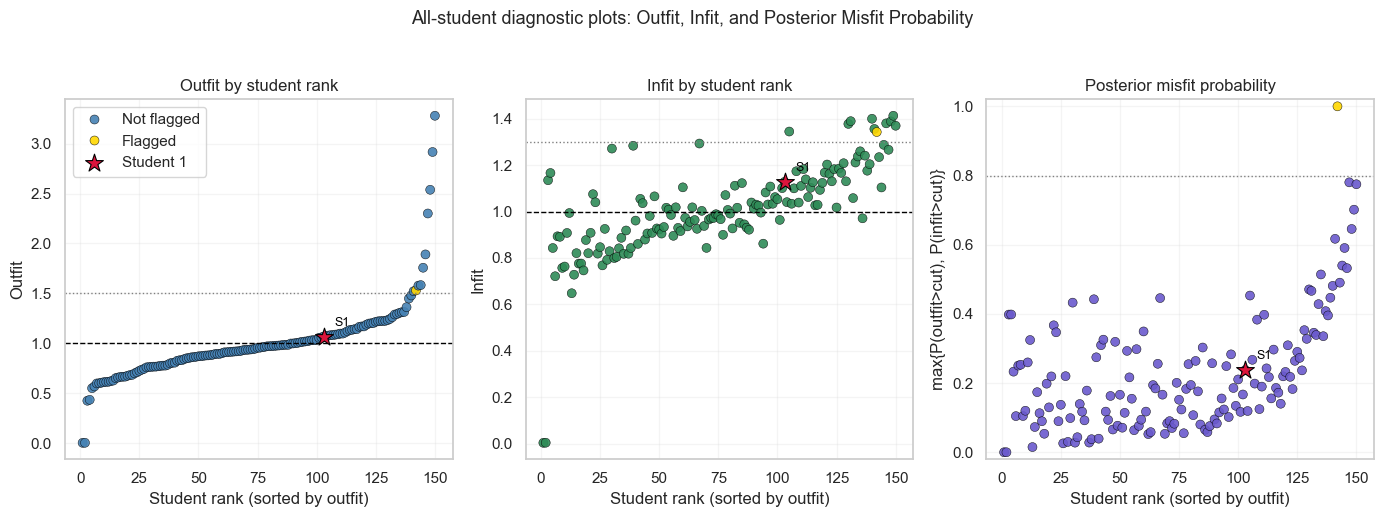

In [26]:
# Additional visuals: outfit, infit, posterior misfit probability, and Student 1 marker.
# This cell assumes the previous detection cell has already created diagnostic_df and related variables.

if 'diagnostic_df' not in globals():
    raise RuntimeError('Run the previous detection cell first to create diagnostic_df.')

plot_df2 = diagnostic_df.copy()
plot_df2['posterior_misfit_prob'] = np.maximum(
    plot_df2['prob_outfit_gt_cut'].to_numpy(),
    plot_df2['prob_infit_gt_cut'].to_numpy()
)
plot_df2['flag_label'] = np.where(plot_df2['flag_easy_item_misfit'], 'Flagged', 'Not flagged')

# Sort once by outfit rank for consistent student ordering across the three panels.
plot_df2 = plot_df2.sort_values('outfit_point').reset_index(drop=True)
plot_df2['rank'] = np.arange(1, len(plot_df2) + 1)

# Locate Student 1 for explicit marker display.
student_1_row = plot_df2.loc[plot_df2['student_id'] == 1].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True)

sns.scatterplot(
    data=plot_df2,
    x='rank',
    y='outfit_point',
    hue='flag_label',
    palette={'Not flagged': 'steelblue', 'Flagged': 'gold'},
    edgecolor='black',
    linewidth=0.35,
    s=42,
    alpha=0.9,
    ax=axes[0]
 )
axes[0].scatter(
    student_1_row['rank'],
    student_1_row['outfit_point'],
    s=180,
    marker='*',
    color='crimson',
    edgecolor='black',
    linewidth=0.8,
    zorder=6,
    label='Student 1'
 )
axes[0].annotate(
    'S1',
    (student_1_row['rank'], student_1_row['outfit_point']),
    textcoords='offset points',
    xytext=(8, 8),
    fontsize=9,
    color='black'
 )
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.0)
axes[0].axhline(outfit_cut, color='gray', linestyle=':', linewidth=1.0)
axes[0].set_title('Outfit by student rank')
axes[0].set_xlabel('Student rank (sorted by outfit)')
axes[0].set_ylabel('Outfit')
axes[0].grid(alpha=0.2)
axes[0].legend(loc='upper left')

sns.scatterplot(
    data=plot_df2,
    x='rank',
    y='infit_point',
    hue='flag_label',
    palette={'Not flagged': 'seagreen', 'Flagged': 'gold'},
    edgecolor='black',
    linewidth=0.35,
    s=42,
    alpha=0.9,
    ax=axes[1]
 )
axes[1].scatter(
    student_1_row['rank'],
    student_1_row['infit_point'],
    s=180,
    marker='*',
    color='crimson',
    edgecolor='black',
    linewidth=0.8,
    zorder=6
 )
axes[1].annotate(
    'S1',
    (student_1_row['rank'], student_1_row['infit_point']),
    textcoords='offset points',
    xytext=(8, 8),
    fontsize=9,
    color='black'
 )
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.0)
axes[1].axhline(infit_cut, color='gray', linestyle=':', linewidth=1.0)
axes[1].set_title('Infit by student rank')
axes[1].set_xlabel('Student rank (sorted by outfit)')
axes[1].set_ylabel('Infit')
axes[1].grid(alpha=0.2)
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

sns.scatterplot(
    data=plot_df2,
    x='rank',
    y='posterior_misfit_prob',
    hue='flag_label',
    palette={'Not flagged': 'slateblue', 'Flagged': 'gold'},
    edgecolor='black',
    linewidth=0.35,
    s=42,
    alpha=0.9,
    ax=axes[2]
 )
axes[2].scatter(
    student_1_row['rank'],
    student_1_row['posterior_misfit_prob'],
    s=180,
    marker='*',
    color='crimson',
    edgecolor='black',
    linewidth=0.8,
    zorder=6
 )
axes[2].annotate(
    'S1',
    (student_1_row['rank'], student_1_row['posterior_misfit_prob']),
    textcoords='offset points',
    xytext=(8, 8),
    fontsize=9,
    color='black'
 )
axes[2].axhline(posterior_prob_threshold, color='gray', linestyle=':', linewidth=1.0)
axes[2].set_ylim(-0.02, 1.02)
axes[2].set_title('Posterior misfit probability')
axes[2].set_xlabel('Student rank (sorted by outfit)')
axes[2].set_ylabel('max{P(outfit>cut), P(infit>cut)}')
axes[2].grid(alpha=0.2)
if axes[2].legend_ is not None:
    axes[2].legend_.remove()

fig.suptitle('All-student diagnostic plots: Outfit, Infit, and Posterior Misfit Probability', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

### Student 1의 경우: $b_i < \theta_1$ 문항에서 오답 6개가 있어도 적합도 지표가 정상 범위인 이유

Student 1의 사후평균 능력은 $\theta_1 = 0.423779$이고, 조건 $b_i < \theta_1$를 만족하는 문항 중 오답인 문항은 다음과 같습니다.
- 문항 2
- 문항 4
- 문항 5
- 문항 8
- 문항 10
- 문항 11

겉보기에는 이상해 보일 수 있지만, 적합도 지표는 다음처럼 허용 가능한 범위에 있습니다.
- Outfit = 1.066552
- Infit = 1.127937
- $P(\text{Outfit} > 1.50) = 0.104500$
- $P(\text{Infit} > 1.30) = 0.237750$
- Posterior misfit probability $= \max\{P(\text{Outfit}>1.50), P(\text{Infit}>1.30)\} = 0.237750$

정상 범위로 해석할 수 있는 이유는 다음과 같습니다.

1. $b_i < \theta_1$ 조건 자체가 넓습니다.

이 조건에는 "매우 쉬운" 문항뿐 아니라 "조금 쉬운" 문항도 포함됩니다. 따라서 오답이 일부 있어도 바로 심각한 이상반응으로 보기는 어렵습니다.

2. 더 엄격한 쉬운 문항 기준에서는 Student 1의 오답이 없습니다.

이 노트북의 기준($p_{1i} \ge 0.80$)으로 보면 Student 1의 쉬운 문항 오답 수는 0개입니다. 즉, 가장 전형적인 "쉬운 문항에서의 비정상 오답" 패턴은 나타나지 않습니다.

3. Infit/Outfit은 단순 오답 개수가 아니라 표준화 잔차 크기를 집계합니다.

문항별로
$$
z_{1i} = \frac{y_{1i} - p_{1i}}{\sqrt{p_{1i}(1-p_{1i})}}
$$
를 계산하고, 적합도는 $z_{1i}^2$를 합산/평균한 값으로 결정됩니다.

따라서 오답이 몇 개 있더라도, 해당 문항의 예측확률과 잔차 크기가 극단적이지 않으면 전체 적합도는 크게 벗어나지 않을 수 있습니다.

4. Posterior 기준에서 심한 misfit 근거가 약합니다.

두 posterior 초과확률이 의사결정 임계값보다 충분히 낮아, Student 1을 강한 misfit 사례로 분류할 근거가 부족합니다.

### Why Student 1 Can Have 6 Wrong Responses on Items with $b_i < \theta_1$ While Fit Indices Stay in Range

For Student 1, using posterior mean ability $\theta_1 = 0.423779$, the items with wrong responses among those satisfying $b_i < \theta_1$ are:
- Item 2
- Item 4
- Item 5
- Item 8
- Item 10
- Item 11

At first glance, this may look surprising, but the fit statistics remain in an acceptable range:
- Outfit = 1.066552
- Infit = 1.127937
- $P(\text{Outfit} > 1.50) = 0.104500$
- $P(\text{Infit} > 1.30) = 0.237750$
- Posterior misfit probability $= \max\{P(\text{Outfit}>1.50), P(\text{Infit}>1.30)\} = 0.237750$

Why this is still reasonable:

1. The condition $b_i < \theta_1$ is broad.

It includes items that are only moderately easy (for example, with $p_{1i}$ only modestly above 0.5), not only very easy items.

2. Student 1 has no wrong responses on very easy items under the stricter criterion.

With the threshold used in this notebook ($p_{1i} \ge 0.80$), Student 1 has 0 wrong responses. So the strongest "unexpected easy-item error" pattern is not present.

3. Infit and outfit depend on standardized residual size, not just error counts.

For each item,
$$
z_{1i} = \frac{y_{1i} - p_{1i}}{\sqrt{p_{1i}(1-p_{1i})}}
$$
and fit indices aggregate $z_{1i}^2$.

So, several wrong answers can occur without extreme misfit if those items are not in the very-high-probability region or if residual magnitudes are not unusually large.

4. Posterior evidence of severe misfit is low.

Both posterior exceedance probabilities are well below the decision thresholds, so the data do not strongly support labeling Student 1 as a severe misfit case.

---
### 학생 1 정보 곡선의 이론적·실천적 해석 (i = 문항 index, j = 학생 index)

본 도표는 모집단 수준의 검사정보곡선(Test Information Curve, TIC) 자체가 아니라, **특정 학생(학생 1)** 에 대해 평가된 **문항정보 프로파일(item-information profile)** 이다. 즉, 학생 1의 사후평균 능력(posterior mean ability) $\theta_j$를 기준으로 각 문항 $i$가 제공하는 정보량을 시각화한 것이다.

Rasch 모형(Rasch model)에서 문항 난이도(item difficulty) $b_i$가 알려져 있을 때, 학생 $j$의 정답확률(correct-response probability)은

$$
p(\theta_j,b_i)=\operatorname{logit}^{-1}(\theta_j-b_i)
$$

로 주어진다. 이때 베르누이 문항(Bernoulli item)의 피셔 정보(Fisher information)는

$$
I(\theta_j,b_i)=p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr)
$$

이다. 해당 함수는 다음 성질을 갖는다.

- $p(\theta_j,b_i)=0.5$일 때 최대가 된다.
- $p(\theta_j,b_i)$가 $0$ 또는 $1$에 가까워질수록 정보량은 감소한다.
- 따라서 $b_i$가 $\theta_j$에 근접할수록(문항-능력 정합, item-targeting) 측정정보가 커진다.

Rasch 모형에서 $p(\theta_j,b_i)=0.5$의 조건은 $\theta_j=b_i$이므로, 학생 1의 능력 수직선(vertical reference line) 근방에 위치한 문항들이 능력 추정에 핵심적으로 기여한다. 반대로 지나치게 쉬운 문항(too easy) 또는 지나치게 어려운 문항(too hard)은 응답이 거의 결정적이어서(near-deterministic) 능력 위치 식별(ability localization)에 덜 기여한다.

학생 1의 총정보(test information for one student)는 문항정보의 합으로 다음과 같이 정의된다.

$$
I(\theta_j)=\sum_{i=1}^{K} I(\theta_j,b_i)=\sum_{i=1}^{K} p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr)
$$

추정 정밀도(precision)와 표준오차(standard error) 사이에는

$$
\operatorname{SE}(\hat\theta_j)\approx\frac{1}{\sqrt{I(\theta_j)}}
$$

의 근사적 역관계가 성립한다. 따라서 총정보가 클수록 사후분포(posterior distribution)는 더 집중되고, 구간추정(credible interval)은 좁아진다.

실무적 해석(practical interpretation)으로는 다음이 중요하다.

1. 어떤 문항이 학생 1 측정의 중심을 이루는가
   능력 수직선 부근의 문항이 주된 기여 문항(core informative items)이다.
2. 검사 타기팅(targeting)의 적절성
   정보가 높은 문항이 능력 근처에 밀집할수록 해당 학생에 대한 측정 효율이 높다.
3. 왜 신용구간(credible interval) 폭이 달라지는가
   총정보가 크면 폭이 줄고, 총정보가 작으면 폭이 증가한다.
4. 적합도 해석에서 무엇이 중요한가
   Infit은 정보가중(information-weighted)이므로 능력 근처 문항의 영향이 상대적으로 크다.

---

### 검사정보곡선(TIC)의 이론적 측면과 실무 활용

검사정보곡선(Test Information Curve, TIC)은 능력수준 $\theta$에서 검사가 제공하는 총 정보량을 나타내며,

$$
I_{test}(\theta)=\sum_{i=1}^{K} I(\theta,b_i)
$$

로 정의된다.

이론적 측면(theoretical aspect)

- **국소 식별성(local identifiability)**: TIC가 큰 구간에서는 능력의 미세한 차이를 더 안정적으로 구분할 수 있다.
- **정밀도-정보 대응(precision-information duality)**: 일반적으로 $\mathrm{SE}(\theta)\approx1/\sqrt{I_{test}(\theta)}$ 관계가 성립한다.
- **검사-집단 정합(population targeting alignment)**: 피험자 능력분포와 TIC 고정보 구간이 일치할수록 검사 효율이 향상된다.

실무 활용(practical usage)

1. 검사 설계(test design) 및 문항선정(item selection)
   목표 능력대역에서 TIC가 충분히 높도록 난이도 분포를 설계한다.
2. 컴퓨터 적응검사(CAT, Computerized Adaptive Testing)
   현재 능력 추정치에서 정보가 큰 문항을 순차 제시하여 문항 수를 줄이고 정밀도를 확보한다.
3. 검사형 동등화(test equating)와 폼 구성(form assembly)
   복수 검사형의 TIC 형태를 유사하게 맞추어 측정 동질성을 유지한다.
4. 준거점 판정(cut-score decision)
   합격선 인근에서 TIC가 충분한지 검토하여 분류오차(classification error)를 줄인다.
5. 문항은행 관리(item bank management)
   저정보 구간(low-information region)을 진단해 신규 문항 개발 우선순위를 설정한다.

요약하면, TIC는 단순 시각화가 아니라 **측정 정밀도(precision), 타기팅(targeting), 판정 신뢰성(decision reliability)** 을 동시에 관리하는 핵심 지표이다.

### Theoretical and Practical Meaning for Student 1 (i = item, j = student)

This plot is not the population-level Test Information Curve (TIC). It is an item-information profile for one student, evaluated at Student 1's posterior mean ability. In the Rasch model, with known item difficulty $b_i$ and student ability $\theta_j$, the response probability is

$$
p(\theta_j,b_i)=\operatorname{logit}^{-1}(\theta_j-b_i).
$$

For a Bernoulli Rasch item, Fisher information from item $i$ about student ability $\theta_j$ is

$$
I(\theta_j,b_i)=p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr).
$$

Key properties:

- Information is largest when $p(\theta_j,b_i)=0.5$.
- Information decreases as $p(\theta_j,b_i)$ approaches $0$ or $1$.
- Therefore, information is largest when $b_i$ is close to $\theta_j$.

Since

$$
p(\theta_j,b_i)=\operatorname{logit}^{-1}(\theta_j-b_i),
$$

$p(\theta_j,b_i)=0.5$ occurs at

$$
\theta_j=b_i.
$$

So items near the student's ability provide the most measurement information, while very easy or very hard items contribute less.

Practical interpretation:

1. Which items carry most of Student 1 measurement?
   Items near the vertical ability line contribute most.
2. Is the test targeted to Student 1?
   Better targeting means more informative items near that line.
3. Why are intervals wide or narrow?
   Total information for Student 1 is
   $$
   I(\theta_j)=\sum_{i=1}^{K}I(\theta_j,b_i)=\sum_{i=1}^{K}p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr).
   $$
   More information usually means a narrower posterior interval.
4. Which items matter most for fit?
   Infit is information-weighted, so items near the student's level matter most.

A standard approximation is

$$
\operatorname{SE}(\hat\theta_j)\approx\frac{1}{\sqrt{I(\theta_j)}}.
$$

So precision is higher when the student is surrounded by well-targeted items.

---

### Test Information Curve (TIC): Theory and Practical Usage

The test information curve in IRT is

$$
I_{test}(\theta)=\sum_{i=1}^{K}I(\theta,b_i),
$$

the sum of item information across items.

Theoretical implications:

- Larger TIC means finer discrimination at that ability region.
- Precision is inversely related to standard error, approximately $SE(\theta)\approx 1/\sqrt{I_{test}(\theta)}$.
- Better alignment between TIC peaks and the target population improves efficiency.

Practical usage:

1. Test design and item selection
   Place item difficulties to raise TIC in target ability ranges.
2. CAT operation
   Select items with high information at current ability estimates.
3. Form assembly and equating
   Match TIC shapes across forms for comparable precision.
4. Cut-score decisions
   Ensure high information near decision thresholds.
5. Quality control
   Identify low-information regions and strengthen the item bank.

In short, TIC is a core diagnostic for both measurement precision and test design quality.

### Theoretical and Practical Meaning of the Information Curve for Student 1

The plotted curve is not a population-level test information curve. It is the **item-information profile for one student**, evaluated at Student 1's posterior mean ability. In the Rasch model, when the item difficulty $b_i$ is known and the student ability is $\theta_j$, the probability of a correct response is

$$
p(\theta_j,b_i) = \operatorname{logit}^{-1}(\theta_j - b_i).
$$

For a Bernoulli Rasch item, the Fisher information contributed by item $i$ about $\theta_j$ is

$$
I(\theta_j,b_i) = p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr).
$$

This quantity has a very important shape property:

- it is largest when $p(\theta_j,b_i) = 0.5$
- it becomes smaller as $p(\theta_j,b_i)$ moves toward $0$ or $1$
- therefore it is largest when the item difficulty is close to the student's ability

Since in the Rasch model

$$
p(\theta_j,b_i) = \operatorname{logit}^{-1}(\theta_j - b_i),
$$

the condition $p(\theta_j,b_i) = 0.5$ occurs when

$$
\theta_j = b_i.
$$

That is why the vertical line for Student 1's posterior mean ability is useful. Items whose difficulty lies near that vertical line are the items that are most informative for this student. Items far to the left of the line are too easy, and items far to the right are too hard. In both cases, the response probability is closer to 1 or 0, so the item contributes less information about the student's exact location on the latent scale.

Another way to say this is that information is highest where the response is most uncertain under the model. If the model thinks the student will almost certainly answer correctly or almost certainly answer incorrectly, that item does little to refine the estimate of the student's ability. But if the model thinks the item is near the student's level, then the response is most diagnostic, and the information is higher.

Practically, this figure helps answer several questions.

1. **Which items are carrying most of the measurement for Student 1?**
   The labeled points near the vertical line are the most important items for estimating Student 1's ability.

2. **Is the test well targeted to Student 1?**
   If many items cluster near the vertical line and have relatively large information values, then the test is reasonably targeted to Student 1. If most items are far away from the line, then Student 1 is being measured by items that are mostly too easy or too hard, which leads to lower precision.

3. **Why is the credible interval wide or narrow?**
   The total information available for Student 1 is the sum of the itemwise contributions,
   $$
   I(\theta_j) = \sum_{i=1}^K I(\theta_j,b_i) = \sum_{i=1}^K p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr).
   $$
   When that total is larger, the posterior for $\theta_j$ is typically more concentrated. When it is smaller, the posterior is wider.

4. **Which items matter most for fit diagnostics?**
   Infit is information-weighted, so items near the student's ability level matter more for infit than very easy or very hard items. This figure therefore also shows which items are central for Student 1's measurement and hence most relevant for central-fit interpretation.

There is also an important theoretical connection to standard errors. In likelihood-based and approximately Bayesian local-curvature terms, uncertainty is inversely related to information. Roughly speaking,

$$
\operatorname{SE}(\hat\theta_j) \approx \frac{1}{\sqrt{I(\theta_j)}}.
$$

So the information curve provides a geometric explanation for why estimation precision changes from student to student: precision is higher when the student is surrounded by well-targeted items and lower when the student's ability lies away from the center of the item-difficulty distribution.

In this notebook, the main practical interpretation is:

- the vertical line marks Student 1's posterior mean ability
- the item labels show which specific items sit near that level
- the taller labeled points are the items contributing the most information
- the sum of these heights explains how precisely Student 1 can be estimated

So the figure is useful not only as a technical summary of Fisher information, but also as a diagnostic picture of **targeting**, **precision**, and **which items are doing the real measurement work for this particular student**.

### Interpreting the 96% Credible Interval for Student 1

The 96% credible interval for Student 1 is wide because the notebook is estimating one ability parameter from only 20 binary item responses. In the current run, Student 1 scores 13 out of 20, has a posterior mean of about 0.434, and has a 2% to 98% interval of about [-0.594, 1.528]. That interval has width 2.122. This is a middle-range score, so the likelihood is informative but not sharp.

The item-information summary makes the same point numerically. The total test information for Student 1 at the posterior mean is about 4.039. In a Rasch model, local uncertainty is approximately $1 / \sqrt{I(\theta)}$, so the local standard error is about $1 / \sqrt{4.039} \approx 0.50$. A central 96% interval is therefore expected to be roughly 4 standard errors wide, which is about 2.0 on the theta scale. That is consistent with the observed interval width.

This notebook also keeps one all-0 response pattern and one all-1 response pattern on purpose. Those two extreme patterns are retained in the Bayesian sampling step, where the weak prior regularizes the corresponding abilities, but they are excluded from the no-prior MLE step so the optimization remains well-posed.

The conclusion is direct: the interval is wide because the test is short and only moderately targeted, not because the sampler is malfunctioning. Narrower intervals would require more items, better targeting around the student's ability level, or a substantively stronger prior.

---
## Appendix
---

### 1. Fisher Information for $\theta_j$ and Why It Has This Form

For student $j$, the Rasch model with known item difficulties is
$$
P(Y_{ji}=1 \mid \theta_j, b_i) = p(\theta_j,b_i) = \operatorname{logit}^{-1}(\theta_j - b_i).
$$
Because the item responses are conditionally independent given $\theta_j$, the log-likelihood contribution for student $j$ is
$$
\ell_j(\theta_j) = \sum_{i=1}^K \left[ y_{ji}\log p(\theta_j,b_i) + (1-y_{ji})\log\bigl(1-p(\theta_j,b_i)\bigr) \right].
$$

Using the logistic derivative $\frac{d\, p(\theta_j,b_i)}{d\theta_j} = p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr)$, the score function becomes
$$
\frac{\partial \ell_j(\theta_j)}{\partial \theta_j} = \sum_{i=1}^K \left[y_{ji} - p(\theta_j,b_i)\right].
$$
Differentiating once more gives the curvature of the log-likelihood:
$$
\frac{\partial^2 \ell_j(\theta_j)}{\partial \theta_j^2} = -\sum_{i=1}^K p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr).
$$
Define item-level information as
$$
I(\theta_j,b_i)=p(\theta_j,b_i)\bigl(1-p(\theta_j,b_i)\bigr).
$$
Therefore the Fisher information for $\theta_j$ is
$$
I(\theta_j) = -\mathbb{E}\left[\frac{\partial^2 \ell_j(\theta_j)}{\partial \theta_j^2}\right] = \sum_{i=1}^K I(\theta_j,b_i).
$$

This form makes it explicit that information depends on both ability and item difficulty.

This form is intuitive in the Rasch model. Each item contributes most information when $p(\theta_j,b_i) \approx 0.5$, which happens when the item difficulty is close to the student's ability. In that case $I(\theta_j,b_i)$ is near its maximum value $0.25$. Items that are far too easy or far too hard have probabilities near 1 or 0, so they contribute much less information.

That also explains why many of the MLE confidence intervals in the notebook look similar in length. Every non-extreme student answers the same 20 items, and for many students the total information
$$
\sum_{i=1}^K I(\theta_j,b_i)
$$
falls in a fairly narrow range. Since the Wald standard error is approximately $1 / \sqrt{I(\hat\theta_j)}$, similar information values produce similar interval widths. The intervals become noticeably wider only for students whose estimated abilities are farther from the bulk of the item difficulties, because then more of their response probabilities move closer to 0 or 1 and the information drops. Extreme all-0 and all-1 patterns would be the clearest case of this, but those students are excluded from the no-prior MLE step precisely because the likelihood is not regular there.

### 2. What the MLE Confidence Intervals Mean

#### Can the MLE Confidence Intervals Be Used as Accuracy of Fit?

Not in the same sense as infit or outfit. The MLE confidence intervals here measure **estimation uncertainty** for the ability parameter, not **model fit**.

- A narrow CI means the likelihood is sharp and the ability estimate is statistically precise.
- A wide CI means the likelihood is flat and the estimate is imprecise.
- But a narrow CI does **not** guarantee that the Rasch model fits the person's responses well.
- Likewise, a person can have a wide CI simply because the test gives limited information, even if the Rasch model fits reasonably well.

So the CIs are better interpreted as an index of **precision** or **measurement uncertainty**, not as a direct index of fit quality. Fit quality is what infit, outfit, residual checks, and posterior predictive checks are designed to assess.

#### Why Is the Mean MLE CI Width About 2.2 in This Simulation?

The mean Wald interval width is about 2.2 because the test is short and each student's likelihood contains only 20 binary responses. In this notebook, the approximate standard error is
$$
\operatorname{SE}(\hat\theta_j) \approx \frac{1}{\sqrt{I(\hat\theta_j)}},
$$
where
$$
I(\hat\theta_j) = \sum_{i=1}^K I(\hat\theta_j,b_i), \qquad I(\hat\theta_j,b_i)=p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr).
$$

Each item contributes at most $0.25$ information, and that maximum occurs only when the item is well targeted to the student's ability. With only 20 items, the absolute upper bound on information is $20 \times 0.25 = 5$. In practice, the information is usually lower because not all items are centered exactly at each student's ability.

If a typical student has information around 3 to 4, then the standard error is roughly
$$
\frac{1}{\sqrt{3.5}} \approx 0.53.
$$
A 95% Wald interval has width about
$$
2 \times 1.96 \times 0.53 \approx 2.08,
$$
which is already close to the observed average. So a mean CI width near 2.2 is not surprising at all in this simulation. It mainly reflects limited test length and moderate targeting, not a failure of the optimizer.

The widths also look fairly similar across students because all non-extreme students answer the same 20 items, and many of them end up with information values in a similar range. The intervals widen more noticeably only when the estimated ability moves away from the cluster of item difficulties, since then more response probabilities approach 0 or 1 and contribute less information.

### 3. Rasch Fit Analysis: Fit, Misfit, Infit, and Outfit

In Rasch modeling, the word **fit** means how well the observed responses agree with the response pattern that the model expects after abilities and item difficulties have been estimated. If a student's or an item's responses are systematically more irregular than the Rasch model predicts, that is called **misfit**.

For an item $i$ and student $j$, once we have an estimate such as the MLE $\hat\theta_j$, the fitted Rasch probability is
$$
\hat p(\hat\theta_j,b_i) = \operatorname{logit}^{-1}(\hat\theta_j - b_i).
$$
A basic residual is then
$$
r(\hat\theta_j,b_i) = y_{ji} - \hat p(\hat\theta_j,b_i),
$$
with model-based variance
$$
V(\hat\theta_j,b_i) = \hat p(\hat\theta_j,b_i)\bigl(1-\hat p(\hat\theta_j,b_i)\bigr).
$$
These quantities are the building blocks for common Rasch fit statistics.

#### Misfit

A **misfit** means the residual behavior is larger or more systematic than the model would usually allow. For example, if a student with high estimated ability misses many easy items, or a low-ability student answers many hard items correctly, the response pattern can show misfit.

#### Outfit

**Outfit** is an outlier-sensitive fit statistic. Conceptually, it is based on an unweighted average of standardized squared residuals like
$$
\frac{r(\hat\theta_j,b_i)^2}{V(\hat\theta_j,b_i)}.
$$
Because it is unweighted, outfit is especially sensitive to unusual responses on items that are far from the student's estimated ability.

#### Infit

**Infit** is an information-weighted fit statistic. It uses the same residual idea, but gives more weight to responses on items that are targeted near the person's ability level, where the item carries more information. So infit is usually more sensitive to distortion in the central, most informative part of the response pattern.

A common interpretation is:
- values near 1 indicate fit close to Rasch expectations
- values noticeably greater than 1 indicate underfit or noise, meaning more unpredictability than expected
- values noticeably less than 1 indicate overfit, meaning responses are too predictable or overly deterministic relative to the model

#### Can Infit and Outfit Be Computed from the MLE Estimates?

Yes. That is logically correct. Once the MLE step produces $\hat\theta_j$ for each non-extreme student, those estimates define fitted probabilities $\hat p(\hat\theta_j,b_i)$. From those fitted probabilities, the residuals and their standardized versions can be computed directly, and then infit and outfit can be formed.

The important limitation is interpretive, not logical. If the ability estimate itself is unstable, then the fitted probabilities are also uncertain, so the resulting fit statistics should be interpreted with care. In this notebook that issue is reduced by excluding the all-0 and all-1 response patterns from the no-prior MLE step, because those extreme response vectors do not support stable finite MLEs under the pure Rasch likelihood.

So the short answer is: **yes, infit and outfit can be computed using the MLE estimates, and that is a standard Rasch-modeling workflow.** They are diagnostics of response-pattern consistency with the fitted model, whereas the Wald confidence intervals from the MLE are diagnostics of parameter precision.

### 4. Person-Fit Diagnostics from the MLE Estimates

The next cells compute person-level residual summaries, infit, and outfit using the non-extreme students from the MLE step. Because this is a simulation notebook, the cells also compare the MLE estimates with the known true abilities and flag estimates that look unexpected based on a combination of large estimation error, Wald confidence-interval failure, and unusual fit statistics.

### How to Read the Person-Fit Plots

These three panels summarize different ways a student's observed response pattern can disagree with the Rasch model fitted by the MLE ability estimate.

- `RMS residual`: overall size of the raw person-level residuals. Larger values mean the student's responses are farther from the model-implied probabilities on average.
- `Infit mean square`: information-weighted misfit. Values near `1.0` indicate typical fit. Values above `1.0` indicate more variation than the model expects on items targeted to that student's estimated ability, while values below `1.0` indicate an unusually predictable response pattern.
- `Outfit mean square`: outlier-sensitive misfit. Values above `1.0` indicate unexpected responses on items far from the student's estimated ability, and values below `1.0` indicate less variability than expected.

In this notebook, the highlighted labels mark only the more serious cases. The residual panel emphasizes students with large estimation problems or unusually large residual size, while the infit and outfit panels label the strongest person-fit departures together with the misfit type and its value. Because the item difficulties are assumed to be truly known here, these plots should be interpreted as person-side fit diagnostics rather than uncertainty about the item parameters.

### Mathematical Definitions Behind RMS Residual, Infit, and Outfit

For student $j$ and item $i$, let

$$
p(\hat\theta_j,b_i) = \Pr(Y_{ji}=1 \mid \hat\theta_j, b_i) = \operatorname{logit}^{-1}(\hat\theta_j - b_i),
\qquad
r(\hat\theta_j,b_i) = Y_{ji} - p(\hat\theta_j,b_i).
$$

The code first computes the raw residual $r(\hat\theta_j,b_i)$ and its model-based variance

$$
\mathrm{Var}(Y_{ji} \mid \hat\theta_j, b_i) = p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr).
$$

The person-level RMS residual shown in the first panel is

$$
\mathrm{RMS}_i = \sqrt{\frac{1}{K} \sum_{i=1}^K r(\hat\theta_j,b_i)^2}.
$$

This is a direct summary of the average raw discrepancy between the observed responses and the fitted Rasch probabilities.

The standardized residual for one response is

$$
z(\hat\theta_j,b_i) = \frac{Y_{ji} - p(\hat\theta_j,b_i)}{\sqrt{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}}.
$$

Using these standardized residuals, the outfit mean square is

$$
\mathrm{Outfit}_j = \frac{1}{K} \sum_{i=1}^K z(\hat\theta_j,b_i)^2

= \frac{1}{K} \sum_{i=1}^K \frac{\bigl(Y_{ji}-p(\hat\theta_j,b_i)\bigr)^2}{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}.
$$

The infit mean square uses the item variances as weights, so items with more information for that student get more influence:

$$
\mathrm{Infit}_j = \frac{\sum_{i=1}^K p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr) z(\hat\theta_j,b_i)^2}{\sum_{i=1}^K p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}
= \frac{\sum_{i=1}^K \bigl(Y_{ji}-p(\hat\theta_j,b_i)\bigr)^2}{\sum_{i=1}^K p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}.
$$

Infit and outfit are expected to be near $1$ under typical fit because, under the fitted Rasch model, each standardized residual has approximately

$$
\mathbb{E}\left[z(\hat\theta_j,b_i)^2\right] \approx 1.
$$

Note that $\mathbb{E}\left[z(\hat\theta_j,b_i)^2\right]$ is the variance of the standardized residual and must be $1$ in the ideal situation since it is standardized, and $\mathbb{E}[z(\hat\theta_j,b_i)]=0$.

So both infit and outfit are averages of squared standardized residuals, just with different weighting schemes. Values above $1$ indicate more variation than the model expects, while values below $1$ indicate less variation than expected.

These statistics are closely related to Pearson-type $X^2$ quantities. In fact, $K \times \mathrm{Outfit}_j$ is the person's Pearson $X^2$ statistic, and infit is a weighted Pearson-type mean square. They are also built from standardized residuals, but they are not the same thing as the standard error of $\hat\theta_j$. The standard error describes uncertainty in the ability estimate, while infit and outfit describe whether the response pattern itself looks unusually noisy or unusually predictable relative to the model. Some Rasch software also reports transformed versions such as infit or outfit $Z$-standardized statistics, which are monotone transformations of these mean squares rather than new residual definitions.

In [27]:
# Compute person-level residual summaries and define stricter major-case flags from the non-extreme MLE estimates.
student_ids_non_extreme = np.where(non_extreme_mask)[0] + 1
theta_true_non_extreme = theta_true[non_extreme_mask]
theta_mle_non_extreme = theta_mle[non_extreme_mask]
y_non_extreme = y[non_extreme_mask]

p_mle_person = expit(theta_mle_non_extreme[:, None] - b_true[None, :])
var_mle_person = np.clip(p_mle_person * (1 - p_mle_person), 1e-9, None)
residual_mle_person = y_non_extreme - p_mle_person
standardized_sq_residual = (residual_mle_person ** 2) / var_mle_person

person_residual_rms = np.sqrt(np.mean(residual_mle_person ** 2, axis=1))
person_infit_mnsq = np.sum(residual_mle_person ** 2, axis=1) / np.sum(var_mle_person, axis=1)
person_outfit_mnsq = np.mean(standardized_sq_residual, axis=1)
person_abs_error = np.abs(theta_mle_non_extreme - theta_true_non_extreme)
person_ci_miss = (theta_true_non_extreme < theta_mle_ci_low[non_extreme_mask]) | (theta_true_non_extreme > theta_mle_ci_high[non_extreme_mask])

major_abs_error_threshold = 1.15
major_residual_threshold = 0.52
major_infit_low, major_infit_high = 0.75, 1.25
major_outfit_low, major_outfit_high = 0.55, 1.45
major_severity_threshold = 1.25

person_fit_df = pd.DataFrame({
    'student_id': student_ids_non_extreme,
    'theta_true': theta_true_non_extreme,
    'theta_mle': theta_mle_non_extreme,
    'abs_error': person_abs_error,
    'residual_rms': person_residual_rms,
    'infit_mnsq': person_infit_mnsq,
    'outfit_mnsq': person_outfit_mnsq,
    'mle_ci_low': theta_mle_ci_low[non_extreme_mask],
    'mle_ci_high': theta_mle_ci_high[non_extreme_mask],
    'ci_miss': person_ci_miss
})

person_fit_df['large_abs_error'] = person_fit_df['abs_error'] >= major_abs_error_threshold
person_fit_df['large_residual'] = person_fit_df['residual_rms'] >= major_residual_threshold
person_fit_df['infit_flag'] = (person_fit_df['infit_mnsq'] < major_infit_low) | (person_fit_df['infit_mnsq'] > major_infit_high)
person_fit_df['outfit_flag'] = (person_fit_df['outfit_mnsq'] < major_outfit_low) | (person_fit_df['outfit_mnsq'] > major_outfit_high)
person_fit_df['severity_score'] = (
    2.0 * person_fit_df['ci_miss'].astype(float)
    + np.clip((person_fit_df['abs_error'] - major_abs_error_threshold) / 0.20, 0, None)
    + np.clip((person_fit_df['residual_rms'] - major_residual_threshold) / 0.04, 0, None)
    + np.clip((major_infit_low - person_fit_df['infit_mnsq']) / 0.05, 0, None)
    + np.clip((person_fit_df['infit_mnsq'] - major_infit_high) / 0.05, 0, None)
    + np.clip((major_outfit_low - person_fit_df['outfit_mnsq']) / 0.10, 0, None)
    + np.clip((person_fit_df['outfit_mnsq'] - major_outfit_high) / 0.10, 0, None)
)
person_fit_df['major_case'] = person_fit_df['ci_miss'] | (person_fit_df['severity_score'] >= major_severity_threshold)

def summarize_major_case(row):
    labels = []
    if row['ci_miss']:
        labels.append('CI miss')
    if row['large_abs_error']:
        labels.append(f"|err|={row['abs_error']:.2f}")
    if row['large_residual']:
        labels.append(f"RMS={row['residual_rms']:.2f}")
    if row['infit_flag']:
        infit_type = 'high' if row['infit_mnsq'] > major_infit_high else 'low'
        labels.append(f"{infit_type} infit={row['infit_mnsq']:.2f}")
    if row['outfit_flag']:
        outfit_type = 'high' if row['outfit_mnsq'] > major_outfit_high else 'low'
        labels.append(f"{outfit_type} outfit={row['outfit_mnsq']:.2f}")
    return '; '.join(labels) if labels else 'within the expected range'

person_fit_df['major_reason'] = person_fit_df.apply(summarize_major_case, axis=1)
major_cases_df = person_fit_df[person_fit_df['major_case']].copy()
major_cases_df = major_cases_df.sort_values('severity_score', ascending=False).reset_index(drop=True)

display(person_fit_df.head())
print(f'Mean person residual RMS: {person_residual_rms.mean():.3f}')
print(f'Mean person infit MNSQ: {person_infit_mnsq.mean():.3f}')
print(f'Mean person outfit MNSQ: {person_outfit_mnsq.mean():.3f}')
print('Major-case thresholds: |error| >= 1.15, CI miss, RMS residual >= 0.52, infit outside [0.75, 1.25], outfit outside [0.55, 1.45], or severity score >= 1.25.')

,student_id,theta_true,theta_mle,abs_error,residual_rms,infit_mnsq,outfit_mnsq,mle_ci_low,mle_ci_high,ci_miss,large_abs_error,large_residual,infit_flag,outfit_flag,severity_score,major_case,major_reason
0,1,0.298893,0.399325,0.100433,0.477798,1.120601,1.060600,-0.571682,1.370333,False,False,False,False,False,0.0,False,within the expected range
1,2,0.078087,-0.070008,0.148095,0.452247,0.930457,0.982693,-1.004797,0.864781,False,False,False,False,False,0.0,False,within the expected range
2,3,-1.181751,-0.522098,0.659653,0.506737,1.167560,1.167881,-1.456638,0.412443,False,False,False,False,False,0.0,False,within the expected range
3,4,0.408469,0.160291,0.248178,0.442843,0.917297,0.979138,-0.787573,1.108155,False,False,False,False,False,0.0,False,within the expected range
4,5,-1.151830,-1.244496,0.092665,0.437233,1.006994,0.965496,-2.250365,-0.238626,False,False,False,False,False,0.0,False,within the expected range


Mean person residual RMS: 0.402
Mean person infit MNSQ: 0.980
Mean person outfit MNSQ: 0.966
Major-case thresholds: |error| >= 1.15, CI miss, RMS residual >= 0.52, infit outside [0.75, 1.25], outfit outside [0.55, 1.45], or severity score >= 1.25.


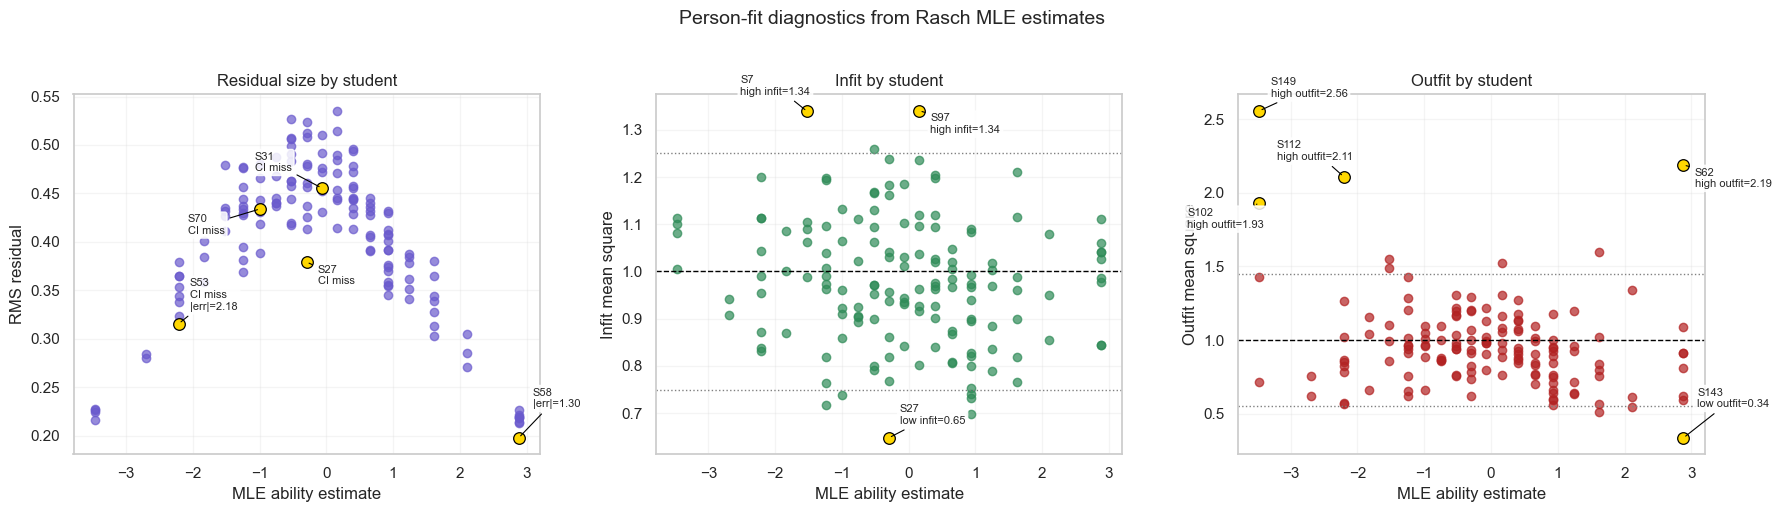

In [28]:
# Plot person-fit diagnostics and annotate the strongest major cases with misfit type and value.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

highlight_style = dict(s=70, facecolor='gold', edgecolor='black', linewidth=0.9, zorder=3)
annotation_offsets = [(8, 10), (8, -16), (-48, 12), (-52, -18), (10, 22)]

axes[0].scatter(theta_mle_non_extreme, person_residual_rms, alpha=0.70, color='slateblue')
residual_cases_df = major_cases_df[
    major_cases_df['ci_miss'] | major_cases_df['large_abs_error'] | major_cases_df['large_residual']
]
residual_cases_df = residual_cases_df.sort_values(
    ['ci_miss', 'abs_error', 'residual_rms'], ascending=[False, False, False]
).head(5)
axes[0].scatter(residual_cases_df['theta_mle'], residual_cases_df['residual_rms'], **highlight_style)
for idx, (_, row) in enumerate(residual_cases_df.iterrows()):
    residual_labels = []
    if row['ci_miss']:
        residual_labels.append('CI miss')
    if row['large_abs_error']:
        residual_labels.append(f"|err|={row['abs_error']:.2f}")
    if row['large_residual']:
        residual_labels.append(f"RMS={row['residual_rms']:.2f}")
    axes[0].annotate(
        f"S{int(row['student_id'])}\n" + '\n'.join(residual_labels[:2]),
        (row['theta_mle'], row['residual_rms']),
        textcoords='offset points',
        xytext=annotation_offsets[idx % len(annotation_offsets)],
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
        arrowprops=dict(arrowstyle='-', color='black', lw=0.8),
    )
axes[0].set_xlabel('MLE ability estimate')
axes[0].set_ylabel('RMS residual')
axes[0].set_title('Residual size by student')
axes[0].grid(alpha=0.2)

axes[1].scatter(theta_mle_non_extreme, person_infit_mnsq, alpha=0.70, color='seagreen')
infit_cases_df = major_cases_df[major_cases_df['infit_flag']]
infit_cases_df = infit_cases_df.reindex(
    infit_cases_df['infit_mnsq'].sub(1.0).abs().sort_values(ascending=False).index
).head(5)
axes[1].scatter(infit_cases_df['theta_mle'], infit_cases_df['infit_mnsq'], **highlight_style)
for idx, (_, row) in enumerate(infit_cases_df.iterrows()):
    infit_type = 'high' if row['infit_mnsq'] > major_infit_high else 'low'
    axes[1].annotate(
        f"S{int(row['student_id'])}\n{infit_type} infit={row['infit_mnsq']:.2f}",
        (row['theta_mle'], row['infit_mnsq']),
        textcoords='offset points',
        xytext=annotation_offsets[idx % len(annotation_offsets)],
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
        arrowprops=dict(arrowstyle='-', color='black', lw=0.8),
    )
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[1].axhline(major_infit_low, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(major_infit_high, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('MLE ability estimate')
axes[1].set_ylabel('Infit mean square')
axes[1].set_title('Infit by student')
axes[1].grid(alpha=0.2)

axes[2].scatter(theta_mle_non_extreme, person_outfit_mnsq, alpha=0.70, color='firebrick')
outfit_cases_df = major_cases_df[major_cases_df['outfit_flag']]
outfit_cases_df = outfit_cases_df.reindex(
    outfit_cases_df['outfit_mnsq'].sub(1.0).abs().sort_values(ascending=False).index
).head(5)
axes[2].scatter(outfit_cases_df['theta_mle'], outfit_cases_df['outfit_mnsq'], **highlight_style)
for idx, (_, row) in enumerate(outfit_cases_df.iterrows()):
    outfit_type = 'high' if row['outfit_mnsq'] > major_outfit_high else 'low'
    axes[2].annotate(
        f"S{int(row['student_id'])}\n{outfit_type} outfit={row['outfit_mnsq']:.2f}",
        (row['theta_mle'], row['outfit_mnsq']),
        textcoords='offset points',
        xytext=annotation_offsets[idx % len(annotation_offsets)],
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
        arrowprops=dict(arrowstyle='-', color='black', lw=0.8),
    )
axes[2].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[2].axhline(major_outfit_low, color='gray', linestyle=':', linewidth=1)
axes[2].axhline(major_outfit_high, color='gray', linestyle=':', linewidth=1)
axes[2].set_xlabel('MLE ability estimate')
axes[2].set_ylabel('Outfit mean square')
axes[2].set_title('Outfit by student')
axes[2].grid(alpha=0.2)

fig.suptitle('Person-fit diagnostics from Rasch MLE estimates', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

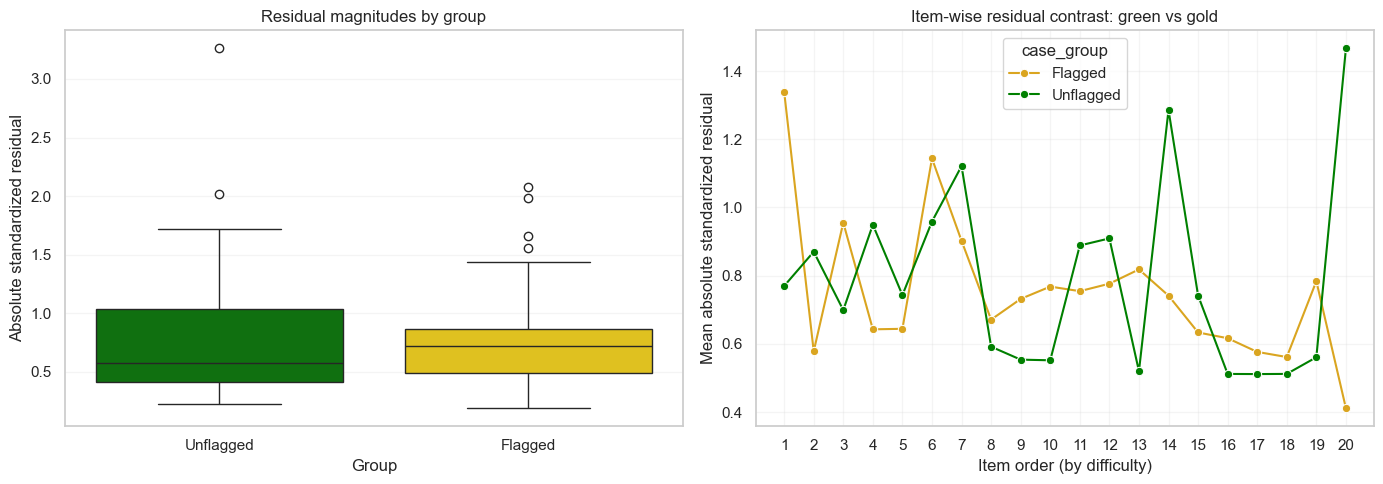

In [29]:
# Compare residual magnitudes for unflagged vs flagged groups in aggregate.
# Build required inputs locally so this cell can run even if later cells were not executed yet.
if 'student_position_map' not in globals():
    student_position_map = {int(student_id): idx for idx, student_id in enumerate(student_ids_non_extreme)}

if 'selected_students_df' not in globals():
    if 'major_plot_df' in globals() and len(major_plot_df) > 0:
        flagged_df = major_plot_df.copy()
    else:
        flagged_df = major_cases_df.copy()
        if len(flagged_df) > 0:
            flagged_df = flagged_df.sort_values(
                ['ci_miss', 'abs_error', 'residual_rms'], ascending=[False, False, False]
            ).head(3)

    flagged_ids = set(flagged_df['student_id'].astype(int).tolist()) if len(flagged_df) > 0 else set()
    normal_pool = person_fit_df.loc[~person_fit_df['student_id'].isin(flagged_ids)].copy()
    normal_pool = normal_pool.sort_values(['abs_error', 'residual_rms'])
    n_normal = max(1, len(flagged_df)) if len(normal_pool) > 0 else 0
    normal_case_df = normal_pool.head(n_normal)

    selected_students_df = pd.concat(
        [
            normal_case_df.assign(case_group='Unflagged'),
            flagged_df.assign(case_group='Flagged')
        ],
        ignore_index=True
    )

comparison_rows = []
for _, row in selected_students_df.iterrows():
    student_pos = student_position_map[int(row['student_id'])]
    expected_probabilities = expit(row['theta_mle'] - b_true)
    observed_responses = y_non_extreme[student_pos]
    raw_residual = observed_responses - expected_probabilities
    standardized_residual = raw_residual / np.sqrt(np.clip(expected_probabilities * (1 - expected_probabilities), 1e-9, None))
    for ordered_index, item_idx in enumerate(item_order):
        comparison_rows.append({
            'student_id': int(row['student_id']),
            'case_group': row['case_group'],
            'item_number': int(item_idx + 1),
            'item_order': int(ordered_index + 1),
            'abs_raw_residual': abs(raw_residual[item_idx]),
            'abs_standardized_residual': abs(standardized_residual[item_idx]),
        })

comparison_df = pd.DataFrame(comparison_rows)
item_group_summary = comparison_df.groupby(['case_group', 'item_order'], as_index=False)['abs_standardized_residual'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=comparison_df,
    x='case_group',
    y='abs_standardized_residual',
    hue='case_group',
    palette={'Unflagged': 'green', 'Flagged': 'gold'},
    dodge=False,
    ax=axes[0]
 )
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Absolute standardized residual')
axes[0].set_title('Residual magnitudes by group')
axes[0].grid(alpha=0.2, axis='y')
if axes[0].legend_ is not None:
    axes[0].legend_.remove()

sns.lineplot(
    data=item_group_summary,
    x='item_order',
    y='abs_standardized_residual',
    hue='case_group',
    palette={'Unflagged': 'green', 'Flagged': 'goldenrod'},
    marker='o',
    ax=axes[1]
 )
axes[1].set_xlabel('Item order (by difficulty)')
axes[1].set_xticks(np.arange(1, K + 1))
axes[1].set_ylabel('Mean absolute standardized residual')
axes[1].set_title('Item-wise residual contrast: green vs gold')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Why a Case Like Student 149 Can Be Flagged

A case like Student 149 is a standard example of **outfit-driven person misfit**. Suppose that for one item the fitted Rasch probability is very small, $p(\hat\theta_j,b_i) \approx 0$, but the observed response is $Y_{ji}=1$. Then the raw residual is

$$
r(\hat\theta_j,b_i) = Y_{ji} - p(\hat\theta_j,b_i) = 1 - p(\hat\theta_j,b_i),
$$

which is close to $1$. The corresponding standardized residual is

$$
z(\hat\theta_j,b_i) = \frac{Y_{ji} - p(\hat\theta_j,b_i)}{\sqrt{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}}.
$$

When $p(\hat\theta_j,b_i)$ is very small, the denominator $\sqrt{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}$ is also very small, so $z(\hat\theta_j,b_i)$ can become very large. That single large standardized residual can substantially increase the student's **outfit mean square**, because outfit is especially sensitive to unusual outlying responses on items that are far from the student's estimated ability level.

So the logic is: a very unlikely observed success on a very difficult item for a low-ability student, or a very unlikely observed failure on a very easy item for a high-ability student, creates a large standardized residual and can make the student flagged. This does **not** mean the response is impossible or incorrect. It means the response is unusually surprising under the fitted Rasch model, which is exactly what outfit is designed to detect.

### Residual, Standardized Residual, and Why This Is Called Outfit-Driven Misfit

It is useful to distinguish three related but different quantities.

For one student $j$ and one item $i$, the **raw residual** is

$$
r(\hat\theta_j,b_i) = Y_{ji} - p(\hat\theta_j,b_i).
$$

This is the basic item-level discrepancy between the observed response and the fitted Rasch probability.

The **standardized residual** rescales that discrepancy by the model-based Bernoulli standard deviation:

$$
z(\hat\theta_j,b_i) = \frac{Y_{ji} - p(\hat\theta_j,b_i)}{\sqrt{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}}.
$$

So the raw residual is the starting point, but the standardized residual tells us how large that discrepancy is relative to the variability that the model would normally expect at that probability level.

The **outfit mean square** is then a person-level summary of those squared standardized residuals:

$$
\mathrm{Outfit}_j = \frac{1}{K} \sum_{i=1}^K z(\hat\theta_j,b_i)^2.
$$

That is why a case can be described as **outfit-driven misfit** rather than just a residual. The unusual response first appears as a residual, but the student is flagged because that residual makes a large contribution to the student's overall outfit statistic.

This matters especially when $p(\hat\theta_j,b_i)$ is very close to $0$ or $1$. For example, if $p(\hat\theta_j,b_i)$ is very small but $Y_{ji}=1$, then the raw residual $r(\hat\theta_j,b_i)=1-p(\hat\theta_j,b_i)$ is large, and the standardized residual can become even larger because the denominator $\sqrt{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}$ is small. Such a response is therefore a classic source of large outfit.

By contrast, **infit** is a weighted version that gives more emphasis to items near the student's ability level:

$$
\mathrm{Infit}_j = \frac{\sum_{i=1}^K p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr) z(\hat\theta_j,b_i)^2}{\sum_{i=1}^K p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}.
$$

Because infit weights by $p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)$, very unlikely outlying responses on items far from the student's ability often affect outfit more strongly than infit. So in a case like Student 149, the correct interpretation is: the event is first an **item-level residual**, but the student is flagged because that event produces a large **person-level outfit contribution**.

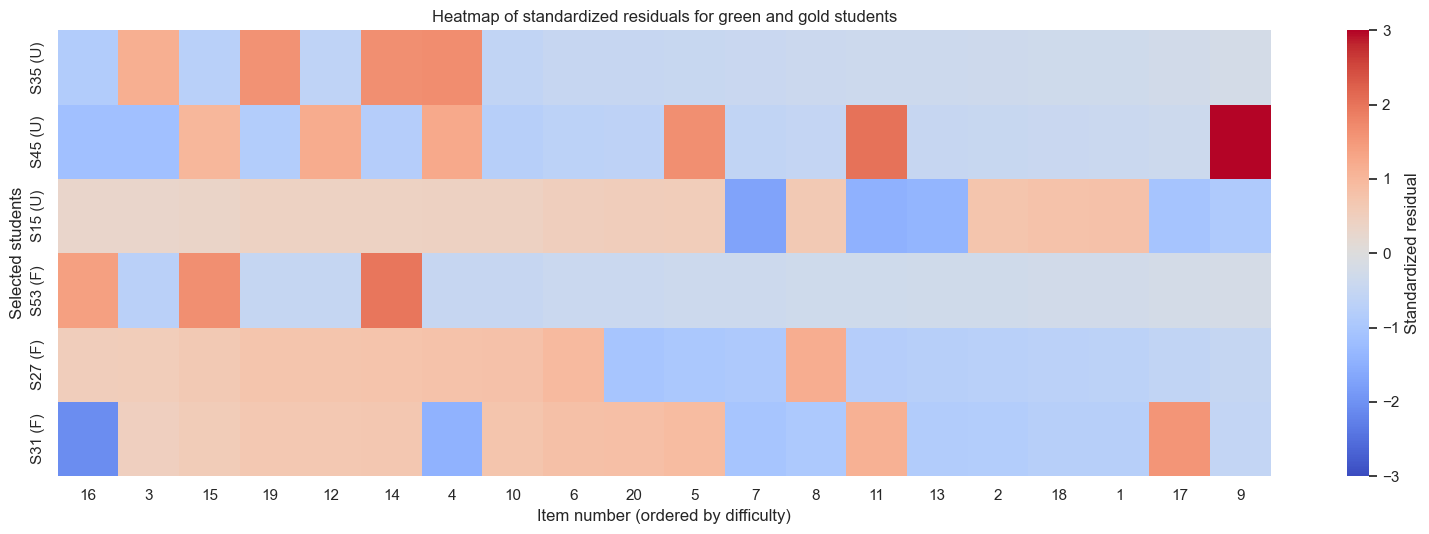

In [30]:
# Display a heatmap of standardized residuals for the same selected students and items.
if 'item_order' not in globals():
    item_order = np.argsort(b_true)
if 'ordered_item_numbers' not in globals():
    ordered_item_numbers = np.arange(1, K + 1)[item_order]

selected_standardized_residuals = []
selected_row_labels = []

for _, row in selected_students_df.iterrows():
    student_pos = student_position_map[int(row['student_id'])]
    expected_probabilities = expit(row['theta_mle'] - b_true)
    observed_responses = y_non_extreme[student_pos]
    standardized_residual = (observed_responses - expected_probabilities) / np.sqrt(np.clip(expected_probabilities * (1 - expected_probabilities), 1e-9, None))
    selected_standardized_residuals.append(standardized_residual[item_order])
    selected_row_labels.append(f"S{int(row['student_id'])} ({row['case_group'][0]})")

selected_standardized_residuals = np.asarray(selected_standardized_residuals)

plt.figure(figsize=(16, 5.5))
sns.heatmap(
    selected_standardized_residuals,
    cmap='coolwarm',
    center=0.0,
    vmin=-3,
    vmax=3,
    xticklabels=ordered_item_numbers,
    yticklabels=selected_row_labels,
    cbar_kws={'label': 'Standardized residual'}
)
plt.xlabel('Item number (ordered by difficulty)')
plt.ylabel('Selected students')
plt.title('Heatmap of standardized residuals for green and gold students')
plt.tight_layout()
plt.show()

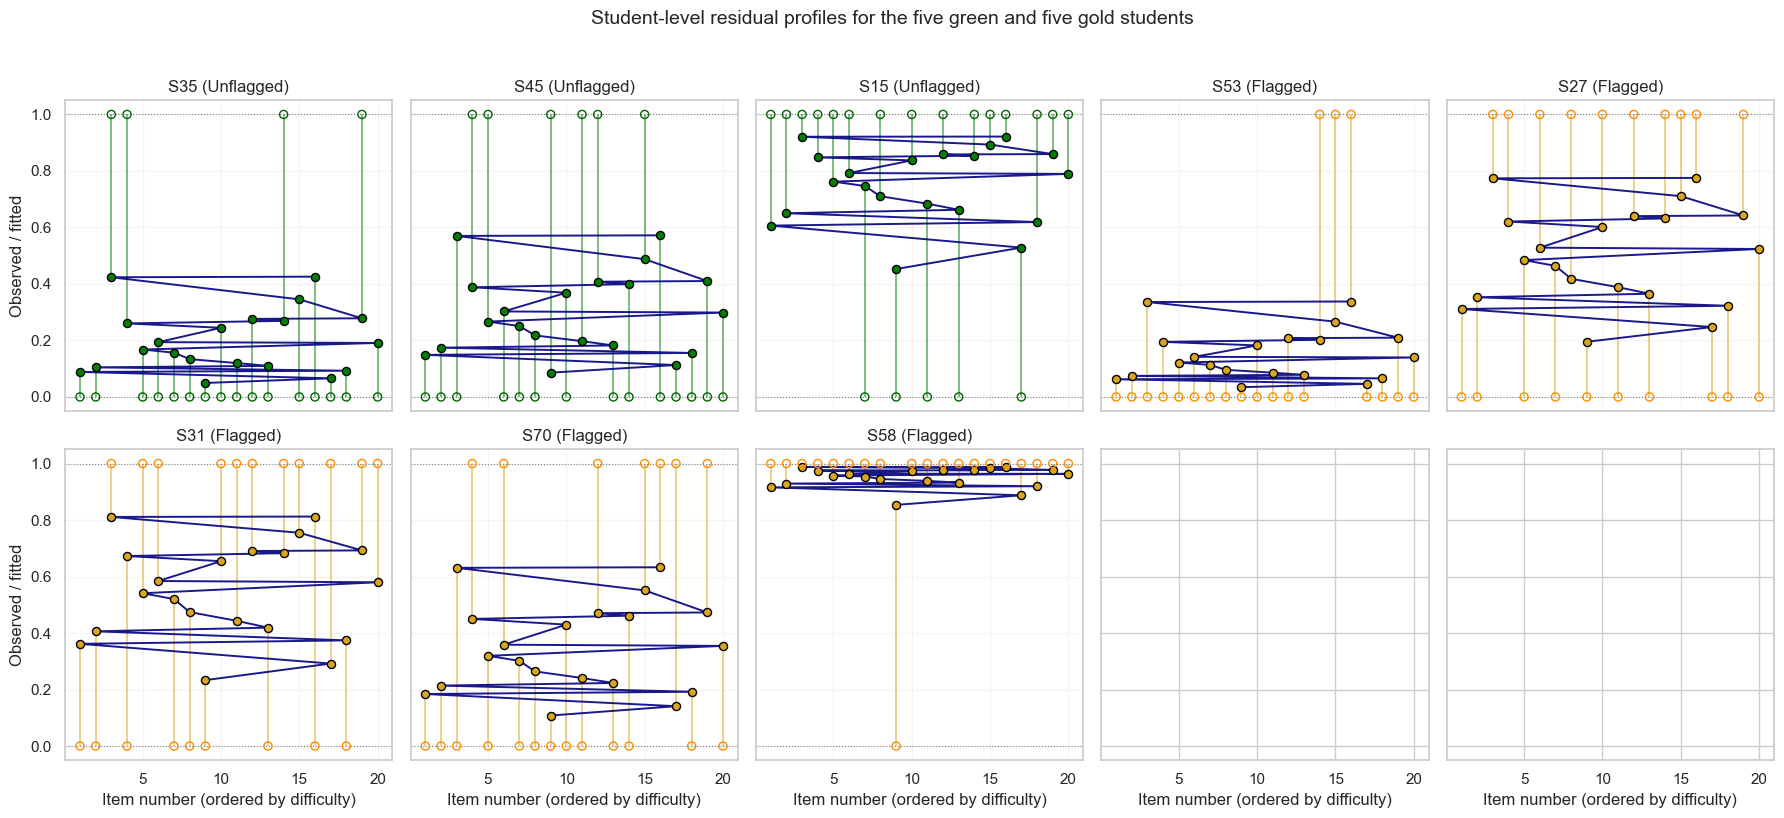

In [31]:
# Show one residual-profile panel per selected student so item-by-item departures are visible.
if 'student_position_map' not in globals():
    student_position_map = {int(student_id): idx for idx, student_id in enumerate(student_ids_non_extreme)}

if 'major_plot_df' in globals() and len(major_plot_df) > 0:
    flagged_df = major_plot_df.copy()
else:
    flagged_df = major_cases_df.copy()
    if len(flagged_df) > 0:
        flagged_df = flagged_df.sort_values(
            ['ci_miss', 'abs_error', 'residual_rms'], ascending=[False, False, False]
        ).head(5)

if 'normal_case_df' not in globals() or len(normal_case_df) == 0:
    flagged_ids = set(flagged_df['student_id'].astype(int).tolist()) if len(flagged_df) > 0 else set()
    normal_case_df = person_fit_df.loc[~person_fit_df['student_id'].isin(flagged_ids)].copy()
    normal_case_df = normal_case_df.sort_values(['abs_error', 'residual_rms']).head(max(1, len(flagged_df)))

selected_students_df = pd.concat([
    normal_case_df.assign(case_group='Unflagged'),
    flagged_df.assign(case_group='Flagged')
]).reset_index(drop=True)

item_order = np.argsort(b_true)
ordered_item_numbers = np.arange(1, K + 1)[item_order]
ordered_item_difficulties = b_true[item_order]

fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (_, row) in zip(axes, selected_students_df.iterrows()):
    student_pos = student_position_map[int(row['student_id'])]
    expected_probabilities = expit(row['theta_mle'] - b_true)[item_order]
    observed_responses = y_non_extreme[student_pos][item_order]
    panel_color = 'green' if row['case_group'] == 'Unflagged' else 'goldenrod'

    ax.vlines(
        ordered_item_numbers,
        expected_probabilities,
        observed_responses,
        color=panel_color,
        alpha=0.55,
        linewidth=1.3,
    )
    ax.plot(ordered_item_numbers, expected_probabilities, color='navy', linewidth=1.4, alpha=0.9)
    ax.scatter(ordered_item_numbers, expected_probabilities, color=panel_color, edgecolor='black', s=34, zorder=3)
    ax.scatter(
        ordered_item_numbers,
        observed_responses,
        facecolors='none',
        edgecolors=('darkgreen' if row['case_group'] == 'Unflagged' else 'darkorange'),
        s=34,
        linewidth=1.0,
        zorder=4,
    )
    ax.set_title(f"S{int(row['student_id'])} ({row['case_group']})")
    ax.grid(alpha=0.2)
    ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)

for ax in axes[5:]:
    ax.set_xlabel('Item number (ordered by difficulty)')
for ax in axes[::5]:
    ax.set_ylabel('Observed / fitted')

fig.suptitle('Student-level residual profiles for the five green and five gold students', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Three Clearer Diagnostics for Why the Gold Students Are Flagged

The next three figures reorganize the same person-fit information into views that are easier to interpret than the all-curves overlay.

- The first figure shows item-by-item fitted probabilities and observed responses for the five green students and five gold students, with items ordered by difficulty.
- The second figure shows a heatmap of standardized residuals for the same students and items.
- The third figure compares the residual magnitudes for the green and gold groups in aggregate.

In [32]:
# Display only the major person-fit cases so the table emphasizes the most problematic MLE estimates.
unexpected_mle_df = major_cases_df[[
    'student_id', 'theta_true', 'theta_mle', 'abs_error',
    'mle_ci_low', 'mle_ci_high', 'ci_miss',
    'residual_rms', 'infit_mnsq', 'outfit_mnsq',
    'severity_score', 'major_reason'
]].copy()

print(f'Number of major non-extreme cases: {len(unexpected_mle_df)}')
display(unexpected_mle_df)

Number of major non-extreme cases: 13


,student_id,theta_true,theta_mle,abs_error,mle_ci_low,mle_ci_high,ci_miss,residual_rms,infit_mnsq,outfit_mnsq,severity_score,major_reason
0,149,-2.744412,-3.468719,0.724307,-5.503921,-1.433517,False,0.227304,1.114157,2.556706,11.067064,high outfit=2.56
1,62,1.932728,2.882793,0.950065,0.845956,4.919630,False,0.226742,1.110434,2.188968,7.389682,high outfit=2.19
2,53,-0.031866,-2.207906,2.176041,-3.474444,-0.941369,True,0.315567,0.831645,0.566837,7.130203,CI miss; |err|=2.18
3,112,-2.384780,-2.207911,0.176869,-3.474451,-0.941371,False,0.378961,1.199347,2.110125,6.601248,high outfit=2.11
4,102,-2.769661,-3.468711,0.699050,-5.503906,-1.433516,False,0.225903,1.100463,1.931168,4.811679,high outfit=1.93
5,27,0.832984,-0.296057,1.129041,-1.226539,0.634426,True,0.379141,0.647940,0.620362,4.041204,CI miss; low infit=0.65
6,97,0.209309,0.160310,0.048999,-0.787556,1.108176,False,0.535278,1.340200,1.521292,2.898857,RMS=0.54; high infit=1.34; high outfit=1.52
7,58,1.582792,2.882789,1.299997,0.845956,4.919623,False,0.197637,0.843654,0.337081,2.879173,|err|=1.30; low outfit=0.34
8,7,-1.334632,-1.521237,0.186605,-2.580328,-0.462146,False,0.478836,1.338930,1.486788,2.146478,high infit=1.34; high outfit=1.49
9,143,3.081750,2.882784,0.198966,0.845955,4.919614,False,0.197637,0.843650,0.337080,2.129200,low outfit=0.34


### Itemwise Infit Contribution for the Largest-Infit Students

The next cell focuses on the three students with the largest **infit** values in the person-fit figure.

Here the displayed quantity is the **normalized itemwise infit contribution**

$$
\frac{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr) z(\hat\theta_j,b_i)^2}{\sum_i p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)},
$$

where

$$
z(\hat\theta_j,b_i) = \frac{Y_{ji} - p(\hat\theta_j,b_i)}{\sqrt{p(\hat\theta_j,b_i)\bigl(1-p(\hat\theta_j,b_i)\bigr)}}.
$$

This quantity is always nonnegative, and its sum over items equals the student's infit mean square. It shows which items contribute the most to a student's infit statistic. The first figure is a heatmap for the three largest-infit students. The second figure shows the same item-ordered contributions for those three students, together with two normal-fit students for comparison.

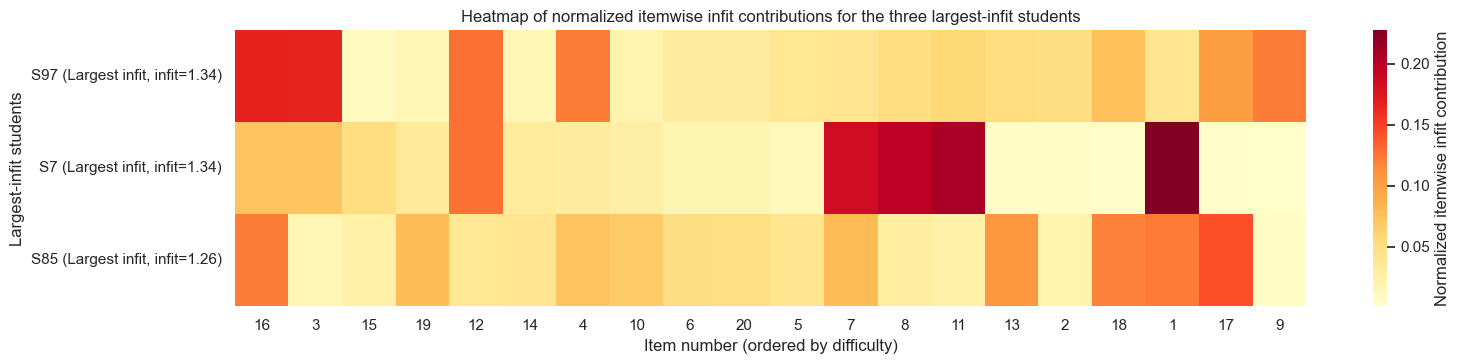

In [33]:
# Heatmap and item-order view of normalized itemwise infit contributions for the largest-infit students.
high_infit_focus_df = person_fit_df.sort_values(
    ['infit_mnsq', 'outfit_mnsq'], ascending=[False, False]
).head(3).copy()

comparison_pool_df = person_fit_df[
    ~person_fit_df['student_id'].isin(high_infit_focus_df['student_id'])
].copy()
comparison_pool_df['fit_distance'] = (
    comparison_pool_df['infit_mnsq'].sub(1.0).abs()
    + comparison_pool_df['outfit_mnsq'].sub(1.0).abs()
    + comparison_pool_df['residual_rms'].sub(comparison_pool_df['residual_rms'].median()).abs()
)
normal_compare_df = comparison_pool_df.sort_values('fit_distance').head(2).copy()

focus_students_df = pd.concat([
    high_infit_focus_df.assign(case_group='Largest infit'),
    normal_compare_df.assign(case_group='Normal fit')
], ignore_index=True)

item_order = np.argsort(b_true)
ordered_item_numbers = np.arange(1, K + 1)[item_order]


def compute_infit_contribution_profile(theta_value, responses):
    expected_probabilities = expit(theta_value - b_true)
    item_weights = np.clip(expected_probabilities * (1 - expected_probabilities), 1e-9, None)
    standardized_residual = (responses - expected_probabilities) / np.sqrt(item_weights)
    infit_contribution = (item_weights * standardized_residual**2) / item_weights.sum()
    return infit_contribution[item_order]


heatmap_profiles = []
heatmap_labels = []
comparison_profiles = []
comparison_labels = []
comparison_colors = []

for _, row in focus_students_df.iterrows():
    student_pos = student_position_map[int(row['student_id'])]
    contribution_profile = compute_infit_contribution_profile(
        row['theta_mle'],
        y_non_extreme[student_pos],
    )
    label = f"S{int(row['student_id'])} ({row['case_group']}, infit={row['infit_mnsq']:.2f})"

    comparison_profiles.append(contribution_profile)
    comparison_labels.append(label)
    comparison_colors.append('goldenrod' if row['case_group'] == 'Largest infit' else 'seagreen')

    if row['case_group'] == 'Largest infit':
        heatmap_profiles.append(contribution_profile)
        heatmap_labels.append(label)

heatmap_profiles = np.asarray(heatmap_profiles)
comparison_profiles = np.asarray(comparison_profiles)

plt.figure(figsize=(16, 3.8))
sns.heatmap(
    heatmap_profiles,
    cmap='YlOrRd',
    xticklabels=ordered_item_numbers,
    yticklabels=heatmap_labels,
    cbar_kws={'label': 'Normalized itemwise infit contribution'}
)
plt.xlabel('Item number (ordered by difficulty)')
plt.ylabel('Largest-infit students')
plt.title('Heatmap of normalized itemwise infit contributions for the three largest-infit students')
plt.tight_layout()
plt.show()

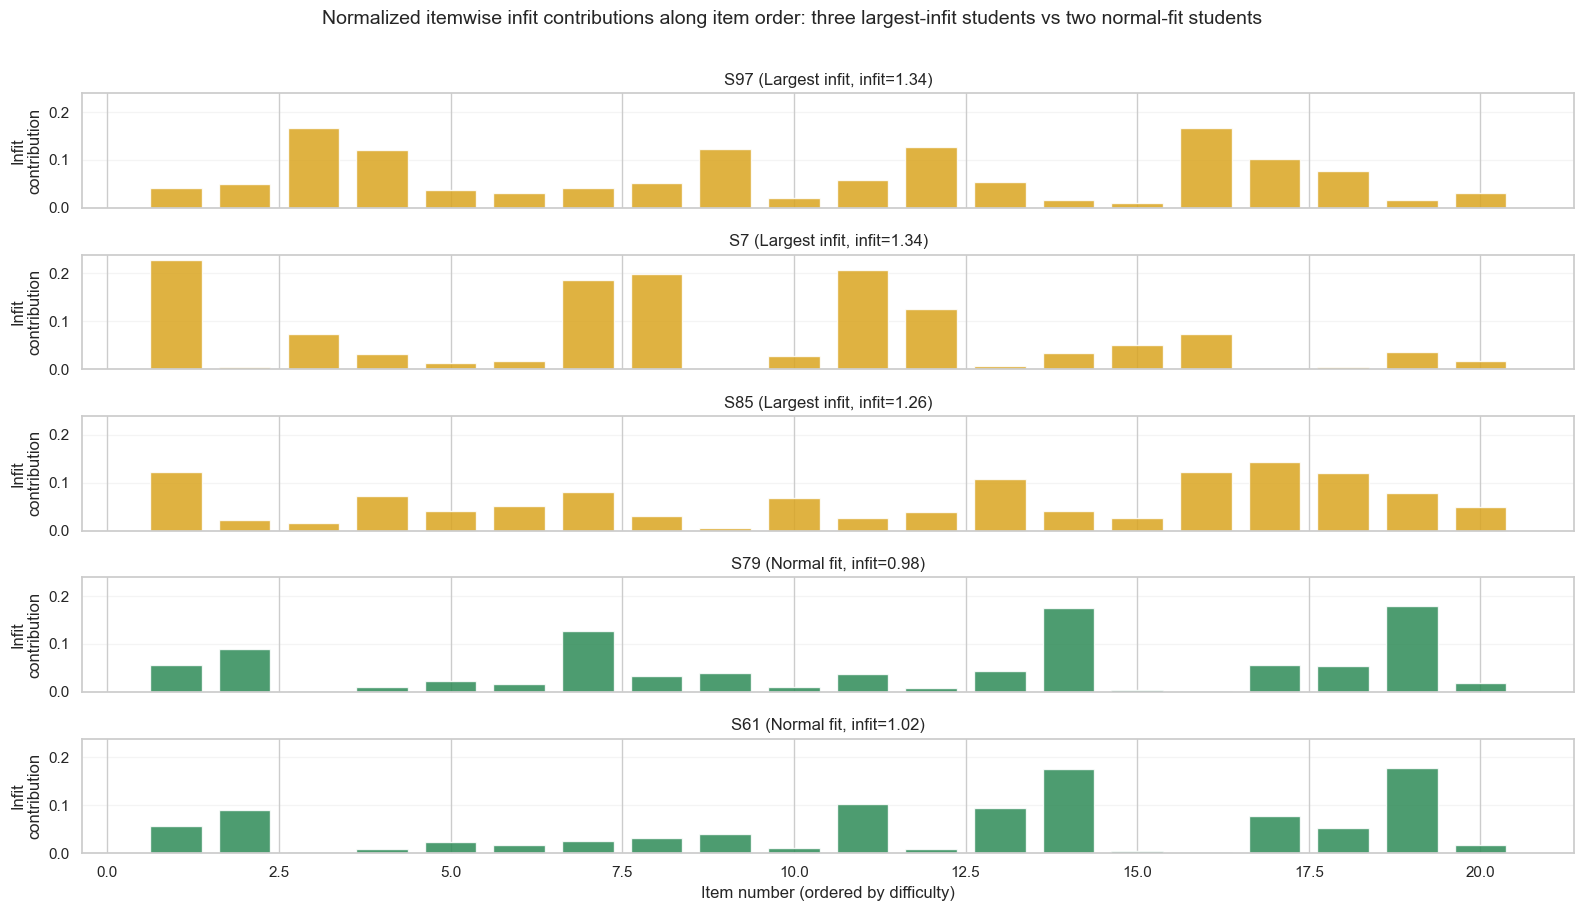

Largest-infit students: S97, S7, S85
Normal-fit comparison students: S79, S61


In [34]:
fig, axes = plt.subplots(len(comparison_profiles), 1, figsize=(16, 9), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, profile, label, color in zip(axes, comparison_profiles, comparison_labels, comparison_colors):
    ax.bar(ordered_item_numbers, profile, color=color, width=0.75, alpha=0.85)
    ax.set_ylabel('Infit\ncontribution')
    ax.set_title(label)
    ax.grid(alpha=0.2, axis='y')

axes[-1].set_xlabel('Item number (ordered by difficulty)')
fig.suptitle('Normalized itemwise infit contributions along item order: three largest-infit students vs two normal-fit students', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

print('Largest-infit students:', ', '.join(f"S{int(student_id)}" for student_id in high_infit_focus_df['student_id']))
print('Normal-fit comparison students:', ', '.join(f"S{int(student_id)}" for student_id in normal_compare_df['student_id']))

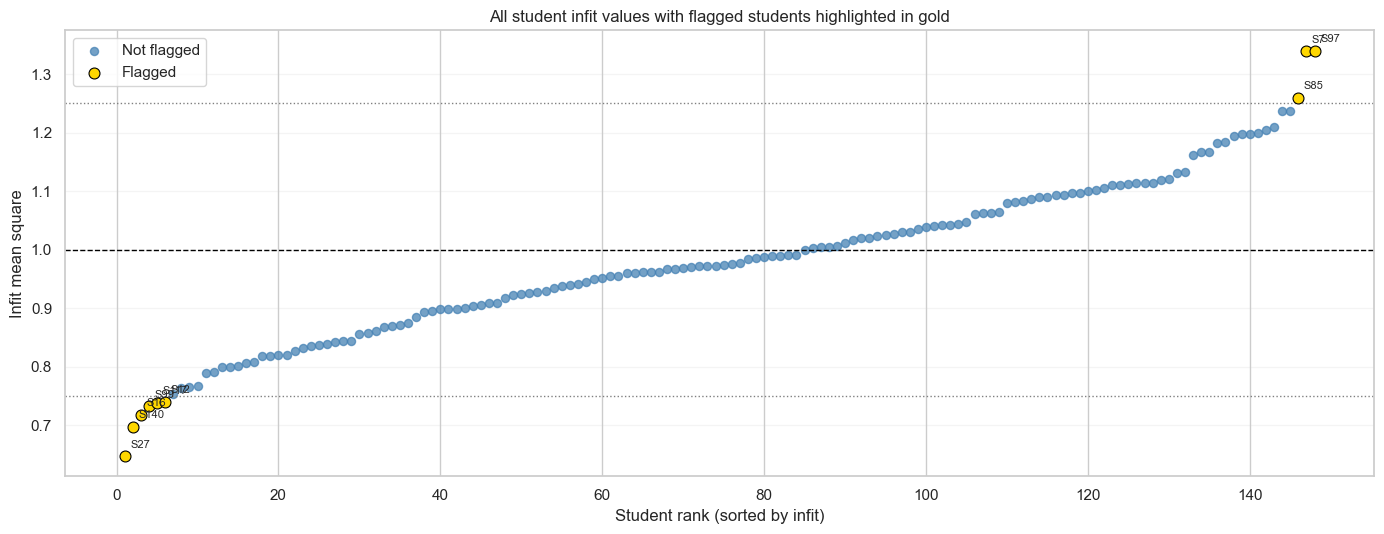

Flagged students by infit: 9 of 148


In [35]:
# Show all student infit values together and highlight flagged students in gold.
infit_overview_df = person_fit_df.sort_values('infit_mnsq').reset_index(drop=True).copy()
infit_overview_df['rank'] = np.arange(1, len(infit_overview_df) + 1)

plt.figure(figsize=(14, 5.5))
plt.scatter(
    infit_overview_df.loc[~infit_overview_df['infit_flag'], 'rank'],
    infit_overview_df.loc[~infit_overview_df['infit_flag'], 'infit_mnsq'],
    color='steelblue',
    alpha=0.75,
    s=34,
    label='Not flagged'
)
plt.scatter(
    infit_overview_df.loc[infit_overview_df['infit_flag'], 'rank'],
    infit_overview_df.loc[infit_overview_df['infit_flag'], 'infit_mnsq'],
    color='gold',
    edgecolor='black',
    linewidth=0.8,
    s=62,
    zorder=3,
    label='Flagged'
)

for _, row in infit_overview_df.loc[infit_overview_df['infit_flag']].iterrows():
    plt.annotate(
        f"S{int(row['student_id'])}",
        (row['rank'], row['infit_mnsq']),
        textcoords='offset points',
        xytext=(4, 6),
        fontsize=8,
    )

plt.axhline(1.0, color='black', linestyle='--', linewidth=1)
plt.axhline(major_infit_low, color='gray', linestyle=':', linewidth=1)
plt.axhline(major_infit_high, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Student rank (sorted by infit)')
plt.ylabel('Infit mean square')
plt.title('All student infit values with flagged students highlighted in gold')
plt.legend()
plt.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print(f"Flagged students by infit: {infit_overview_df['infit_flag'].sum()} of {len(infit_overview_df)}")

### Plain-Language Meaning of Large Infit

A **large infit** means the student's answers are more inconsistent than the Rasch model expects on the items that are most relevant for measuring that student.

In simple words:

- the student is not just missing one strange item
- the student is giving an irregular pattern on items near their own level
- so the student's main response pattern looks noisy under the model

That is why large infit is usually interpreted as **unexpected inconsistency in the central part of the test**. In contrast, large outfit is more about a few unusual outlier responses on items that are much too easy or much too hard.

S7 looks misfitting because his response pattern does not line up cleanly with what a Rasch student at his estimated ability should do.

S7's MLE ability is about $-1.52$, which is fairly low in this scale. With that ability, the model expects S7 to have only moderate chances on the easiest items and very low chances on the harder items. S7's summary is:
1. $\hat\theta \approx -1.52$
2. Infit $\approx 1.34$
3. Outfit $\approx 1.49$
4. Total score $= 5/20$

What makes S7 unusual is the combination of these responses:
1. On the very easiest items, where difficulty is about $-1.54$ and $-1.53$, S7 had fitted probabilities near $0.50$ but responded $0,0$.
2. On several clearly harder items, S7 responded correctly even though the fitted probabilities were low:
   - $b=-0.87,\ p\approx0.34,\ y=1$
   - $b=-0.15,\ p\approx0.20,\ y=1$
   - $b=0.03,\ p\approx0.17,\ y=1$
   - $b=0.16,\ p\approx0.16,\ y=1$
   - $b=0.50,\ p\approx0.12,\ y=1$

Those harder-item successes are the main reason S7's infit is large. The biggest itemwise infit contributions come from Items 1, 11, 8, and 7, and together they account for most of S7's infit. So the issue is not just "S7 is low ability." The issue is that, for a student estimated at $-1.52$, the pattern is internally inconsistent: missing some items that should be relatively manageable while also getting several harder items right.

The practical interpretation is that S7's answers are noisier than the Rasch model expects around the part of the test that still carries information for S7. That is exactly what a large infit means. Since S7's outfit is also large, there is some outlier behavior too, but the key point is that S7 is not just showing one strange response. The broader pattern is irregular enough to inflate infit.


### Is Person-Fit Analysis Still Meaningful When the MLE Confidence Intervals Are Wide?

Yes, it is still meaningful, but it should be interpreted as a **diagnostic** rather than as a hard final verdict.

The key point is that two different questions are being asked:

1. **How precisely is the student's ability estimated?**
2. **How well does the student's response pattern agree with the fitted Rasch model?**

The wide confidence intervals address the first question. The misfit statistics such as infit and outfit address the second question. These two issues are related, but they are not the same.

A wide confidence interval means that the MLE ability estimate $\hat\theta_j$ is not very precise. In this notebook that is not surprising, because each student has only 20 binary item responses, so the amount of information per person is limited. When the confidence interval is wide, we should acknowledge that the exact location of the student's ability is somewhat uncertain.

However, that does **not** automatically make person-fit analysis useless. Even when ability estimation is somewhat imprecise, the observed response pattern can still look clearly irregular relative to the fitted Rasch pattern. In other words, a response vector can still contain noticeable inconsistency, even if the exact estimated ability is not pinned down sharply.

So the person-fit analysis is still worth doing, but with the right level of caution.

What is acceptable and meaningful here is the following:

- The person-fit statistics are useful as a **screening tool**.
- They help identify students whose responses deserve a closer look.
- They are especially informative when the departure is fairly large and the item-level pattern is visibly inconsistent.
- They are more convincing when the flagged behavior is supported by several items, not just one isolated odd response.

What the wide confidence intervals imply is that we should avoid overinterpreting borderline cases.

Because $\hat\theta_j$ is uncertain, the fitted probabilities

$$
p(\hat\theta_j,b_i) = \operatorname{logit}^{-1}(\hat\theta_j - b_i)
$$

are also uncertain. And since infit and outfit are built from these fitted probabilities, the fit statistics themselves are not perfectly stable. With only 20 items, a student's fit value can move around somewhat if the ability estimate shifts.

So a case that is only barely above or below a fit cutoff should be interpreted carefully. A marginal infit value just beyond the threshold is not as compelling as a student whose response pattern is clearly inconsistent and whose fit value is substantially outside the usual range.

That is why the best interpretation is not:

- "The confidence intervals are wide, so the misfit analysis is invalid."

Instead, the better interpretation is:

- The misfit analysis is still meaningful for **exploration and diagnosis**.
- It is acceptable for identifying suspicious or unusual response patterns.
- But it should not be treated as a definitive claim about the student without looking at the actual item-level behavior.

In this notebook, that means the person-fit analysis should be read together with several pieces of information:

1. the size of the infit or outfit departure,
2. the actual response pattern across items,
3. the item difficulties relative to the student's estimated ability,
4. the confidence interval width,
5. and the fact that this is a short test, so person estimates are only moderately precise.

So the practical conclusion is:

**Yes, the misfit analysis is still worth doing and is still meaningful, even when the confidence intervals are wide. But it should be used as a cautious diagnostic tool, not as a rigid yes-or-no judgment. Wide confidence intervals reduce how certain we are about the exact fitted ability, but they do not erase clear evidence that a student's response pattern looks unusually inconsistent under the Rasch model.**

### What Can Be Done for Misfit Analysis with Stan MCMC Posterior Samples?

Yes, having posterior samples is a real advantage for person-fit analysis, because now we do not have to treat each student's ability as a single fixed estimate. Instead, for each student $j$, we have many draws

$$
\theta_j^{(1)}, \theta_j^{(2)}, \ldots, \theta_j^{(S)}
$$

from the posterior distribution. That means the misfit analysis can be done **across the whole posterior uncertainty**, not only at one point estimate such as the MLE or posterior mean.

A natural approach is this:

For each posterior draw $s$ and each item $i$, compute

$$
p^{(s)}(\theta_j^{(s)}, b_i) = \Pr(Y_{ji}=1 \mid \theta_j^{(s)}, b_i)
$$

and then compute the residual-based quantities using that draw. For example,

$$
z^{(s)}(\theta_j^{(s)}, b_i) = \frac{Y_{ji} - p^{(s)}(\theta_j^{(s)}, b_i)}{\sqrt{p^{(s)}(\theta_j^{(s)}, b_i)\bigl(1-p^{(s)}(\theta_j^{(s)}, b_i)\bigr)}}
$$

and then person-fit statistics such as

$$
\text{outfit}_j^{(s)} = \frac{1}{K} \sum_{i=1}^K \left(z^{(s)}(\theta_j^{(s)}, b_i)\right)^2
$$

and

$$
\text{infit}_j^{(s)} = \frac{\sum_{i=1}^K p^{(s)}(\theta_j^{(s)}, b_i)\bigl(1-p^{(s)}(\theta_j^{(s)}, b_i)\bigr) \left(z^{(s)}(\theta_j^{(s)}, b_i)\right)^2}{\sum_{i=1}^K p^{(s)}(\theta_j^{(s)}, b_i)\bigl(1-p^{(s)}(\theta_j^{(s)}, b_i)\bigr)}.
$$

This gives not just one infit or outfit value per student, but a **posterior distribution of infit and outfit** for each student.

That is useful because now we can report things like:

- posterior mean or median infit/outfit
- a 95% credible interval for infit/outfit
- the posterior probability that a student is misfitting, for example

$$
\Pr(\text{infit}_j > 1.25 \mid y)
$$

or

$$
\Pr(\text{outfit}_j > 1.45 \mid y).
$$

This is much better than saying only "student $j$ has infit = 1.31." Instead we can say something like: "student $j$ has posterior mean infit 1.28, with 95% credible interval $(1.10, 1.52)$, and posterior probability 0.91 of exceeding the 1.25 threshold." That is a much more honest statement because it includes uncertainty.

A second important idea is **posterior predictive person-fit checking**. This is often even stronger than just recomputing infit across posterior draws.

For each posterior draw $s$:

1. use the sampled parameter values to generate a replicated response vector
   $$
   Y_{ji}^{\mathrm{rep},(s)} \sim \text{Bernoulli}\left(p^{(s)}(\theta_j^{(s)}, b_i)\right)
   $$
2. compute a person-fit statistic on the replicated data, such as replicated infit, replicated outfit, or replicated residual RMS
3. compare the observed statistic with the replicated distribution

Then for each student we can calculate a posterior predictive tail probability such as

$$
p_{\mathrm{ppc},j} = \Pr\bigl(T_j(Y^{\mathrm{rep}}) \ge T_j(Y) \mid y\bigr),
$$

where $T_j$ is a person-fit statistic for student $j$.

Interpretation:

- if the observed statistic is typical under the posterior predictive distribution, then the student's response pattern is compatible with the Rasch model
- if the observed statistic is in the extreme tail of the replicated distribution, then the student's pattern is hard for the model to reproduce, so there is evidence of misfit

This is attractive because it answers the right question: not merely "is the observed infit large?" but rather "is the observed infit unusually large relative to what the fitted Bayesian model itself would generate?"

A third thing we can do is **posterior itemwise contribution analysis**. Earlier we looked at itemwise infit contributions using one point estimate of ability. With posterior draws, we can compute for each student and item

$$
c_{ij}^{(s)} = \frac{p^{(s)}(\theta_j^{(s)}, b_i)\bigl(1-p^{(s)}(\theta_j^{(s)}, b_i)\bigr) \left(z^{(s)}(\theta_j^{(s)}, b_i)\right)^2}{\sum_{k=1}^K p^{(s)}(\theta_j^{(s)}, b_k)\bigl(1-p^{(s)}(\theta_j^{(s)}, b_k)\bigr)}
$$

for each posterior draw, and then summarize across draws. That gives:

- posterior mean itemwise contribution
- credible intervals for each item's contribution
- the probability that a given item is one of the dominant sources of a student's misfit

This is helpful because it tells us whether the apparent "problem items" for a student are stable across the posterior, or whether they only looked large because the person parameter estimate was uncertain.

So, conceptually, the Stan posterior lets us separate two sources of apparent misfit:

- **true response-pattern inconsistency**
- **uncertainty in the student's latent trait level**

That is exactly the weakness of the earlier MLE-based analysis. With only one estimate of $\theta_j$, some students may look misfitting simply because their ability estimate is noisy. With posterior sampling, if a student still looks misfitting over most posterior draws, then the evidence for misfit is much stronger.

In practice, the most useful posterior-based summaries for this notebook would probably be these four:

1. posterior distribution of each student's infit and outfit
2. posterior probability that each student exceeds a misfit threshold
3. posterior predictive p-values for each student's infit or outfit
4. posterior mean heatmaps of itemwise infit contributions, possibly with credible intervals

Among these, the **posterior predictive check** is usually the strongest general answer, because it directly asks whether the observed response pattern is surprising under the fitted Rasch model.

So the short answer is: with Stan MCMC output, misfit analysis becomes not only possible but better grounded. Instead of a single deterministic flag, we can quantify how certain we are that a student misfits, and we can check whether the observed misfit is truly unusual relative to what the posterior predictive model would generate.

In [36]:
# Compute posterior distributions of person infit/outfit and posterior predictive p-values for each student.
if theta_draws.shape[0] != y_rep_draws.shape[0]:
    raise ValueError('theta_draws and y_rep_draws must have the same number of posterior draws.')

posterior_prob_draws = expit(theta_draws[:, :, None] - b_true[None, None, :])
posterior_weight_draws = np.clip(posterior_prob_draws * (1.0 - posterior_prob_draws), 1e-9, None)

observed_sq_residual_draws = (y[None, :, :] - posterior_prob_draws) ** 2
observed_std_sq_draws = observed_sq_residual_draws / posterior_weight_draws
posterior_infit_draws = observed_sq_residual_draws.sum(axis=2) / posterior_weight_draws.sum(axis=2)
posterior_outfit_draws = observed_std_sq_draws.mean(axis=2)

replicated_sq_residual_draws = (y_rep_draws - posterior_prob_draws) ** 2
replicated_std_sq_draws = replicated_sq_residual_draws / posterior_weight_draws
replicated_infit_draws = replicated_sq_residual_draws.sum(axis=2) / posterior_weight_draws.sum(axis=2)
replicated_outfit_draws = replicated_std_sq_draws.mean(axis=2)

posterior_person_fit_df = pd.DataFrame({
    'student_id': np.arange(1, N + 1),
    'total_score': y.sum(axis=1),
    'theta_post_mean': theta_post_mean,
    'posterior_infit_mean': posterior_infit_draws.mean(axis=0),
    'posterior_infit_q025': np.quantile(posterior_infit_draws, 0.025, axis=0),
    'posterior_infit_q975': np.quantile(posterior_infit_draws, 0.975, axis=0),
    'posterior_outfit_mean': posterior_outfit_draws.mean(axis=0),
    'posterior_outfit_q025': np.quantile(posterior_outfit_draws, 0.025, axis=0),
    'posterior_outfit_q975': np.quantile(posterior_outfit_draws, 0.975, axis=0),
    'prob_infit_gt_1_25': (posterior_infit_draws > 1.25).mean(axis=0),
    'prob_infit_lt_0_75': (posterior_infit_draws < 0.75).mean(axis=0),
    'prob_outfit_gt_1_45': (posterior_outfit_draws > 1.45).mean(axis=0),
    'prob_outfit_lt_0_55': (posterior_outfit_draws < 0.55).mean(axis=0),
    'ppp_infit_upper': (replicated_infit_draws >= posterior_infit_draws).mean(axis=0),
    'ppp_outfit_upper': (replicated_outfit_draws >= posterior_outfit_draws).mean(axis=0),
})
posterior_person_fit_df['ppp_infit_two_sided'] = 2.0 * np.minimum(
    posterior_person_fit_df['ppp_infit_upper'],
    1.0 - posterior_person_fit_df['ppp_infit_upper'],
)
posterior_person_fit_df['ppp_outfit_two_sided'] = 2.0 * np.minimum(
    posterior_person_fit_df['ppp_outfit_upper'],
    1.0 - posterior_person_fit_df['ppp_outfit_upper'],
)

posterior_person_fit_df = posterior_person_fit_df.merge(
    person_fit_df[[
        'student_id',
        'theta_mle',
        'residual_rms',
        'infit_mnsq',
        'outfit_mnsq',
        'infit_flag',
        'outfit_flag',
    ]],
    on='student_id',
    how='left',
)

posterior_person_fit_df = posterior_person_fit_df.sort_values('student_id').reset_index(drop=True)

print(f'Posterior draws used for person-fit summaries: {theta_draws.shape[0]}')
print('Posterior predictive p-values near 0 or 1 indicate that the observed fit statistic is hard for the fitted Rasch model to reproduce.')
display(posterior_person_fit_df.round(3))

posterior_priority_df = posterior_person_fit_df.assign(
    infit_ppp_distance=(posterior_person_fit_df['ppp_infit_upper'] - 0.5).abs(),
    outfit_ppp_distance=(posterior_person_fit_df['ppp_outfit_upper'] - 0.5).abs(),
).sort_values(
    ['prob_infit_gt_1_25', 'posterior_infit_mean', 'outfit_ppp_distance'],
    ascending=[False, False, False],
)

print('Students with the strongest posterior evidence of high infit:')
display(
    posterior_priority_df[[
        'student_id',
        'total_score',
        'posterior_infit_mean',
        'posterior_infit_q025',
        'posterior_infit_q975',
        'prob_infit_gt_1_25',
        'ppp_infit_upper',
        'posterior_outfit_mean',
        'prob_outfit_gt_1_45',
        'ppp_outfit_upper',
    ]].head(10).round(3)
)

Posterior draws used for person-fit summaries: 4000
Posterior predictive p-values near 0 or 1 indicate that the observed fit statistic is hard for the fitted Rasch model to reproduce.


,student_id,total_score,theta_post_mean,posterior_infit_mean,posterior_infit_q025,posterior_infit_q975,posterior_outfit_mean,posterior_outfit_q025,posterior_outfit_q975,prob_infit_gt_1_25,...,ppp_infit_upper,ppp_outfit_upper,ppp_infit_two_sided,ppp_outfit_two_sided,theta_mle,residual_rms,infit_mnsq,outfit_mnsq,infit_flag,outfit_flag
0,1,13,0.424,1.243,1.068,1.996,1.216,1.035,2.042,0.299,...,0.197,0.280,0.394,0.560,0.399,0.478,1.121,1.061,False,False
1,2,11,-0.064,1.033,0.930,1.471,1.108,0.959,1.726,0.077,...,0.474,0.378,0.948,0.756,-0.070,0.452,0.930,0.983,False,False
2,3,9,-0.527,1.266,1.165,1.710,1.315,1.155,2.016,0.338,...,0.104,0.131,0.207,0.262,-0.522,0.507,1.168,1.168,False,False
3,4,12,0.186,1.029,0.901,1.606,1.111,0.959,1.793,0.092,...,0.499,0.375,0.998,0.750,0.160,0.443,0.917,0.979,False,False
4,5,6,-1.272,1.145,0.938,2.011,1.121,0.898,2.067,0.206,...,0.392,0.427,0.785,0.854,-1.244,0.437,1.007,0.965,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,17,1.734,1.569,0.966,4.124,2.253,0.995,7.040,0.505,...,0.255,0.164,0.510,0.328,1.619,0.380,1.210,1.601,False,True
146,147,12,0.175,0.908,0.787,1.460,0.862,0.754,1.353,0.050,...,0.721,0.742,0.558,0.516,0.160,0.414,0.802,0.764,False,False
147,148,13,0.419,1.307,1.159,1.982,1.339,1.119,2.326,0.412,...,0.108,0.168,0.216,0.336,0.399,0.494,1.198,1.178,False,False
148,149,1,-3.726,2.956,0.615,15.014,7.513,0.812,40.273,0.490,...,0.318,0.151,0.635,0.302,-3.469,0.227,1.114,2.557,False,True


Students with the strongest posterior evidence of high infit:


,student_id,total_score,posterior_infit_mean,posterior_infit_q025,posterior_infit_q975,prob_infit_gt_1_25,ppp_infit_upper,posterior_outfit_mean,prob_outfit_gt_1_45,ppp_outfit_upper
96,97,12,1.449,1.327,1.984,1.000,0.022,1.727,1.000,0.010
84,85,9,1.355,1.258,1.756,1.000,0.040,1.462,0.328,0.046
6,7,5,1.525,1.225,2.814,0.782,0.087,1.816,0.560,0.093
76,77,10,1.341,1.237,1.783,0.717,0.045,1.461,0.324,0.040
37,38,12,1.345,1.221,1.873,0.613,0.059,1.482,0.342,0.058
145,146,17,1.569,0.966,4.124,0.505,0.255,2.253,0.613,0.164
61,62,19,3.361,0.610,18.960,0.503,0.312,7.371,0.716,0.184
127,128,19,3.984,0.550,19.258,0.498,0.368,4.376,0.456,0.335
101,102,1,5.426,0.597,17.361,0.496,0.339,10.689,0.658,0.222
148,149,1,2.956,0.615,15.014,0.490,0.318,7.513,0.788,0.151


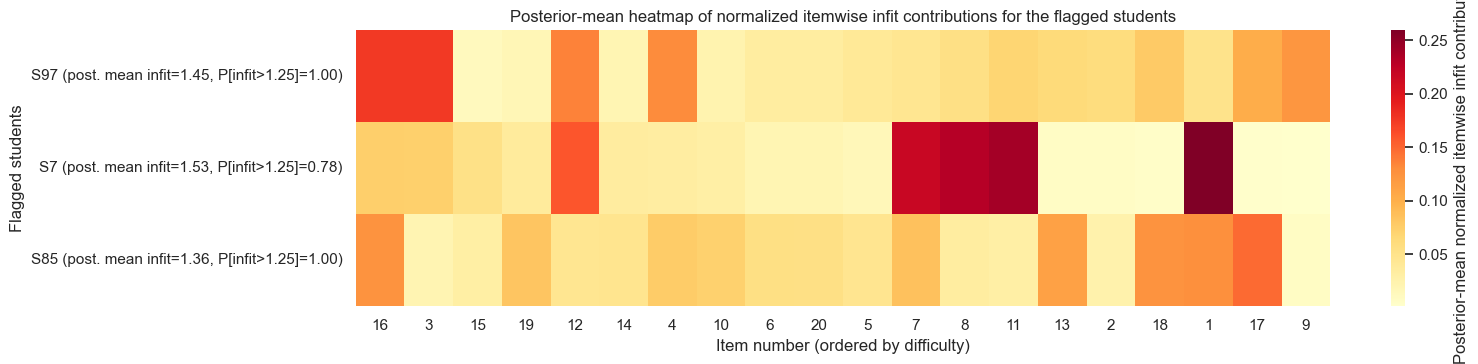

In [37]:
# Plot a posterior-mean heatmap of itemwise infit contributions for the MLE-flagged largest-infit students.
if 'high_infit_focus_df' in globals() and not high_infit_focus_df.empty:
    posterior_heatmap_student_ids = high_infit_focus_df['student_id'].astype(int).tolist()
else:
    posterior_heatmap_student_ids = (
        posterior_person_fit_df.sort_values('posterior_infit_mean', ascending=False)
        .head(3)['student_id']
        .astype(int)
        .tolist()
    )

posterior_item_order = np.argsort(b_true)
posterior_ordered_item_numbers = np.arange(1, K + 1)[posterior_item_order]
posterior_heatmap_profiles = []
posterior_heatmap_labels = []
posterior_fit_lookup = posterior_person_fit_df.set_index('student_id')

for student_id in posterior_heatmap_student_ids:
    student_idx = student_id - 1
    student_theta_draws = theta_draws[:, student_idx][:, None]
    student_prob_draws = expit(student_theta_draws - b_true[None, :])
    student_weight_draws = np.clip(student_prob_draws * (1.0 - student_prob_draws), 1e-9, None)
    student_std_sq_draws = ((y[student_idx][None, :] - student_prob_draws) ** 2) / student_weight_draws
    student_contribution_draws = (
        student_weight_draws * student_std_sq_draws
    ) / student_weight_draws.sum(axis=1, keepdims=True)
    posterior_mean_profile = student_contribution_draws.mean(axis=0)[posterior_item_order]

    posterior_heatmap_profiles.append(posterior_mean_profile)
    posterior_row = posterior_fit_lookup.loc[student_id]
    posterior_heatmap_labels.append(
        f"S{student_id} (post. mean infit={posterior_row['posterior_infit_mean']:.2f}, P[infit>1.25]={posterior_row['prob_infit_gt_1_25']:.2f})"
    )

posterior_heatmap_profiles = np.asarray(posterior_heatmap_profiles)

plt.figure(figsize=(16, 3.8))
sns.heatmap(
    posterior_heatmap_profiles,
    cmap='YlOrRd',
    xticklabels=posterior_ordered_item_numbers,
    yticklabels=posterior_heatmap_labels,
    cbar_kws={'label': 'Posterior-mean normalized itemwise infit contribution'}
)
plt.xlabel('Item number (ordered by difficulty)')
plt.ylabel('Flagged students')
plt.title('Posterior-mean heatmap of normalized itemwise infit contributions for the flagged students')
plt.tight_layout()
plt.show()

In [38]:
# Flag students directly from posterior criteria and choose posterior-based comparison groups.
posterior_person_fit_df = posterior_person_fit_df.copy()
posterior_person_fit_df['posterior_high_infit_flag'] = posterior_person_fit_df['prob_infit_gt_1_25'] >= 0.50
posterior_person_fit_df['posterior_low_infit_flag'] = posterior_person_fit_df['prob_infit_lt_0_75'] >= 0.50
posterior_person_fit_df['posterior_high_outfit_flag'] = posterior_person_fit_df['prob_outfit_gt_1_45'] >= 0.50
posterior_person_fit_df['posterior_low_outfit_flag'] = posterior_person_fit_df['prob_outfit_lt_0_55'] >= 0.50
posterior_person_fit_df['posterior_infit_flag'] = (
    posterior_person_fit_df['posterior_high_infit_flag']
    | posterior_person_fit_df['posterior_low_infit_flag']
)
posterior_person_fit_df['posterior_outfit_flag'] = (
    posterior_person_fit_df['posterior_high_outfit_flag']
    | posterior_person_fit_df['posterior_low_outfit_flag']
)
posterior_person_fit_df['posterior_any_flag'] = (
    posterior_person_fit_df['posterior_infit_flag']
    | posterior_person_fit_df['posterior_outfit_flag']
)
posterior_person_fit_df['posterior_fit_distance'] = (
    (posterior_person_fit_df['posterior_infit_mean'] - 1.0).abs()
    + (posterior_person_fit_df['posterior_outfit_mean'] - 1.0).abs()
    + (posterior_person_fit_df['ppp_infit_upper'] - 0.5).abs()
    + (posterior_person_fit_df['ppp_outfit_upper'] - 0.5).abs()
)

posterior_high_infit_df = posterior_person_fit_df[
    posterior_person_fit_df['posterior_high_infit_flag']
].sort_values(
    ['prob_infit_gt_1_25', 'posterior_infit_mean', 'ppp_infit_upper'],
    ascending=[False, False, True],
).copy()
if posterior_high_infit_df.empty:
    posterior_high_infit_df = posterior_person_fit_df.sort_values(
        ['posterior_infit_mean', 'prob_infit_gt_1_25'],
        ascending=[False, False],
    ).head(3).copy()

posterior_flagged_students_df = posterior_high_infit_df.head(3).copy()
posterior_normal_students_df = posterior_person_fit_df[
    ~posterior_person_fit_df['student_id'].isin(posterior_flagged_students_df['student_id'])
].sort_values('posterior_fit_distance').head(2).copy()

posterior_focus_students_df = pd.concat([
    posterior_flagged_students_df.assign(case_group='Posterior-flagged'),
    posterior_normal_students_df.assign(case_group='Posterior-normal'),
], ignore_index=True)

print(f"Posterior high-infit flagged students (P[infit>1.25] >= 0.50): {posterior_person_fit_df['posterior_high_infit_flag'].sum()} of {N}")
print('Posterior-flagged students used for the focused plots:', ', '.join(f"S{int(student_id)}" for student_id in posterior_flagged_students_df['student_id']))
print('Posterior-normal comparison students:', ', '.join(f"S{int(student_id)}" for student_id in posterior_normal_students_df['student_id']))

display(
    posterior_person_fit_df.loc[
        posterior_person_fit_df['posterior_any_flag'],
        [
            'student_id',
            'total_score',
            'posterior_infit_mean',
            'posterior_infit_q025',
            'posterior_infit_q975',
            'prob_infit_gt_1_25',
            'posterior_outfit_mean',
            'posterior_outfit_q025',
            'posterior_outfit_q975',
            'prob_outfit_gt_1_45',
            'ppp_infit_upper',
            'ppp_outfit_upper',
        ],
    ].sort_values(['prob_infit_gt_1_25', 'posterior_infit_mean'], ascending=[False, False]).round(3)
)

Posterior high-infit flagged students (P[infit>1.25] >= 0.50): 7 of 150
Posterior-flagged students used for the focused plots: S97, S85, S7
Posterior-normal comparison students: S122, S150


,student_id,total_score,posterior_infit_mean,posterior_infit_q025,posterior_infit_q975,prob_infit_gt_1_25,posterior_outfit_mean,posterior_outfit_q025,posterior_outfit_q975,prob_outfit_gt_1_45,ppp_infit_upper,ppp_outfit_upper
96,97,12,1.449,1.327,1.984,1.000,1.727,1.453,2.886,1.000,0.022,0.010
84,85,9,1.355,1.258,1.756,1.000,1.462,1.287,2.207,0.328,0.040,0.046
6,7,5,1.525,1.225,2.814,0.782,1.816,1.213,4.209,0.560,0.087,0.093
76,77,10,1.341,1.237,1.783,0.717,1.461,1.292,2.169,0.324,0.045,0.040
37,38,12,1.345,1.221,1.873,0.613,1.482,1.266,2.377,0.342,0.059,0.058
145,146,17,1.569,0.966,4.124,0.505,2.253,0.995,7.040,0.613,0.255,0.164
61,62,19,3.361,0.610,18.960,0.503,7.371,0.710,43.551,0.716,0.312,0.184
101,102,1,5.426,0.597,17.361,0.496,10.689,0.652,35.004,0.658,0.339,0.222
148,149,1,2.956,0.615,15.014,0.490,7.513,0.812,40.273,0.788,0.318,0.151
79,80,1,4.307,0.574,21.226,0.486,6.230,0.545,31.493,0.546,0.349,0.284


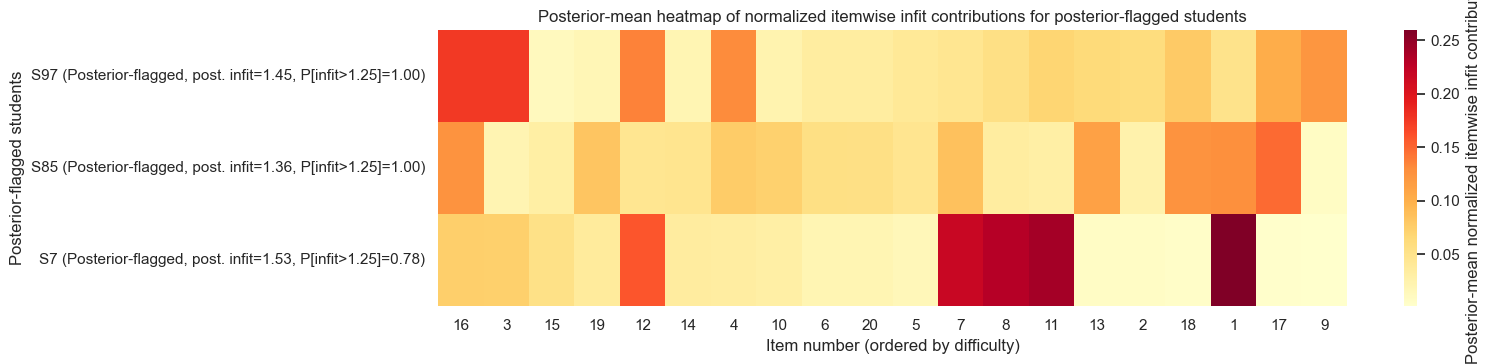

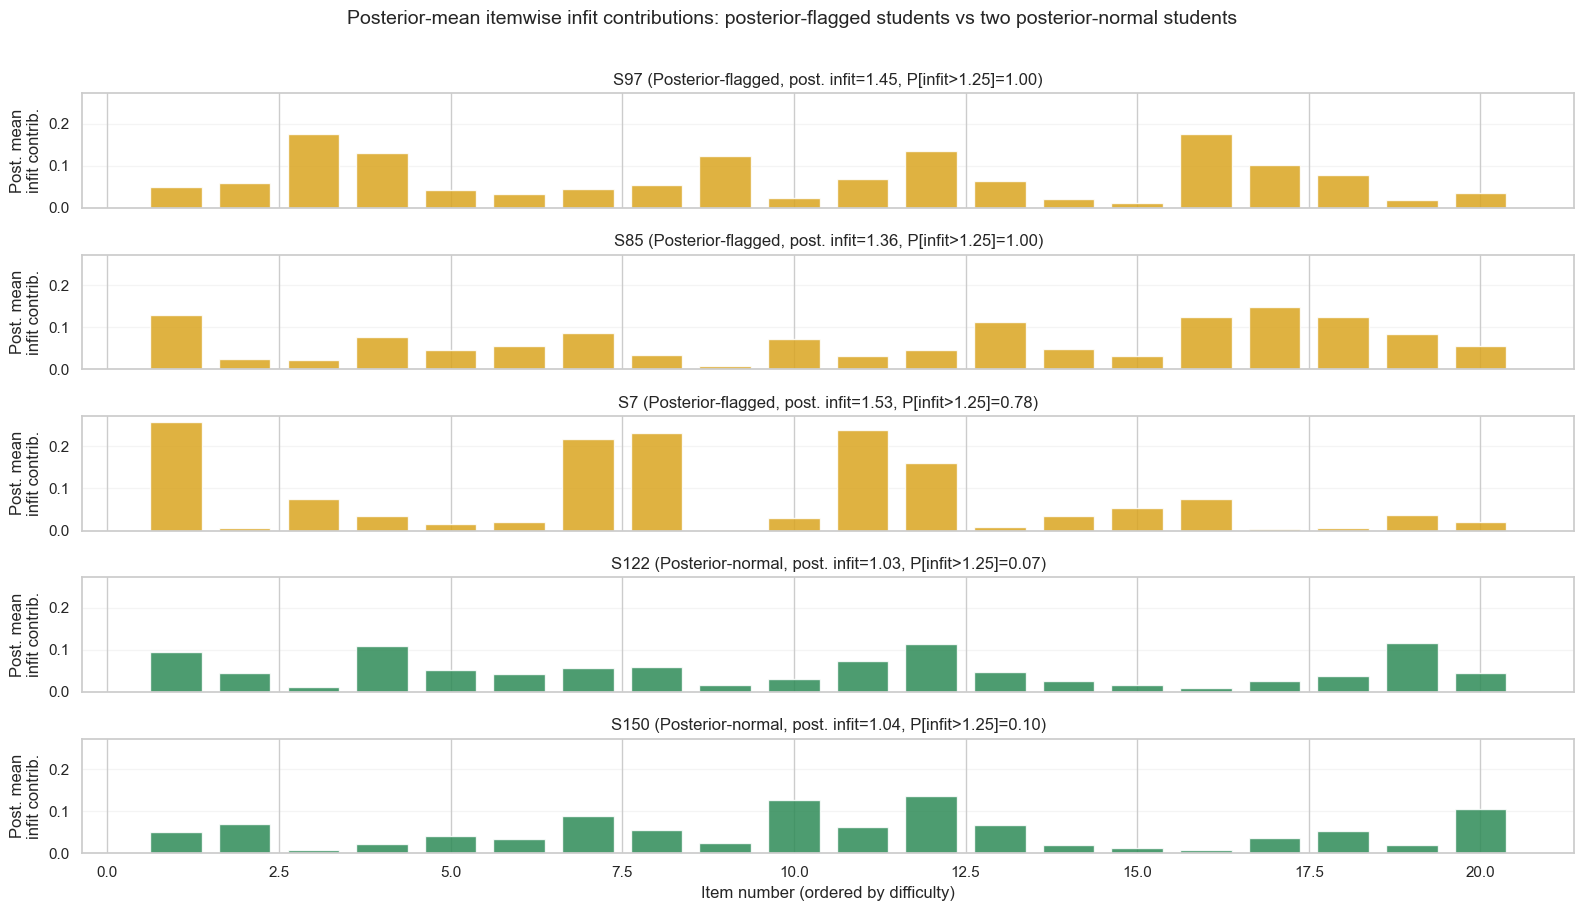

In [39]:
# Posterior bar plots and heatmap for flagged students plus two posterior-normal students.
posterior_item_order = np.argsort(b_true)
posterior_ordered_item_numbers = np.arange(1, K + 1)[posterior_item_order]
posterior_comparison_profiles = []
posterior_comparison_labels = []
posterior_comparison_colors = []
posterior_heatmap_profiles = []
posterior_heatmap_labels = []
posterior_contribution_summary = []

for _, row in posterior_focus_students_df.iterrows():
    student_id = int(row['student_id'])
    student_idx = student_id - 1
    student_prob_draws = posterior_prob_draws[:, student_idx, :]
    student_weight_draws = posterior_weight_draws[:, student_idx, :]
    student_contribution_draws = ((y[student_idx][None, :] - student_prob_draws) ** 2) / student_weight_draws.sum(axis=1, keepdims=True)

    contribution_mean = student_contribution_draws.mean(axis=0)
    contribution_q025 = np.quantile(student_contribution_draws, 0.025, axis=0)
    contribution_q975 = np.quantile(student_contribution_draws, 0.975, axis=0)

    posterior_contribution_summary.append(pd.DataFrame({
        'student_id': student_id,
        'case_group': row['case_group'],
        'item_number': np.arange(1, K + 1),
        'item_difficulty': b_true,
        'contribution_mean': contribution_mean,
        'contribution_q025': contribution_q025,
        'contribution_q975': contribution_q975,
        'interval_width': contribution_q975 - contribution_q025,
    }))

    ordered_profile = contribution_mean[posterior_item_order]
    label = (
        f"S{student_id} ({row['case_group']}, post. infit={row['posterior_infit_mean']:.2f}, "
        f"P[infit>1.25]={row['prob_infit_gt_1_25']:.2f})"
    )
    posterior_comparison_profiles.append(ordered_profile)
    posterior_comparison_labels.append(label)
    posterior_comparison_colors.append('goldenrod' if row['case_group'] == 'Posterior-flagged' else 'seagreen')

    if row['case_group'] == 'Posterior-flagged':
        posterior_heatmap_profiles.append(ordered_profile)
        posterior_heatmap_labels.append(label)

posterior_comparison_profiles = np.asarray(posterior_comparison_profiles)
posterior_heatmap_profiles = np.asarray(posterior_heatmap_profiles)
posterior_contribution_summary_df = pd.concat(posterior_contribution_summary, ignore_index=True)

plt.figure(figsize=(16, 3.8))
sns.heatmap(
    posterior_heatmap_profiles,
    cmap='YlOrRd',
    xticklabels=posterior_ordered_item_numbers,
    yticklabels=posterior_heatmap_labels,
    cbar_kws={'label': 'Posterior-mean normalized itemwise infit contribution'}
)
plt.xlabel('Item number (ordered by difficulty)')
plt.ylabel('Posterior-flagged students')
plt.title('Posterior-mean heatmap of normalized itemwise infit contributions for posterior-flagged students')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(posterior_comparison_profiles), 1, figsize=(16, 9), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, profile, label, color in zip(axes, posterior_comparison_profiles, posterior_comparison_labels, posterior_comparison_colors):
    ax.bar(posterior_ordered_item_numbers, profile, color=color, width=0.75, alpha=0.85)
    ax.set_ylabel('Post. mean\ninfit contrib.')
    ax.set_title(label)
    ax.grid(alpha=0.2, axis='y')
axes[-1].set_xlabel('Item number (ordered by difficulty)')
fig.suptitle('Posterior-mean itemwise infit contributions: posterior-flagged students vs two posterior-normal students', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

Top posterior itemwise infit contributions for S97


,item_number,item_difficulty,contribution_mean,contribution_q025,contribution_q975,interval_width
0,16,-1.5352,0.1754,0.1089,0.2855,0.1766
1,3,-1.5268,0.1749,0.1083,0.2852,0.1769
2,12,-0.8719,0.1361,0.0644,0.2544,0.1900
3,4,-0.7899,0.1308,0.0595,0.2495,0.1900
4,9,1.1196,0.1231,0.0778,0.1772,0.0994
5,17,0.8159,0.1027,0.0557,0.1618,0.1061
6,18,0.4448,0.0785,0.0349,0.1398,0.1048
7,11,0.1575,0.0689,0.0187,0.1744,0.1557
8,13,0.2561,0.0632,0.0162,0.1651,0.1489
9,2,0.3101,0.0602,0.0150,0.1599,0.1450


Top posterior itemwise infit contributions for S85


,item_number,item_difficulty,contribution_mean,contribution_q025,contribution_q975,interval_width
0,17,0.8159,0.1475,0.0896,0.2353,0.1457
1,1,0.4976,0.1279,0.0680,0.2198,0.1519
2,16,-1.5352,0.1249,0.0763,0.1865,0.1102
3,18,0.4448,0.1246,0.0646,0.2169,0.1523
4,13,0.2561,0.1124,0.0533,0.2058,0.1525
5,7,-0.1512,0.0860,0.0332,0.1777,0.1446
6,19,-0.8821,0.0828,0.0365,0.1494,0.1129
7,4,-0.7899,0.0771,0.0324,0.1433,0.1109
8,10,-0.7082,0.0722,0.0290,0.1377,0.1087
9,6,-0.4100,0.0554,0.0190,0.1166,0.0976


Top posterior itemwise infit contributions for S7


,item_number,item_difficulty,contribution_mean,contribution_q025,contribution_q975,interval_width
0,1,0.4976,0.2590,0.1189,0.5727,0.4538
1,11,0.1575,0.2390,0.0962,0.5562,0.4599
2,8,0.0335,0.2308,0.0879,0.5488,0.4609
3,7,-0.1512,0.2177,0.0759,0.5364,0.4605
4,12,-0.8719,0.1593,0.0364,0.4674,0.4310
5,16,-1.5352,0.0745,0.0310,0.1253,0.0943
6,3,-1.5268,0.0739,0.0306,0.1248,0.0942
7,15,-1.1955,0.0531,0.0180,0.1029,0.0849
8,19,-0.8821,0.0374,0.0105,0.0820,0.0715
9,14,-0.8361,0.0354,0.0097,0.0790,0.0693


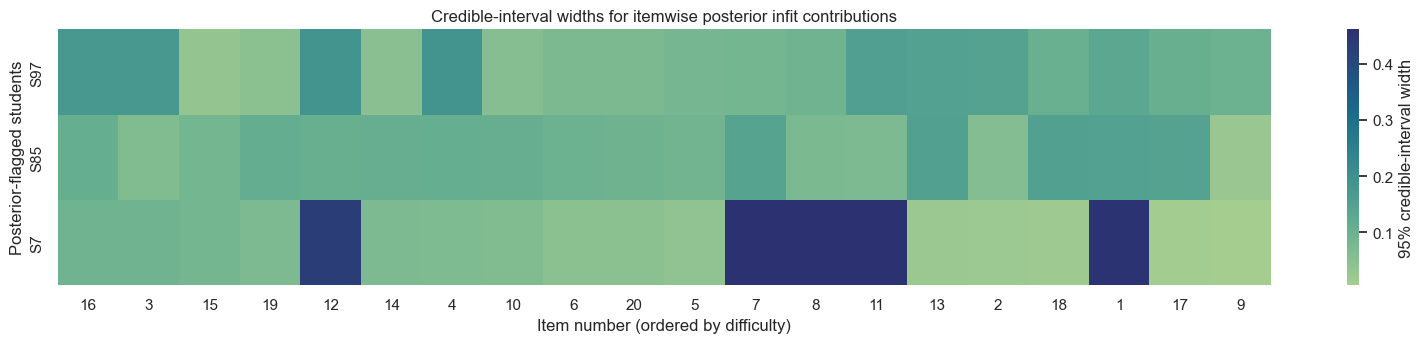

In [40]:
# Credible-interval tables for itemwise posterior infit contributions of the posterior-flagged students.
posterior_interval_tables = []
for student_id in posterior_flagged_students_df['student_id'].astype(int):
    student_interval_df = posterior_contribution_summary_df[
        posterior_contribution_summary_df['student_id'] == student_id
    ].copy()
    student_interval_df = student_interval_df.sort_values('contribution_mean', ascending=False).reset_index(drop=True)
    posterior_interval_tables.append(student_interval_df)

for student_interval_df in posterior_interval_tables:
    student_id = int(student_interval_df['student_id'].iloc[0])
    print(f"Top posterior itemwise infit contributions for S{student_id}")
    display(
        student_interval_df[[
            'item_number',
            'item_difficulty',
            'contribution_mean',
            'contribution_q025',
            'contribution_q975',
            'interval_width',
        ]].head(10).round(4)
    )

posterior_interval_width_heatmap = []
posterior_interval_width_labels = []
for student_id in posterior_flagged_students_df['student_id'].astype(int):
    student_interval_df = posterior_contribution_summary_df[
        posterior_contribution_summary_df['student_id'] == student_id
    ].sort_values('item_number')
    ordered_widths = student_interval_df.set_index('item_number').loc[
        np.arange(1, K + 1), 'interval_width'
    ].to_numpy()[posterior_item_order]
    posterior_interval_width_heatmap.append(ordered_widths)
    posterior_interval_width_labels.append(f"S{student_id}")

posterior_interval_width_heatmap = np.asarray(posterior_interval_width_heatmap)

plt.figure(figsize=(16, 3.6))
sns.heatmap(
    posterior_interval_width_heatmap,
    cmap='crest',
    xticklabels=posterior_ordered_item_numbers,
    yticklabels=posterior_interval_width_labels,
    cbar_kws={'label': '95% credible-interval width'}
)
plt.xlabel('Item number (ordered by difficulty)')
plt.ylabel('Posterior-flagged students')
plt.title('Credible-interval widths for itemwise posterior infit contributions')
plt.tight_layout()
plt.show()